# Credit Card Fraud Detection Using Machine Learning

**Portfolio-ready MSc project notebook**

This notebook presents a complete machine-learning workflow for credit-card fraud detection using an imbalanced transaction dataset.

The project covers:

- data loading and inspection,
- exploratory data analysis,
- missing-value checks,
- outlier analysis,
- scaling,
- class-imbalance handling,
- model comparison,
- cross-validation,
- hyperparameter tuning,
- threshold analysis,
- final model selection,
- and evaluation visualisations.

The notebook has been adapted from the original MSc coursework version into a GitHub-ready portfolio case study. The technical depth has been preserved, while the structure, headings and explanations have been cleaned for a professional audience.

## Repository and Data Notes

This notebook expects the dataset file to be available as `creditcard.csv`.

For GitHub/local use, the recommended path is:

```text
data/creditcard.csv
```

For Kaggle, the notebook also supports the standard input path:

```text
/kaggle/input/creditcardfraud/creditcard.csv
```

The dataset used in this project is the [Credit Card Fraud Detection Dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud), available on Kaggle and originally provided by the Machine Learning Group of ULB.

The dataset itself should **not** be committed directly to this repository. Instead, the repository should include clear download instructions and keep `data/` ignored by Git.

Recommended repository structure:

```text
credit-card-fraud-detection/
├── README.md
├── requirements.txt
├── .gitignore
├── notebooks/
│   └── credit_card_fraud_detection.ipynb
├── reports/
│   └── credit-card-fraud-detection-report.pdf
├── assets/
│   └── images/
│       └── cover.png
├── figures/
└── data/
    └── README.md
```

The modelling workflow uses a fixed random seed where appropriate to improve reproducibility. Results may still vary slightly depending on package versions and hardware.


# 1. Initial Data Inspection and Missing-Value Analysis

This first stage loads and inspects the credit-card transaction dataset in order to understand its structure before modelling.

The aim is to check:
- the number of observations and features,
- the data types,
- the presence of missing values,
- and whether any cleaning is required before preprocessing.

For this dataset, the key result is that no missing values are found. Missing-value methods are still discussed for methodological completeness, but they are not applied unnecessarily.

## 1.1 Import Libraries and Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from pathlib import Path

from sklearn.impute import SimpleImputer, KNNImputer

# Global random seed used across the notebook for reproducibility.
RANDOM_STATE = 42


### Execution note

For GitHub/local use, place `creditcard.csv` at `data/creditcard.csv`.

For Kaggle, attach the official **Credit Card Fraud Detection** dataset using **Add Input**.

For Colab or local execution, the optional cell below can download the public Kaggle dataset using `kagglehub`. If `kagglehub` is not available or authentication is required, download the dataset manually from Kaggle and place it at `data/creditcard.csv`.


In [ ]:
# Optional dataset downloader for local/Colab use.
# If `kagglehub` is not installed, uncomment and run the next line:
# !pip install -q kagglehub

from pathlib import Path
import shutil

DATA_DIR = Path("data")
LOCAL_DATA_PATH = DATA_DIR / "creditcard.csv"

if LOCAL_DATA_PATH.exists():
    print(f"Dataset already available at: {LOCAL_DATA_PATH}")
else:
    try:
        import kagglehub

        DATA_DIR.mkdir(parents=True, exist_ok=True)

        downloaded_dir = Path(kagglehub.dataset_download("mlg-ulb/creditcardfraud"))
        source_csv = next(downloaded_dir.rglob("creditcard.csv"))

        shutil.copy2(source_csv, LOCAL_DATA_PATH)

        print(f"Dataset downloaded from Kaggle and copied to: {LOCAL_DATA_PATH}")
    except Exception as exc:
        print("Automatic Kaggle download was not completed.")
        print("Manual fallback:")
        print("1. Download the dataset from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud")
        print("2. Place `creditcard.csv` at: data/creditcard.csv")
        print(f"Details: {exc}")


In [3]:
from pathlib import Path
import pandas as pd

possible_paths = [
    Path("data/creditcard.csv"),  # GitHub/local/kagglehub download
    Path("creditcard.csv"),       # Colab/manual upload
]

# Automatically search inside Kaggle input folders when running on Kaggle.
kaggle_input_dir = Path("/kaggle/input")

if kaggle_input_dir.exists():
    possible_paths.extend(kaggle_input_dir.rglob("creditcard.csv"))

DATA_PATH = next((path for path in possible_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Please make sure `creditcard.csv` is available at "
        "`data/creditcard.csv`, uploaded as `creditcard.csv`, or attached as a Kaggle input. "
        "Dataset link: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud"
    )

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=False)

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")

df.head()


Dataset loaded from: /kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv
Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1.2 Inspecting the Dataset

The dataset is inspected using `.info()` and `.describe()`.

- `.info()` shows the number of rows, columns, data types and non-null values.
- `.describe()` provides summary statistics for the numerical variables.

This confirms that the dataset is numerical and allows a first inspection of scale and distribution before preprocessing.

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Checking for missing values

The next step is to check whether any values are missing.

This is done at both:
- column level, to see if specific variables contain missing data,
- and dataset level, to confirm the total number of missing values.



In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df.isnull().sum().sum()

np.int64(0)

In this dataset, the result is zero missing values.
Therefore, no missing-value cleaning is required for the final workflow.

## 1.4 Why Missing-Value Checks Are Still Documented

Although `creditcard.csv` does not contain missing values, this notebook still documents the checks that would normally be carried out in a supervised machine-learning workflow.

These checks show how to:
- identify missing observations in a specific column,
- verify complete records,
- and avoid applying unnecessary imputation when the data does not require it.

In [7]:
bool_series = pd.isnull(df["Amount"])
missing_amount_data = df[bool_series]
missing_amount_data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class


In [8]:
nma = pd.notnull(df["Amount"])
nmad = df[nma]
nmad

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [9]:
df.tail(10)
df[10:25]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
10,10.0,1.449044,-1.176339,0.913860,-1.375667,-1.971383,-0.629152,-1.423236,0.048456,-1.720408,...,-0.009302,0.313894,0.027740,0.500512,0.251367,-0.129478,0.042850,0.016253,7.80,0
11,10.0,0.384978,0.616109,-0.874300,-0.094019,2.924584,3.317027,0.470455,0.538247,-0.558895,...,0.049924,0.238422,0.009130,0.996710,-0.767315,-0.492208,0.042472,-0.054337,9.99,0
12,10.0,1.249999,-1.221637,0.383930,-1.234899,-1.485419,-0.753230,-0.689405,-0.227487,-2.094011,...,-0.231809,-0.483285,0.084668,0.392831,0.161135,-0.354990,0.026416,0.042422,121.50,0
13,11.0,1.069374,0.287722,0.828613,2.712520,-0.178398,0.337544,-0.096717,0.115982,-0.221083,...,-0.036876,0.074412,-0.071407,0.104744,0.548265,0.104094,0.021491,0.021293,27.50,0
14,12.0,-2.791855,-0.327771,1.641750,1.767473,-0.136588,0.807596,-0.422911,-1.907107,0.755713,...,1.151663,0.222182,1.020586,0.028317,-0.232746,-0.235557,-0.164778,-0.030154,58.80,0
15,12.0,-0.752417,0.345485,2.057323,-1.468643,-1.158394,-0.077850,-0.608581,0.003603,-0.436167,...,0.499625,1.353650,-0.256573,-0.065084,-0.039124,-0.087086,-0.180998,0.129394,15.99,0
16,12.0,1.103215,-0.040296,1.267332,1.289091,-0.735997,0.288069,-0.586057,0.189380,0.782333,...,-0.024612,0.196002,0.013802,0.103758,0.364298,-0.382261,0.092809,0.037051,12.99,0
17,13.0,-0.436905,0.918966,0.924591,-0.727219,0.915679,-0.127867,0.707642,0.087962,-0.665271,...,-0.194796,-0.672638,-0.156858,-0.888386,-0.342413,-0.049027,0.079692,0.131024,0.89,0
18,14.0,-5.401258,-5.450148,1.186305,1.736239,3.049106,-1.763406,-1.559738,0.160842,1.233090,...,-0.503600,0.984460,2.458589,0.042119,-0.481631,-0.621272,0.392053,0.949594,46.80,0
19,15.0,1.492936,-1.029346,0.454795,-1.438026,-1.555434,-0.720961,-1.080664,-0.053127,-1.978682,...,-0.177650,-0.175074,0.040002,0.295814,0.332931,-0.220385,0.022298,0.007602,5.00,0


In this case, both checks confirm that the `Amount` column contains no missing values.

## 1.5 Missing-Value Handling and Imputation Methods

In standard machine-learning workflows, missing values can be handled using methods such as:

- `dropna()`, which removes rows or columns with missing values,
- `fillna()`, which replaces missing values with a fixed value,
- `SimpleImputer`, which can replace missing values using the mean, median or most frequent value,
- `KNNImputer`, which estimates missing values based on neighbouring observations.

These methods are not applied in the final workflow because the dataset contains no missing values.

This is an important methodological point: preprocessing should be adapted to the dataset rather than applied mechanically.

# 2. Exploratory Data Analysis and Numerical Preprocessing

After confirming that the dataset does not contain missing values, the next stage focuses on exploratory data analysis and numerical preprocessing.

The main goals are:
- to inspect potential outliers,
- to explore scaling methods,
- to analyse relationships between variables through correlation,
- and to prepare the dataset for model training.

These steps help ensure that later modelling decisions are based on a clear understanding of the data.

## Detecting outliers with the IQR method

The IQR (Interquartile Range) method is used to identify extreme values in the `Amount` column.

The method works as follows:
- Q1 is the 25th percentile,
- Q3 is the 75th percentile,
- IQR = Q3 − Q1,
- observations below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR` are considered outliers.

This method does not automatically mean that those values are wrong.
It only highlights observations that are unusually far from the central range of the data.

In [10]:
q1, q3 = np.percentile(df["Amount"], [25, 75])
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower)
print("Upper bound:", upper)

Q1: 5.6
Q3: 77.16499999999999
IQR: 71.565
Lower bound: -101.7475
Upper bound: 184.5125


In [11]:
outliers = df[(df["Amount"] < lower) | (df["Amount"] > upper)]
outliers.shape

(31904, 31)

## Interpreting the outliers

The IQR method shows that the `Amount` feature contains many high-value outliers.

A cleaned version of the dataset is then created by excluding those extreme values:


In [12]:
clean_df = df[(df["Amount"] >= lower) & (df["Amount"] <= upper)]
clean_df.shape

(252903, 31)

However, this does not mean that the cleaned version is automatically better.

In fraud detection, some extreme transaction amounts may be meaningful rather than erroneous.
For this reason, outlier removal should be interpreted carefully and not applied blindly.

## Visualising outliers with boxplots and histograms

Boxplots and histograms are used to compare the original `Amount` distribution with the cleaned version.

This makes it easier to see how extreme values affect the spread of the feature and how the distribution changes after removing IQR-based outliers.

In [13]:
import matplotlib.pyplot as plt

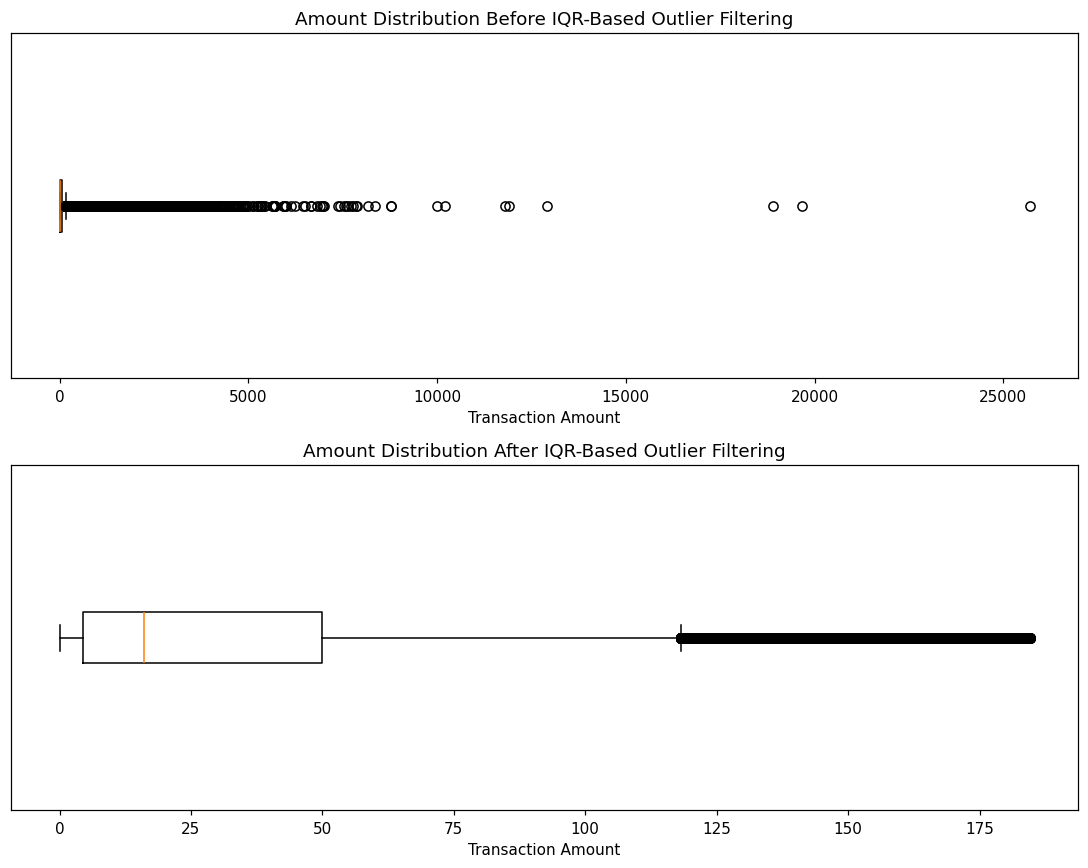

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), dpi=110)

# Before removing IQR-based outliers
axes[0].boxplot(df["Amount"], vert=False)
axes[0].set_title("Amount Distribution Before IQR-Based Outlier Filtering")
axes[0].set_xlabel("Transaction Amount")
axes[0].set_yticks([])

# After removing IQR-based outliers
axes[1].boxplot(clean_df["Amount"], vert=False)
axes[1].set_title("Amount Distribution After IQR-Based Outlier Filtering")
axes[1].set_xlabel("Transaction Amount")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

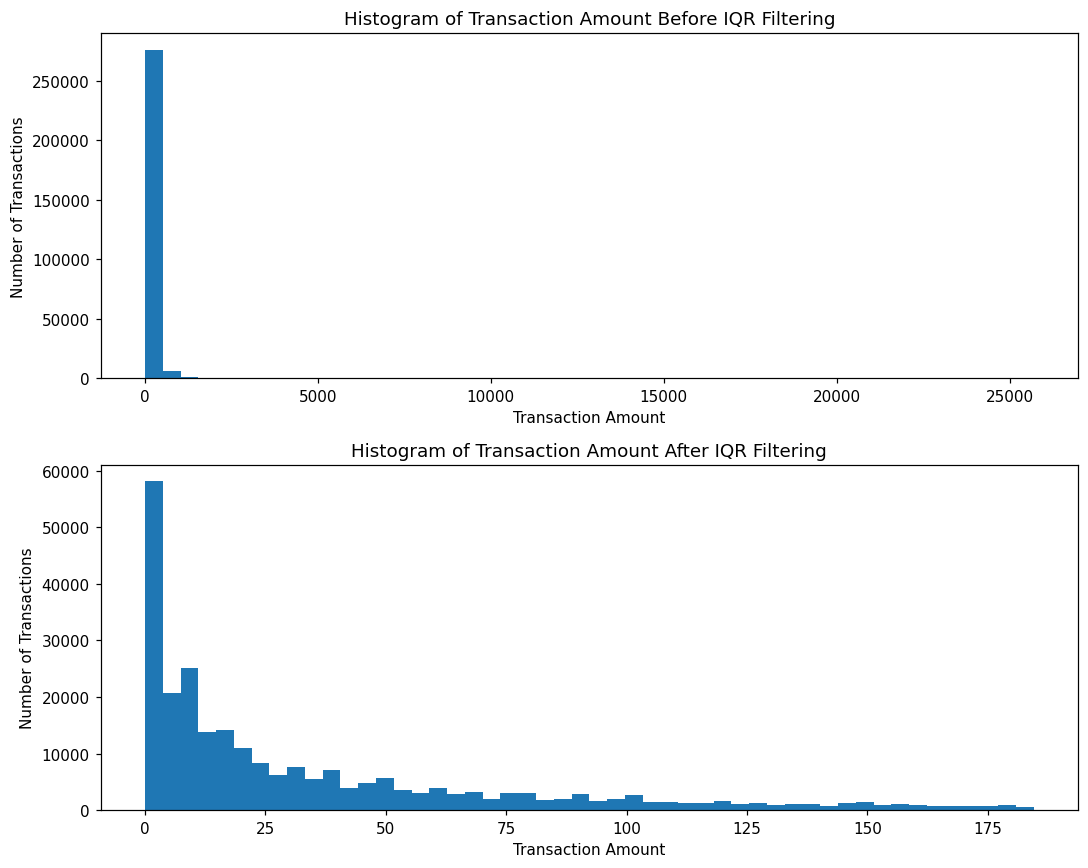

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), dpi=110)

axes[0].hist(df["Amount"], bins=50)
axes[0].set_title("Histogram of Transaction Amount Before IQR Filtering")
axes[0].set_xlabel("Transaction Amount")
axes[0].set_ylabel("Number of Transactions")

axes[1].hist(clean_df["Amount"], bins=50)
axes[1].set_title("Histogram of Transaction Amount After IQR Filtering")
axes[1].set_xlabel("Transaction Amount")
axes[1].set_ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

## Visual analysis of the `Amount` feature

The boxplots provide the clearest comparison of the `Amount` feature before and after IQR-based filtering.

For the original dataset, the distribution is heavily right-skewed and contains many extreme values. These outliers compress the main body of the data and make a standard histogram difficult to interpret visually. For this reason, the histogram is shown mainly for the IQR-filtered version, where the central distribution of transaction amounts can be observed more clearly.

## Final note on the IQR-based outlier analysis

Although an IQR-based filtered version of the dataset (`clean_df`) was created during the exploratory stage, it was used only for **visual comparison** and **outlier inspection**. It was **not** used in the final modelling pipeline.

This decision was made because, in a fraud-detection context, extreme transaction amounts may represent meaningful anomalous behaviour rather than simple noise or data error. Removing them mechanically could discard potentially useful fraud-related information.

For this reason, the final modelling workflow continued with the **original dataset**, while the IQR analysis was retained as an exploratory step to better understand the distribution of the `Amount` feature.

## Separating features and target

Before scaling and later modelling, the dataset is divided into:

- `X`: the predictor variables,
- `y`: the target variable.

Here, `Class` is the target label, where:
- `0` represents a legitimate transaction,
- `1` represents a fraudulent transaction.

This is a standard step in supervised machine learning before train-test split, scaling, resampling, and model training.

In [16]:
X = df.drop(columns=["Class"])
y = df["Class"]

## Train-test split before scaling

After separating the features and target, the dataset is divided into training and test sets before applying the scaling step.

This is done to avoid data leakage. The scaler must be fitted only on the training data, and then the same transformation is applied to the test data. This ensures that information from the test set is not used during preprocessing.

The split uses 80% of the data for training and 20% for testing. A fixed `random_state` is used to make the results reproducible, and `stratify=y` is used to preserve the same fraud/non-fraud class distribution in both the training and test sets.

From this point onward, the workflow continues with:

- scaling fitted on the training set,
- resampling applied only to the training set,
- model training,
- and final evaluation on the untouched test set.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

from collections import Counter
print("Original training class distribution:", Counter(y_train))
print("Original test class distribution:", Counter(y_test))

Original training class distribution: Counter({0: 227451, 1: 394})
Original test class distribution: Counter({0: 56864, 1: 98})


## 2.5 Min-Max Scaling

`MinMaxScaler` rescales each feature into a fixed interval, usually between 0 and 1.

This can be useful when all variables need to share the same numerical range. In this notebook, Min-Max scaling is included as part of the preprocessing comparison. It also helps show why scaling choices matter for distance-based and gradient-based models.

The main modelling workflow later uses scaled training and test data fitted only on the training set to reduce the risk of data leakage.

In [18]:
from sklearn.preprocessing import MinMaxScaler

In [19]:
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

print(X_normalized[:5])

[[0.00000000e+00 9.35192337e-01 7.66490419e-01 8.81364903e-01
  3.13022659e-01 7.63438735e-01 2.67668642e-01 2.66815176e-01
  7.86444198e-01 4.75311734e-01 5.10600482e-01 2.52484319e-01
  6.80907625e-01 3.71590602e-01 6.35590530e-01 4.46083696e-01
  4.34392391e-01 7.37172553e-01 6.55065861e-01 5.94863228e-01
  5.82942230e-01 5.61184389e-01 5.22992116e-01 6.63792975e-01
  3.91252676e-01 5.85121795e-01 3.94556792e-01 4.18976135e-01
  3.12696634e-01 5.82379309e-03]
 [0.00000000e+00 9.78541955e-01 7.70066651e-01 8.40298490e-01
  2.71796491e-01 7.66120336e-01 2.62191698e-01 2.64875439e-01
  7.86298353e-01 4.53980968e-01 5.05267346e-01 3.81187722e-01
  7.44341569e-01 4.86190176e-01 6.41219007e-01 3.83839664e-01
  4.64105178e-01 7.27793983e-01 6.40681094e-01 5.51930422e-01
  5.79529753e-01 5.57839915e-01 4.80236960e-01 6.66937823e-01
  3.36439996e-01 5.87290252e-01 4.46012969e-01 4.16345145e-01
  3.13422663e-01 1.04705276e-04]
 [5.78730497e-06 9.35217023e-01 7.53117667e-01 8.68140819e-01
  2.

If we want it back as a dataframe:

In [20]:
X_normalized_df = pd.DataFrame(X_normalized, columns=X.columns)
X_normalized_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.000000,0.935192,0.766490,0.881365,0.313023,0.763439,0.267669,0.266815,0.786444,0.475312,...,0.582942,0.561184,0.522992,0.663793,0.391253,0.585122,0.394557,0.418976,0.312697,0.005824
1,0.000000,0.978542,0.770067,0.840298,0.271796,0.766120,0.262192,0.264875,0.786298,0.453981,...,0.579530,0.557840,0.480237,0.666938,0.336440,0.587290,0.446013,0.416345,0.313423,0.000105
2,0.000006,0.935217,0.753118,0.868141,0.268766,0.762329,0.281122,0.270177,0.788042,0.410603,...,0.585855,0.565477,0.546030,0.678939,0.289354,0.559515,0.402727,0.415489,0.311911,0.014739
3,0.000006,0.941878,0.765304,0.868484,0.213661,0.765647,0.275559,0.266803,0.789434,0.414999,...,0.578050,0.559734,0.510277,0.662607,0.223826,0.614245,0.389197,0.417669,0.314371,0.004807
4,0.000012,0.938617,0.776520,0.864251,0.269796,0.762975,0.263984,0.268968,0.782484,0.490950,...,0.584615,0.561327,0.547271,0.663392,0.401270,0.566343,0.507497,0.420561,0.317490,0.002724


## Standardisation with StandardScaler

`StandardScaler` transforms the features so that they are centred around mean 0 with standard deviation 1.

This is particularly useful for scale-sensitive models such as KNN, Logistic Regression, Neural Networks, and SVM, because these algorithms can be strongly affected by differences in feature magnitude.

Although tree-based models such as Decision Tree, Random Forest, and XGBoost do not strictly require scaling, `StandardScaler` was retained as the main scaling method in this project in order to support the scale-sensitive classifiers and to keep the preprocessing workflow more consistent across model comparisons.

Min-Max scaling was also explored during preprocessing, but it was not retained as the final scaling approach. This was mainly because the dataset contains strong outlier behaviour (because outliers were intentionally retained after exploratory review), especially in `Amount`, and Min-Max scaling is highly sensitive to extreme values since it depends directly on the minimum and maximum of each feature. By contrast, `StandardScaler` was considered a more robust and more suitable choice for the scale-sensitive models explored later in the project, while also providing a more consistent preprocessing workflow across model comparisons.

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

If we want it back as a dataframe:

In [23]:
X_standardized_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_standardized_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,1.411588,0.993379,-0.456037,-0.894052,-0.467284,1.089217,3.024383,-1.194852,0.957057,1.281376,...,-0.173112,0.103171,0.409563,0.490685,1.141970,-0.670832,-0.807227,0.191912,-0.099106,-0.322494
1,0.623141,1.038507,-0.029349,-2.018302,0.175133,2.133506,2.478840,-0.001832,0.566704,0.041121,...,-0.293564,0.052055,0.314019,0.056568,1.168583,0.985238,-0.977976,0.006397,-0.211524,-0.339764
2,-1.130680,-0.506766,0.366065,0.470114,-0.700918,-0.598748,1.470411,-1.786684,-4.227592,0.000064,...,1.663010,-3.807987,0.150500,-0.695838,-1.540549,1.587269,1.895777,0.094137,0.566426,0.346693
3,0.794699,1.166419,-0.909447,-0.493095,-1.178149,-1.010692,-0.262292,-1.153123,0.008765,-1.019866,...,-0.635236,-0.190540,0.105701,0.331932,-0.888718,-0.532153,-0.336546,0.044738,-0.193183,-0.327360
4,-0.748102,-0.229485,-0.613041,0.076742,-2.440089,0.518711,-0.109914,0.407186,-0.095161,-0.041449,...,-0.355860,-0.331467,-0.239208,-0.010747,-2.250223,-0.559400,-0.300345,-0.080285,-0.196818,-0.008281


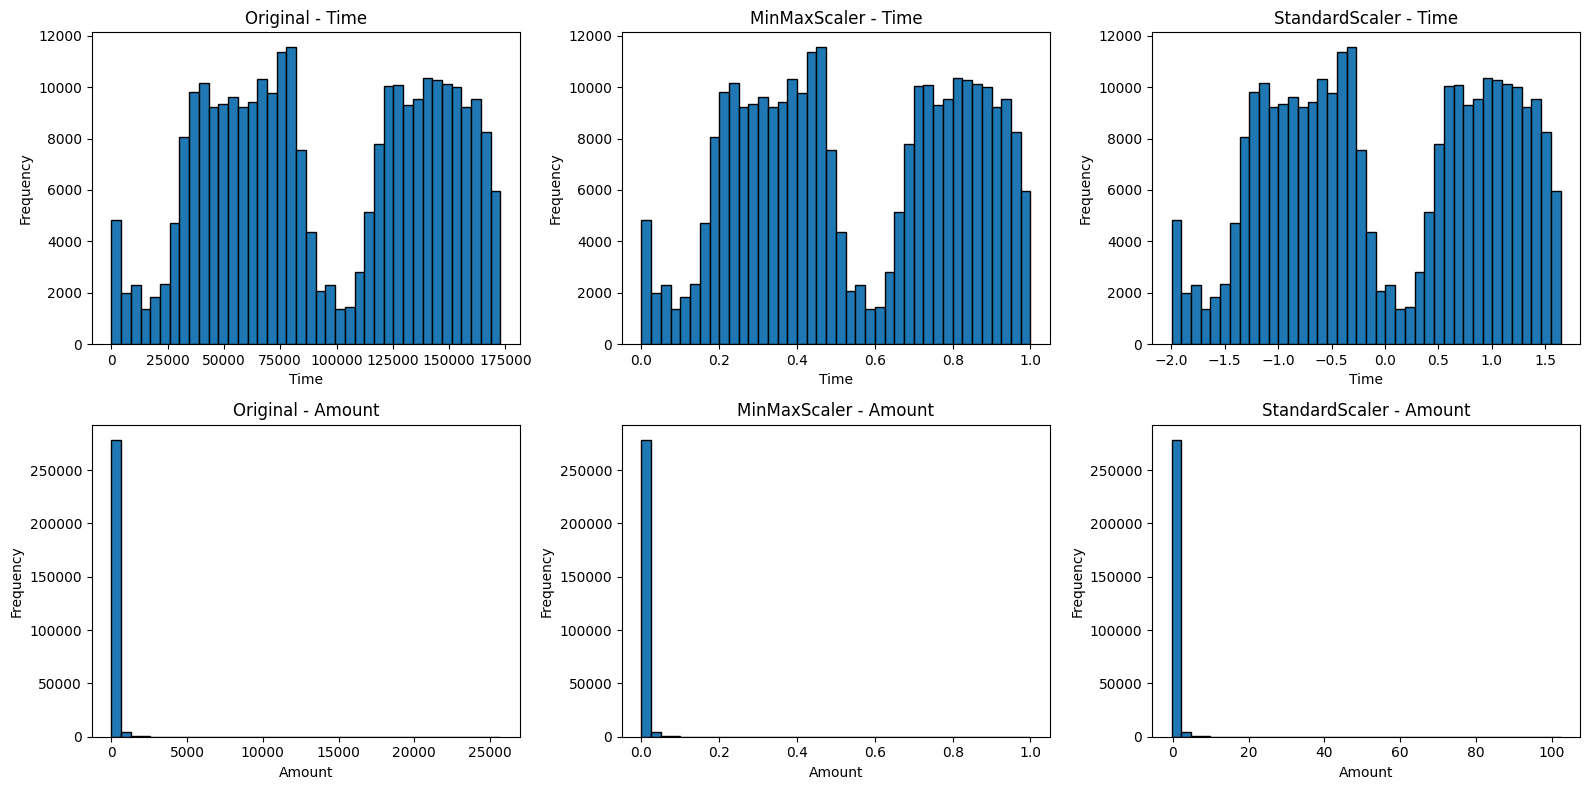

In [24]:
# ============================================================
# Visual comparison: Original vs MinMaxScaler vs StandardScaler
# ============================================================

from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Select the most interpretable features
features_to_plot = ["Time", "Amount"]

# Copy only the selected columns
X_compare = df[features_to_plot].copy()

# Apply scalers
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

X_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(X_compare),
    columns=features_to_plot
)

X_standard = pd.DataFrame(
    standard_scaler.fit_transform(X_compare),
    columns=features_to_plot
)

# Plot histograms
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, feature in enumerate(features_to_plot):
    # Original
    axes[i, 0].hist(X_compare[feature], bins=40, edgecolor="black")
    axes[i, 0].set_title(f"Original - {feature}")
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel("Frequency")

    # MinMax
    axes[i, 1].hist(X_minmax[feature], bins=40, edgecolor="black")
    axes[i, 1].set_title(f"MinMaxScaler - {feature}")
    axes[i, 1].set_xlabel(feature)
    axes[i, 1].set_ylabel("Frequency")

    # Standard
    axes[i, 2].hist(X_standard[feature], bins=40, edgecolor="black")
    axes[i, 2].set_title(f"StandardScaler - {feature}")
    axes[i, 2].set_xlabel(feature)
    axes[i, 2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

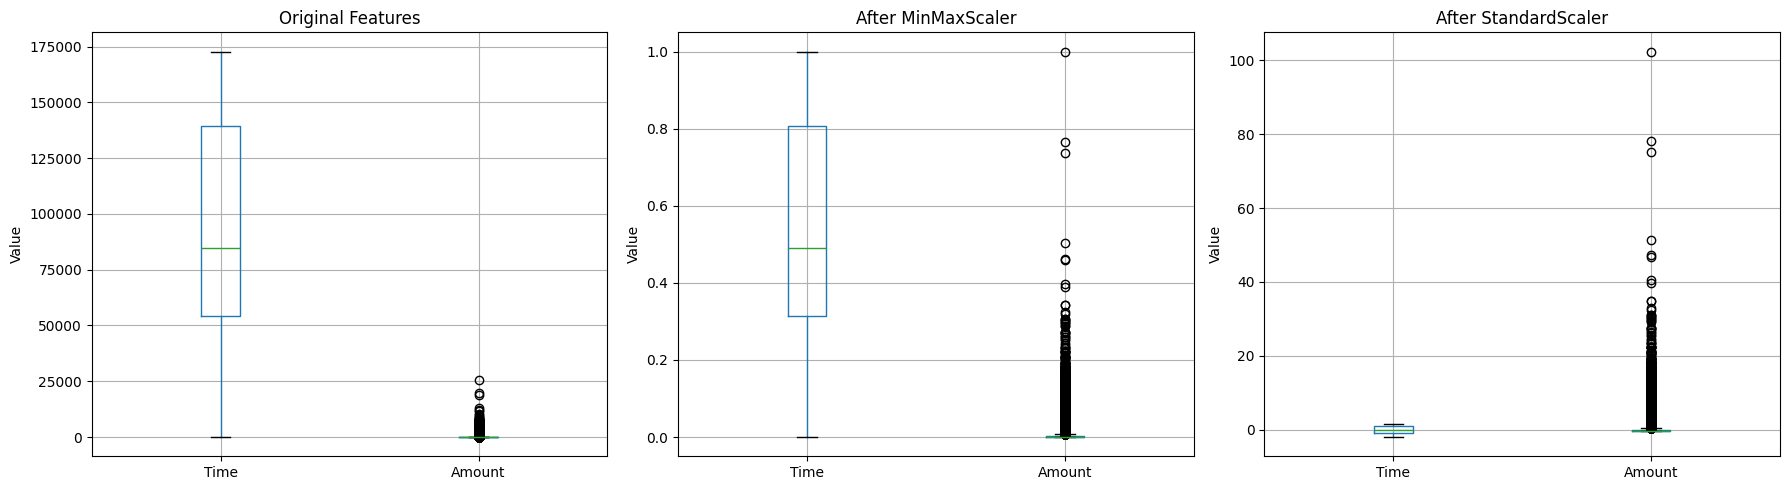

In [25]:
# ============================================================
# Boxplot comparison: Original vs MinMaxScaler vs StandardScaler
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

X_compare.boxplot(ax=axes[0])
axes[0].set_title("Original Features")
axes[0].set_ylabel("Value")

X_minmax.boxplot(ax=axes[1])
axes[1].set_title("After MinMaxScaler")
axes[1].set_ylabel("Value")

X_standard.boxplot(ax=axes[2])
axes[2].set_title("After StandardScaler")
axes[2].set_ylabel("Value")

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# Summary statistics after scaling
# ============================================================

summary_df = pd.DataFrame({
    "Original Mean": X_compare.mean(),
    "Original Std": X_compare.std(),
    "MinMax Mean": X_minmax.mean(),
    "MinMax Std": X_minmax.std(),
    "Standard Mean": X_standard.mean(),
    "Standard Std": X_standard.std()
})

display(summary_df.round(4))

,Original Mean,Original Std,MinMax Mean,MinMax Std,Standard Mean,Standard Std
Time,94813.8596,47488.1460,0.5487,0.2748,-0.0,1.0
Amount,88.3496,250.1201,0.0034,0.0097,-0.0,1.0


## Correlation analysis

The correlation matrix is used to explore the linear relationships between the variables.

This helps identify:
- whether some features are strongly related to each other,
- and whether some features appear more related to the target class than others.

This stage also acts as a first introduction to feature analysis, although it is not yet a full feature selection procedure.

In [27]:
corr = df.corr()
corr

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,1.173963e-01,-1.059333e-02,-4.196182e-01,-1.052602e-01,1.730721e-01,-6.301647e-02,8.471437e-02,-3.694943e-02,-8.660434e-03,...,4.473573e-02,1.440591e-01,5.114236e-02,-1.618187e-02,-2.330828e-01,-4.140710e-02,-5.134591e-03,-9.412688e-03,-0.010596,-0.012323
V1,0.117396,1.000000e+00,4.135835e-16,-1.227819e-15,-9.215150e-16,1.812612e-17,-6.506567e-16,-1.005191e-15,-2.433822e-16,-1.513678e-16,...,-2.457409e-16,-4.290944e-16,6.168652e-16,-4.425156e-17,-9.605737e-16,-1.581290e-17,1.198124e-16,2.083082e-15,-0.227709,-0.101347
V2,-0.010593,4.135835e-16,1.000000e+00,3.243764e-16,-1.121065e-15,5.157519e-16,2.787346e-16,2.055934e-16,-5.377041e-17,1.978488e-17,...,-8.480447e-17,1.526333e-16,1.634231e-16,1.247925e-17,-4.478846e-16,2.057310e-16,-4.966953e-16,-5.093836e-16,-0.531409,0.091289
V3,-0.419618,-1.227819e-15,3.243764e-16,1.000000e+00,4.711293e-16,-6.539009e-17,1.627627e-15,4.895305e-16,-1.268779e-15,5.568367e-16,...,5.706192e-17,-1.133902e-15,-4.983035e-16,2.686834e-19,-1.104734e-15,-1.238062e-16,1.045747e-15,9.775546e-16,-0.210880,-0.192961
V4,-0.105260,-9.215150e-16,-1.121065e-15,4.711293e-16,1.000000e+00,-1.719944e-15,-7.491959e-16,-4.104503e-16,5.697192e-16,6.923247e-16,...,-1.949553e-16,-6.276051e-17,9.164206e-17,1.584638e-16,6.070716e-16,-4.247268e-16,3.977061e-17,-2.761403e-18,0.098732,0.133447
V5,0.173072,1.812612e-17,5.157519e-16,-6.539009e-17,-1.719944e-15,1.000000e+00,2.408382e-16,2.715541e-16,7.437229e-16,7.391702e-16,...,-3.920976e-16,1.253751e-16,-8.428683e-18,-1.149255e-15,4.808532e-16,4.319541e-16,6.590482e-16,-5.613951e-18,-0.386356,-0.094974
V6,-0.063016,-6.506567e-16,2.787346e-16,1.627627e-15,-7.491959e-16,2.408382e-16,1.000000e+00,1.191668e-16,-1.104219e-16,4.131207e-16,...,5.833316e-17,-4.705235e-19,1.046712e-16,-1.071589e-15,4.562861e-16,-1.357067e-16,-4.452461e-16,2.594754e-16,0.215981,-0.043643
V7,0.084714,-1.005191e-15,2.055934e-16,4.895305e-16,-4.104503e-16,2.715541e-16,1.191668e-16,1.000000e+00,3.344412e-16,1.122501e-15,...,-2.027779e-16,-8.898922e-16,-4.387401e-16,7.434913e-18,-3.094082e-16,-9.657637e-16,-1.782106e-15,-2.776530e-16,0.397311,-0.187257
V8,-0.036949,-2.433822e-16,-5.377041e-17,-1.268779e-15,5.697192e-16,7.437229e-16,-1.104219e-16,3.344412e-16,1.000000e+00,4.356078e-16,...,3.892798e-16,2.026927e-16,6.377260e-17,-1.047097e-16,-4.653279e-16,-1.727276e-16,1.299943e-16,-6.200930e-16,-0.103079,0.019875
V9,-0.008660,-1.513678e-16,1.978488e-17,5.568367e-16,6.923247e-16,7.391702e-16,4.131207e-16,1.122501e-15,4.356078e-16,1.000000e+00,...,1.936953e-16,-7.071869e-16,-5.214137e-16,-1.430343e-16,6.757763e-16,-7.888853e-16,-6.709655e-17,1.110541e-15,-0.044246,-0.097733


## Heatmap

The heatmap provides a visual representation of the correlation matrix.

It helps identify:
- variables with stronger positive or negative relationships,
- and whether the target variable `Class` appears to be more strongly associated with some predictors than with others.

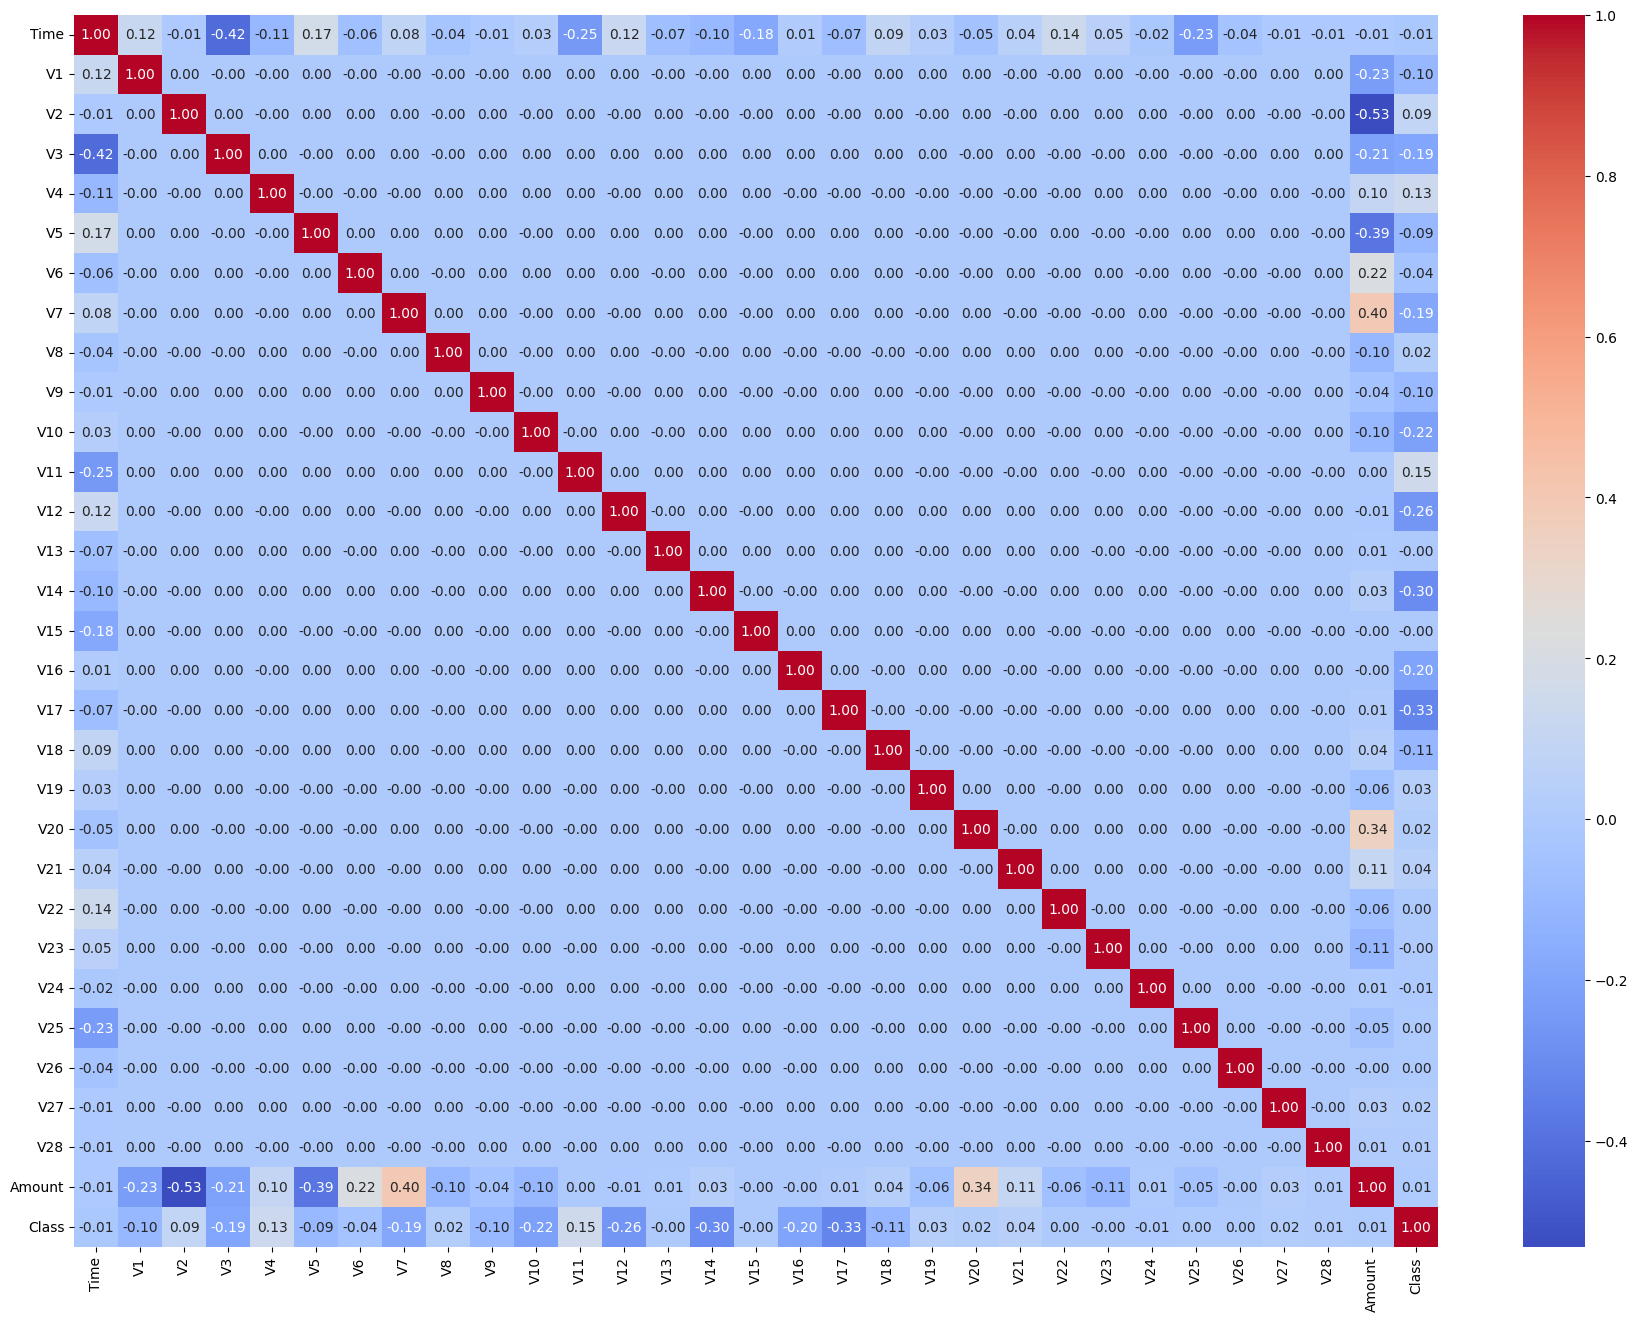

In [28]:
plt.figure(figsize=(22, 16))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

Many values are very close to zero, which indicates weak linear relationships for most feature pairs.

## Inspecting the relationship with the target variable

After the heatmap, the correlations with `Class` are examined directly.

This makes it easier to identify which variables are more positively or negatively associated with fraud, without having to read the entire heatmap manually.

This step also provides a simple feature-selection intuition, although the teacher in class only introduced feature selection briefly at this stage and did not yet implement it fully in code.

In [29]:
corr = df.corr(numeric_only=True)
class_corr = corr["Class"].sort_values(ascending=False).to_frame()
class_corr

,Class
Class,1.000000
V11,0.154876
V4,0.133447
V2,0.091289
V21,0.040413
V19,0.034783
V20,0.020090
V8,0.019875
V27,0.017580
V28,0.009536


## Showing only the most relevant correlations

Most variables have correlations very close to zero, so a filtered view is useful.

By keeping only correlations whose absolute value is greater than 0.1, we focus on the variables that appear more strongly related to the target class.

This does not represent a final feature selection method.
It is only an initial interpretation step.

In [30]:
class_corr[abs(class_corr["Class"]) > 0.1]

,Class
Class,1.000000
V11,0.154876
V4,0.133447
V1,-0.101347
V18,-0.111485
V7,-0.187257
V3,-0.192961
V16,-0.196539
V10,-0.216883
V12,-0.260593


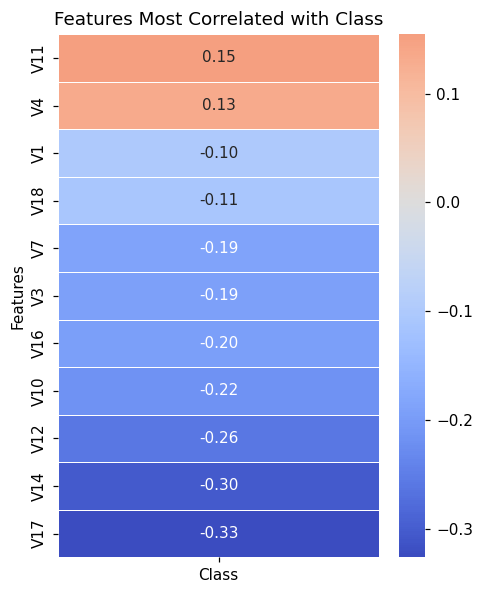

In [31]:
# Small heatmap: only the features most correlated with Class

import matplotlib.pyplot as plt
import seaborn as sns

# Keep only relevant correlations and drop Class itself from the display
top_class_corr = class_corr[abs(class_corr["Class"]) > 0.1].drop(index="Class", errors="ignore")

# Optional: sort so positives appear at the top and negatives at the bottom
top_class_corr = top_class_corr.sort_values(by="Class", ascending=False)

plt.figure(figsize=(4.5, 5.5), dpi=110)
sns.heatmap(
    top_class_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar=True
)

plt.title("Features Most Correlated with Class")
plt.xlabel("")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# 3. Class Imbalance and Resampling Strategy

After numerical preprocessing, the next key issue is class imbalance.

In fraud detection, fraudulent transactions are much rarer than legitimate ones. If this imbalance is ignored, a model can achieve very high accuracy by predicting almost every transaction as non-fraudulent, while failing to detect the minority class.

This section therefore explores the class distribution and applies imbalance-handling strategies before model comparison.

## Checking the class distribution

The target variable is now examined to determine whether the dataset is balanced or imbalanced.

This step is essential because machine learning models can be strongly affected by class imbalance.
If one class dominates the dataset, overall accuracy may become misleading.

In [32]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

## Why percentages are useful

The raw class counts show the absolute number of observations in each class, but percentages make the imbalance easier to interpret.

In [33]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

For this dataset, we can see that fraudulent transactions represent only a very small proportion of the total observations.
This confirms that the problem is a severe class imbalance problem.

## Visualising the imbalance

The class distribution is also represented visually.

This plot makes it easier to see that the fraud class is much smaller than the non-fraud class.

This is important because it explains why later model evaluation cannot rely on accuracy alone.

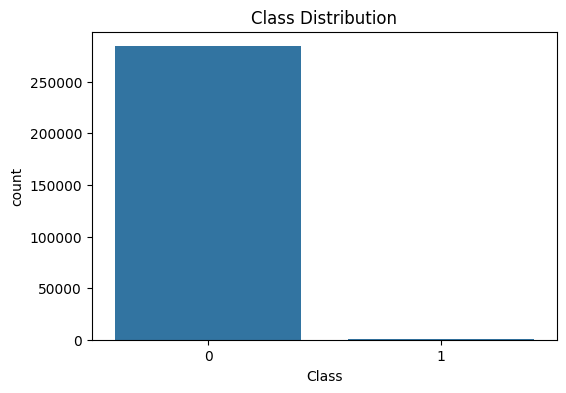

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution")
plt.show()

## 3.4 Exploring Class-Imbalance Handling Methods

The dataset is highly imbalanced, so several imbalance-handling strategies are explored before final model selection.

Three resampling methods are applied to the scaled training data only:

- Random Under-Sampling
- Random Over-Sampling
- SMOTE

These methods directly modify the training data in different ways to reduce the dominance of the majority class.

In addition, class weights are tested as a form of cost-sensitive learning. Unlike resampling, class weights do not change the dataset itself; they change how strongly the model penalises mistakes on the minority class.

All resampling is restricted to the training data. The test set remains untouched so that final evaluation reflects performance on unseen data.

In [35]:
# If running in a fresh environment, install the required package before importing:
# %pip install -q imbalanced-learn

In [36]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

## Random Under-Sampling

Random under-sampling balances the classes by removing majority-class observations until both classes have the same size.

Its main advantage is simplicity.
Its main drawback is that a large amount of potentially useful information is lost.

In [37]:
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_under, y_train_under = rus.fit_resample(X_train_scaled, y_train)

## Random Over-Sampling

Random over-sampling balances the dataset by duplicating examples from the minority class until both classes are more evenly represented.

This approach avoids removing majority-class transactions, which means no original legitimate transaction data is lost. However, it can increase the risk of overfitting because the model may repeatedly see the same fraud cases during training.

In [38]:
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_over, y_train_over = ros.fit_resample(X_train_scaled, y_train)

## SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) balances the classes by generating synthetic minority examples instead of exact duplicates.

This often makes it a more attractive starting point than simple over-sampling, because it may help the model learn a broader range of fraud patterns.

However, this does not automatically make SMOTE the best final choice.
Its usefulness must still be evaluated through later model performance.

In [39]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Original:", Counter(y_train))
print("Under-sampled:", Counter(y_train_under))
print("Over-sampled:", Counter(y_train_over))
print("SMOTE:", Counter(y_train_smote))

Original: Counter({0: 227451, 1: 394})
Under-sampled: Counter({0: 394, 1: 394})
Over-sampled: Counter({0: 227451, 1: 227451})
SMOTE: Counter({0: 227451, 1: 227451})


## Comparing the class distributions after resampling

The following graph shows how the class distribution changes under each method.

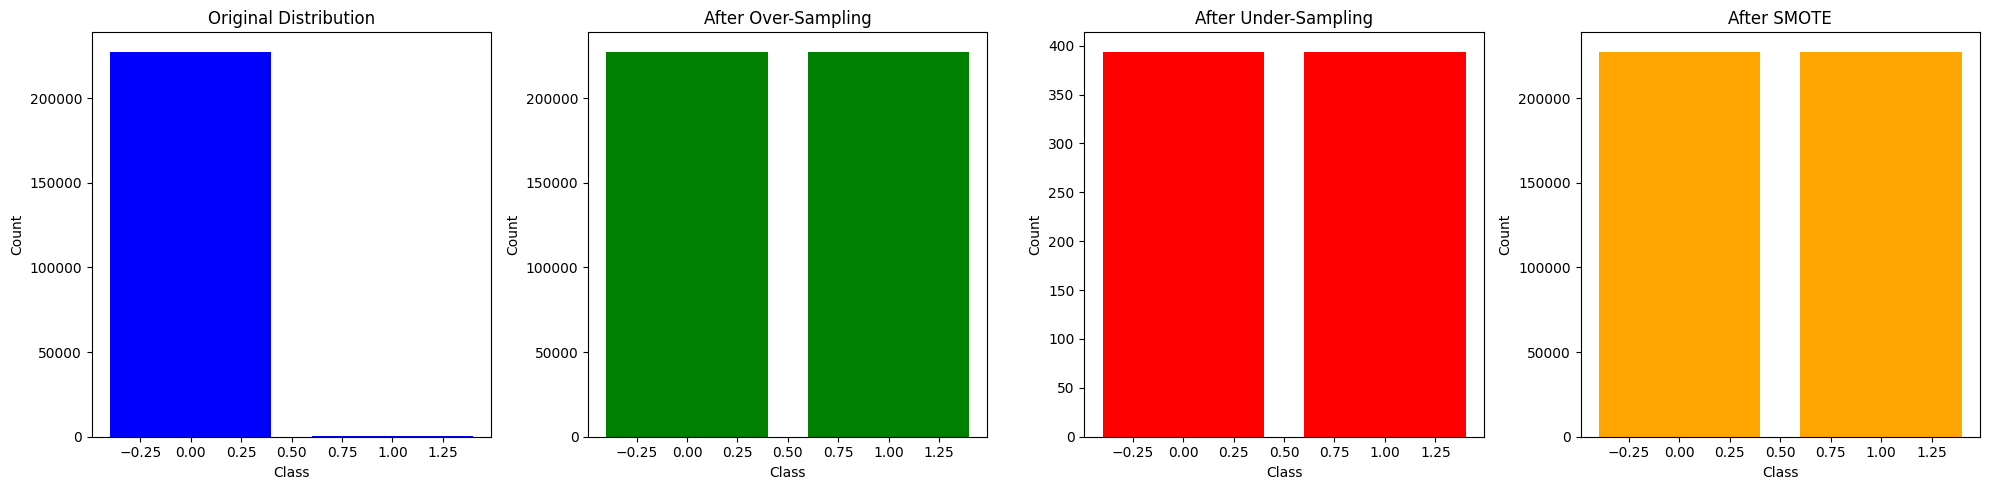

In [40]:
from collections import Counter

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].bar(Counter(y_train).keys(), Counter(y_train).values(), color='b')
axes[0].set_title('Original Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

axes[1].bar(Counter(y_train_over).keys(), Counter(y_train_over).values(), color='g')
axes[1].set_title('After Over-Sampling')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

axes[2].bar(Counter(y_train_under).keys(), Counter(y_train_under).values(), color='r')
axes[2].set_title('After Under-Sampling')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Count')

axes[3].bar(Counter(y_train_smote).keys(), Counter(y_train_smote).values(), color='orange')
axes[3].set_title('After SMOTE')
axes[3].set_xlabel('Class')
axes[3].set_ylabel('Count')

plt.tight_layout()
plt.show()

## A note on class weights

The previous graph compares only the **resampling methods**, because those methods physically change the class distribution of the training data.

However, **class weights** are different. They do **not** create, remove, or duplicate observations, so they do not produce a new class-distribution graph.

Instead, class weights are applied later during model training.
They make the classifier penalise mistakes on the minority fraud class more strongly, which can help the model pay more attention to fraud without changing the dataset itself.


This is useful because it makes the effect of each resampling strategy visible:

- the original data is strongly imbalanced,
- under-sampling reduces the majority class drastically,
- over-sampling duplicates the minority class,
- SMOTE balances the data using synthetic examples.

At this stage, these methods are still being explored rather than definitively selected.

In [41]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

class_weights_dict = dict(zip(classes, weights))
print("Computed class weights:", class_weights_dict)

Computed class weights: {np.int64(0): np.float64(0.5008661206149896), np.int64(1): np.float64(289.14340101522845)}


## Interpreting the class weights

The computed class weights show that the minority fraud class receives a much larger weight than the majority non-fraud class.

This means that, during training, mistakes on fraudulent transactions will be penalised more strongly than mistakes on legitimate ones.

For this reason, class weighting is a valid **cost-sensitive learning** strategy for handling class imbalance, even though it is not a resampling method.

Besides resampling, **class weights** were also considered as an imbalance-handling strategy. Again, unlike resampling, they do not alter the training data itself, but instead change how strongly the model penalises errors on the minority class. This makes class weighting a useful cost-sensitive learning approach for later model training.

## Why several imbalance-handling strategies are taken forward to modelling

At this stage, several imbalance-handling methods have already been explored: Random Under-Sampling, Random Over-Sampling, SMOTE, and class weights.

In the `creditcard.csv` dataset, the imbalance is extremely severe: legitimate transactions are overwhelmingly more frequent than fraudulent ones. Because of this, using the original training set alone may cause some models to focus too heavily on the majority class and fail to detect enough fraud cases.

Random Under-Sampling was not prioritised for the main modelling stage because, in this dataset, it would remove a very large number of legitimate transactions and therefore discard a substantial amount of potentially useful majority-class information.

By contrast, Random Over-Sampling, SMOTE, and class weights all offer ways of addressing imbalance without discarding most of the majority class:

- **Random Over-Sampling** keeps all majority-class data, but balances the training set by repeating minority fraud cases.
- **SMOTE** also preserves the majority class, but instead of duplicating minority observations exactly, it generates synthetic minority examples based on existing minority patterns.
- **Class weights** do not modify the dataset itself, but implement a cost-sensitive learning strategy by making the model penalise errors on the minority fraud class more strongly during training.

For this reason, the modelling stage is not limited to a single imbalance-handling method from the start.
Instead, the main training strategies taken forward are:

- **Original training set**
- **Random Over-Sampling**
- **SMOTE**
- **Class Weights**

This allows the impact of each strategy to be evaluated directly through later model performance.
In this project, the final imbalance-handling choice is not assumed in advance, but selected after comparing recall, precision, F1-score, ROC-AUC, and the confusion matrix.

# 4. Model Training and Evaluation

After preprocessing and class-imbalance handling, several classification models are trained and evaluated.

The goal of this stage is not only to run the models, but to understand how different classifiers behave under different training strategies.

Because this is a fraud-detection problem, evaluation focuses on minority-class performance rather than accuracy alone.

## Evaluation metrics used in this stage

Because this is a **fraud detection** problem with severe class imbalance, model evaluation cannot rely on accuracy alone.
A classifier may achieve very high accuracy simply by predicting the majority non-fraud class most of the time, while still missing many fraud cases.

For this reason, the following metrics are used throughout the modelling stage:

### Confusion matrix terms

For a binary fraud detection problem:

- **True Positive (TP):** a fraudulent transaction correctly predicted as fraud.
- **True Negative (TN):** a legitimate transaction correctly predicted as legitimate.
- **False Positive (FP):** a legitimate transaction incorrectly predicted as fraud.
- **False Negative (FN):** a fraudulent transaction incorrectly predicted as legitimate.

In fraud detection, **false negatives** are especially important because they represent fraud cases that escape detection. However, **false positives** also matter, because too many false alarms may create unnecessary operational cost and inconvenience for customers.

### Accuracy

Accuracy measures the proportion of all predictions that are correct:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

Although useful as a general indicator, accuracy can be misleading in highly imbalanced datasets.

### Precision

Precision measures how reliable the fraud predictions are:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

A high precision means that when the model predicts fraud, it is usually correct.

### Recall

Recall measures how many of the real fraud cases are successfully detected:

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

In fraud detection, recall is especially important because it reflects the ability to capture fraudulent transactions.

### F1-score

The F1-score combines **precision** and **recall** into a single metric using their harmonic mean:

$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

This makes it useful when we want a balance between detecting fraud and avoiding too many false alarms.

### ROC-AUC

The ROC curve plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** across many possible decision thresholds.

The two quantities are defined as:

$$
TPR = \frac{TP}{TP + FN}
$$

$$
FPR = \frac{FP}{FP + TN}
$$

The **ROC-AUC** (Area Under the ROC Curve) summarizes the model’s ability to separate the two classes across all thresholds. A higher ROC-AUC indicates better discrimination between fraudulent and legitimate transactions.

Formally, ROC-AUC can be interpreted as the area under the ROC curve:

$$
ROC\text{-}AUC = \int_0^1 TPR(FPR)\, d(FPR)
$$

In practice, ROC-AUC is especially useful as a threshold-independent measure, but in highly imbalanced fraud problems it should still be interpreted together with precision, recall, F1-score, and the confusion matrix.

For this reason, the final model comparison in this project is based on a combination of precision, recall, F1-score, ROC-AUC, and the confusion matrix, rather than on accuracy alone. Additionally, for highly imbalanced classification problems, Precision-Recall AUC (PR-AUC) can also be considered, as it provides a more informative evaluation of minority-class detection performance.

## Training strategies taken forward to model comparison

At this stage, the modelling process is not limited to a single imbalance-handling method.

Instead, four training strategies are taken forward for comparison:

- **Original training set**
- **Random Over-Sampling**
- **SMOTE**
- **Class Weights**

Random Under-Sampling is not prioritised for the main modelling stage because, in this dataset, it would remove a very large number of majority-class observations and therefore discard a substantial amount of potentially useful information.

This means that the final imbalance-handling choice will not be assumed in advance, but will be selected later according to model performance.

In [42]:
# Training strategies that will be compared during the modelling stage:

training_strategies = {
    "Original": (X_train_scaled, y_train),
    "Over-Sampling": (X_train_over, y_train_over),
    "SMOTE": (X_train_smote, y_train_smote)
}

print("Available training strategies:\n")
for name, (X_data, y_data) in training_strategies.items():
    print(f"{name}:")
    print("  Training shape:", X_data.shape)
    print("  Class distribution:", Counter(y_data))
    print()

print("Test shape:", X_test_scaled.shape)
print("Test class distribution:", Counter(y_test))

Available training strategies:

Original:
  Training shape: (227845, 30)
  Class distribution: Counter({0: 227451, 1: 394})

Over-Sampling:
  Training shape: (454902, 30)
  Class distribution: Counter({0: 227451, 1: 227451})

SMOTE:
  Training shape: (454902, 30)
  Class distribution: Counter({0: 227451, 1: 227451})

Test shape: (56962, 30)
Test class distribution: Counter({0: 56864, 1: 98})


## Models used in this stage

The following classification models are explored in this order and compared in this stage:

- **Neural Network (MLPClassifier)**
- **Neural Network (Keras/TensorFlow)**
- **Random Forest**
- **Logistic Regression**
- **KNN**
- **Decision Tree**
- **XGBoost**


These models represent different learning approaches:

- **Logistic Regression** is a linear probabilistic classifier and provides a strong baseline.
- **Decision Tree** is a rule-based model that can capture non-linear relationships.
- **Random Forest** is an ensemble of decision trees designed to improve stability and predictive performance.
- **XGBoost** is a gradient boosting model that is often particularly strong on tabular datasets.
- **KNN** is a distance-based classifier that predicts a label from the nearest neighbours in the feature space.
- **Neural Networks** are non-linear models capable of learning more complex patterns.


The main comparison therefore focuses on the models above, using the following training strategies:

- **Original training set**
- **Random Over-Sampling**
- **SMOTE**
- **Class Weights**

This makes it possible to compare not only different models, but also different ways of handling class imbalance.

## 4.3 Models Not Retained for the Main Comparison

Some additional models were considered or partially explored, but they were not retained as part of the main final comparison for methodological and practical reasons:

- **Support Vector Machine (SVM)** was considered because it is a standard supervised learning model, but it was not retained due to computational cost on this dataset.
- Other experimental variants were excluded when they did not add meaningful insight compared with the selected model families.

The main comparison therefore focuses on models that are interpretable, computationally feasible and relevant for imbalanced classification.

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Base training strategies (class weights is handled inside the model, not as a separate dataset)
training_sets = {
    "Original": (X_train_scaled, y_train),
    "Over-Sampling": (X_train_over, y_train_over),
    "SMOTE": (X_train_smote, y_train_smote)
}

def evaluate_binary_model(model, X_train_used, y_train_used, X_test_used, y_test_used, strategy_name):
    model.fit(X_train_used, y_train_used)
    y_pred = model.predict(X_test_used)

    # Probability / score handling
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_used)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_used)
    else:
        y_score = None

    cm = confusion_matrix(y_test_used, y_pred)
    tn, fp, fn, tp = cm.ravel()

    row = {
        "Training Strategy": strategy_name,
        "Accuracy": accuracy_score(y_test_used, y_pred),
        "Precision": precision_score(y_test_used, y_pred, zero_division=0),
        "Recall": recall_score(y_test_used, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test_used, y_pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    if y_score is not None:
        row["ROC-AUC"] = roc_auc_score(y_test_used, y_score)
    else:
        row["ROC-AUC"] = np.nan

    return row

## Simple Neural Network (MLPClassifier)

A simple **Neural Network**, also known as a **Multi-Layer Perceptron (MLP)**, is a supervised learning model made up of interconnected layers of artificial neurons.

In this project, it is included as a first neural-network baseline in order to test whether a non-linear model can capture fraud patterns more effectively than simpler classifiers such as Logistic Regression.

### How it works

Each neuron receives inputs, applies a weighted sum plus a bias term, and then passes the result through an activation function.

For one neuron, this can be written as:

$$
z = w_1x_1 + w_2x_2 + \dots + w_px_p + b
$$

$$
a = g(z)
$$

where:
- $x_1, x_2, \dots, x_p$ are the input features,
- $w_1, w_2, \dots, w_p$ are the learned weights,
- $b$ is the bias term,
- $g(\cdot)$ is the activation function,
- and $a$ is the neuron output.

In this implementation, the hidden layers use the **ReLU** activation function:

$$
ReLU(z) = \max(0, z)
$$

For binary classification, the output layer produces a final probability for the fraud class.

### Training process

The model learns by adjusting its weights so that the predicted outputs become closer to the true labels.
This is done by minimising a loss function through iterative optimisation.

In practice, the training process can be summarised as follows:

1. pass the input data forward through the network,
2. compute the prediction error,
3. propagate that error backward through the network,
4. update the weights using an optimisation algorithm.

In this notebook, the simple neural network is implemented with `MLPClassifier`, using:

- two hidden layers: `(64, 32)`
- **ReLU** activation
- the **Adam** optimiser
- and a maximum of **300 iterations**

### Why it is useful here

A neural network can model more complex and non-linear relationships than Logistic Regression.
However, it also has some practical limitations:

- it may be more difficult to interpret,
- it may require more careful tuning,
- and it does not always outperform strong tree-based models on structured tabular data.

For this reason, the simple neural network is used first as an exploratory baseline before testing a more flexible **Keras/TensorFlow** implementation.

In [44]:
from sklearn.neural_network import MLPClassifier

nn_results = []

# Original / Over-Sampling / SMOTE
for strategy_name, (X_tr, y_tr) in training_sets.items():
    nn_model = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=RANDOM_STATE
    )
    nn_results.append(
        evaluate_binary_model(nn_model, X_tr, y_tr, X_test_scaled, y_test, strategy_name)
    )

# Class Weights not directly supported in sklearn MLPClassifier
nn_results.append({
    "Training Strategy": "Class Weights",
    "Accuracy": np.nan,
    "Precision": np.nan,
    "Recall": np.nan,
    "F1-Score": np.nan,
    "ROC-AUC": np.nan,
    "TN": np.nan,
    "FP": np.nan,
    "FN": np.nan,
    "TP": np.nan
})

nn_results_df = pd.DataFrame(nn_results)
print("\n--- Neural Network: Original vs Over-Sampling vs SMOTE vs Class Weights ---\n")
nn_results_df


--- Neural Network: Original vs Over-Sampling vs SMOTE vs Class Weights ---



,Training Strategy,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP,ROC-AUC
0,Original,0.999368,0.816327,0.816327,0.816327,56846.0,18.0,18.0,80.0,0.975319
1,Over-Sampling,0.998631,0.569444,0.836735,0.677686,56802.0,62.0,16.0,82.0,0.960979
2,SMOTE,0.999122,0.714286,0.816327,0.761905,56832.0,32.0,18.0,80.0,0.965487
3,Class Weights,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Interpretation of the simple Neural Network results

The simple neural network implemented with `MLPClassifier` produced credible results, especially in terms of **recall** and **ROC-AUC**. This suggests that the model was able to detect a meaningful proportion of fraud cases.

However, its **precision** remained noticeably lower than that of the strongest tree-based models (explored after). In practical terms, this means that the model generated too many **false positives**, which would be inconvenient in a real fraud-detection setting because many legitimate transactions would be incorrectly flagged as suspicious.

Another limitation is that this simple `MLPClassifier` implementation does not directly support **class weights**, so its comparison across imbalance-handling strategies is slightly more restricted than for some of the other models.

For this reason, the simple neural network is useful as an exploratory comparison model, but its results also motivate testing a more developed neural-network implementation using **Keras/TensorFlow**, in order to check whether a more flexible architecture can achieve a better balance between recall and precision.

## Moving from the simple Neural Network to a more flexible Keras/TensorFlow model

The simple neural network implemented with `MLPClassifier` produced **credible but not fully satisfactory** results.
Its performance showed that neural networks could detect a meaningful proportion of fraud cases, but the overall balance between **precision**, **recall**, and **F1-score** was still weaker than that of the strongest tree-based models.

A more detailed look at the results shows that:

- the **Original** version achieved the **highest recall** and **highest ROC-AUC**, meaning it was relatively strong at detecting fraud and separating the classes overall,
- **Over-Sampling** and **SMOTE** slightly improved **precision** and **F1-score** compared with the original version,
- but none of the simple neural-network configurations clearly matched the strongest Random Forest or XGBoost results,
- and **Class Weights** could not be tested properly in this implementation because `MLPClassifier` does not directly support them.

For this reason, it is reasonable to move to a more flexible neural-network implementation using **Keras/TensorFlow**.

This second neural-network experiment is useful because it allows more control over the model architecture and training process, including:

- a deeper multi-layer structure,
- dropout regularisation,
- batch normalisation,
- early stopping,
- and direct use of **class weights**.

The aim is not to assume that a more complex neural network will necessarily outperform the simpler one, but to check whether a more developed architecture can achieve a better balance between fraud detection and false positives before the model is either retained or discarded from the final shortlist.

## Keras / TensorFlow Neural Network

A more flexible **Neural Network** is now implemented using **Keras/TensorFlow** in order to test whether a deeper architecture can improve the balance between fraud detection and false positives.

Like the previous `MLPClassifier`, this is still a supervised learning model based on layers of artificial neurons. However, the Keras implementation allows much more control over the architecture and training process.

### How it works

Each neuron computes a weighted sum of the inputs plus a bias term:

$$
z = w_1x_1 + w_2x_2 + \dots + w_px_p + b
$$

This is then passed through an activation function:

$$
a = g(z)
$$

where:
- $x_1, x_2, \dots, x_p$ are the input features,
- $w_1, w_2, \dots, w_p$ are the learned weights,
- $b$ is the bias,
- $g(\cdot)$ is the activation function,
- and $a$ is the neuron output.

In the hidden layers, the model uses the **ReLU** activation function:

$$
ReLU(z) = \max(0, z)
$$

In the output layer, it uses the **sigmoid** activation function to produce a probability for the fraud class:

$$
\hat{p}(y=1 \mid x) = \frac{1}{1 + e^{-z}}
$$

### Loss function

Since this is a binary classification problem, the network is trained using **binary cross-entropy** loss:

$$
L = - \frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i) \right]
$$

This loss function penalises the model when its predicted probabilities differ from the true labels.

### Architecture used in this project

The Keras model used here is deeper and more flexible than the simple `MLPClassifier`.
It includes:

- an input layer,
- hidden layers with **128**, **64**, and **32** neurons,
- **ReLU** activations,
- **Batch Normalization** to stabilise training,
- **Dropout** regularisation to reduce overfitting,
- and a final **sigmoid** output layer for binary fraud prediction.

### Additional training controls

This implementation also includes several practical improvements:

- **Early Stopping**, so that training stops when validation loss no longer improves,
- **Class Weights**, which can be applied directly,
- and **threshold adjustment**, which allows the final fraud decision rule to be made stricter or more balanced.

These options make Keras/TensorFlow more suitable than the simple neural-network implementation for exploring whether a more developed architecture can improve performance on this fraud dataset.

### Why this second neural-network experiment is useful

Neural networks can potentially capture more complex patterns than linear models and may also benefit from more flexible regularisation and training controls.

However, they are also more computationally demanding and often less interpretable than tree-based models. In addition, strong performance is not guaranteed, especially on structured tabular data where models such as **Random Forest** and **XGBoost** are often very competitive.

For this reason, the Keras/TensorFlow network is included as a more advanced neural-network experiment rather than being assumed to be a final best model from the start.

In [45]:
# If running in a fresh environment, install TensorFlow before executing this section:
# %pip install -q tensorflow

import os
import random
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

# Compute class weights from the original training set.
# These are used ONLY for the separate "Class Weights" experiment,
# not for the unweighted "Original" Keras model.
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))

print("Computed class weights:", class_weights_dict)


def build_keras_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.25),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.25),

        Dense(32, activation='relu'),
        Dropout(0.15),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )

    return model


def evaluate_keras_strategy(strategy_name, X_tr, y_tr, threshold=0.6, use_class_weights=False):
    """Train and evaluate one Keras strategy.

    The `Original` strategy is intentionally left unweighted.
    Class weights are evaluated as a separate strategy so that the threshold
    comparison for the original model is not distorted by weighted training.
    """
    tf.keras.backend.clear_session()
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    model = build_keras_model(X_tr.shape[1])

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    fit_kwargs = {
        "x": X_tr,
        "y": y_tr,
        "validation_split": 0.2,
        "epochs": 30,
        "batch_size": 1024,
        "callbacks": [early_stopping],
        "verbose": 0
    }

    if use_class_weights:
        fit_kwargs["class_weight"] = class_weights_dict

    model.fit(**fit_kwargs)

    y_prob = model.predict(X_test_scaled, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        "Training Strategy": strategy_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Probabilities": y_prob
    }


keras_results = []

# 1. Original scaled training set: no resampling and no class weights
keras_results.append(
    evaluate_keras_strategy(
        "Original",
        X_train_scaled,
        y_train,
        threshold=0.6,
        use_class_weights=False
    )
)

# 2. Random over-sampling
keras_results.append(
    evaluate_keras_strategy(
        "Over-Sampling",
        X_train_over,
        y_train_over,
        threshold=0.6,
        use_class_weights=False
    )
)

# 3. SMOTE
keras_results.append(
    evaluate_keras_strategy(
        "SMOTE",
        X_train_smote,
        y_train_smote,
        threshold=0.6,
        use_class_weights=False
    )
)

# 4. Class weights: separate experiment on the original scaled training set
keras_results.append(
    evaluate_keras_strategy(
        "Class Weights",
        X_train_scaled,
        y_train,
        threshold=0.6,
        use_class_weights=True
    )
)

keras_all_results_df = pd.DataFrame(keras_results)

# Keep probabilities internally for threshold analysis, but hide them from the display table.
keras_display_df = keras_all_results_df.drop(columns=["Probabilities"])

print("\n--- Keras Neural Network: Original vs Over-Sampling vs SMOTE vs Class Weights ---\n")
keras_display_df


2026-06-01 22:35:42.000803: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780353342.207952      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780353342.267000      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780353342.767805      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780353342.767847      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780353342.767850      16 computation_placer.cc:177] computation placer alr

Computed class weights: {np.int64(0): np.float64(0.5008661206149896), np.int64(1): np.float64(289.14340101522845)}


2026-06-01 22:35:57.201688: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



--- Keras Neural Network: Original vs Over-Sampling vs SMOTE vs Class Weights ---



,Training Strategy,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,TN,FP,FN,TP
0,Original,0.6,0.999438,0.866667,0.795918,0.829787,0.963954,56852,12,20,78
1,Over-Sampling,0.6,0.999280,0.761468,0.846939,0.801932,0.960314,56838,26,15,83
2,SMOTE,0.6,0.999192,0.720339,0.867347,0.787037,0.962875,56831,33,13,85
3,Class Weights,0.6,0.990257,0.137876,0.887755,0.238683,0.976400,56320,544,11,87


## Threshold comparison for the Keras Neural Network

Among the Keras neural-network training strategies, the **original scaled training set** provided the best overall balance.
For this reason, threshold comparison is carried out on the **original Keras model** in order to check whether the default decision threshold of **0.5** can be improved.

This is not a full hyperparameter tuning stage. Instead, it is a **threshold-tuning check**, where different probability cut-offs are tested to see how the balance between precision and recall changes.

In fraud detection, this is relevant because lowering the threshold usually increases fraud detection but may also increase false positives, while raising the threshold usually improves precision but risks missing more fraud cases.

The thresholds tested are:

- **0.5**
- **0.6**
- **0.7**
- **0.8**

The aim is to identify the most balanced threshold for this neural-network configuration before deciding whether the model is strong enough to progress further.

In [46]:
thresholds = [0.5, 0.6, 0.7, 0.8]

# Get probabilities from the unweighted Original Keras model.
# This is important: the Original row must not use class weights.
y_prob_original = keras_all_results_df.loc[
    keras_all_results_df["Training Strategy"] == "Original", "Probabilities"
].values[0]

threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob_original >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    threshold_results.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall": recall_score(y_test, y_pred_t, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred_t, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df


,Threshold,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP
0,0.5,0.999368,0.822917,0.806122,0.814433,56847,17,19,79
1,0.6,0.999438,0.866667,0.795918,0.829787,56852,12,20,78
2,0.7,0.999421,0.901235,0.744898,0.815642,56856,8,25,73
3,0.8,0.999280,0.925373,0.632653,0.751515,56859,5,36,62


## Interpretation of the Keras Neural Network results

Among the tested neural-network training strategies, the **unweighted original training set** provided the best overall balance. Over-sampling, SMOTE, and class weights were also explored, but they tended to make the model more aggressive and could increase false positives.

The threshold comparison is therefore carried out using the **unweighted Original Keras model**. This is important because the class-weighted model is a separate experiment and should not be confused with the original model.

The threshold comparison showed that **0.6** provided the most balanced overall result for the original neural network. Compared with the default threshold of **0.5**, it improved precision and F1-score while keeping recall at a still acceptable level. Threshold **0.7** remained reasonably competitive, but higher thresholds made the model increasingly conservative and caused recall to drop too sharply.

Although the neural network produced credible results, it still did not outperform the strongest tree-based models overall. Neural-network training is stochastic by nature, but random seeds were set in order to improve reproducibility. For this reason, the neural network was retained as an exploratory comparison model rather than as one of the final shortlisted models.


## Additional interpretation of the threshold comparison

The threshold comparison confirms that **0.6** provides the strongest overall balance for the unweighted original Keras neural network.

At **0.5**, recall is slightly higher, but precision is lower, so the model generates more false positives. At **0.6**, precision improves while recall remains at a still acceptable level, which also leads to the strongest **F1-score** among the tested thresholds. This makes **0.6** the most balanced option overall.

At higher thresholds such as **0.7** and **0.8**, precision can improve further, but the model becomes increasingly conservative. This reduces the number of false positives, but it also causes a sharper drop in recall, meaning that more fraud cases are missed.

For this reason, the original Keras network with **threshold = 0.6** was retained as the strongest neural-network configuration in this project. Even so, although this version performed reasonably well, it still remained below the best **Random Forest** and **XGBoost** results overall, especially in terms of the balance between fraud detection and false-alarm control.


## Random Forest

**Random Forest** is a supervised learning algorithm based on an ensemble of decision trees. It builds multiple trees during training and combines their predictions to improve generalization and reduce overfitting.

### How it works
The method introduces randomness in two main ways. First, each tree is trained on a **bootstrap sample** of the training set. Second, at each split, only a **random subset of features** is considered. This makes the trees less correlated and improves the robustness of the final model.

### Classification equation
For a classification problem, the final prediction is obtained by majority voting:

$$
\hat{y} = \mathrm{mode}\left\{T_1(x), T_2(x), \dots, T_B(x)\right\}
$$

where:
- $T_b(x)$ is the prediction of the $b$-th tree,
- $B$ is the total number of trees,
- $\mathrm{mode}(\cdot)$ returns the most frequent predicted class.

### Regression equation
For a regression problem, the final prediction is the average of all tree outputs:

$$
\hat{f}(x) = \frac{1}{B}\sum_{b=1}^{B} T_b(x)
$$

### Training procedure
The training process can be summarized as follows:

1. Draw $B$ bootstrap samples from the training data.
2. Train one decision tree on each sample.
3. At each split, select the best split from a random subset of features.
4. Aggregate the predictions of all trees.


In [47]:
from sklearn.ensemble import RandomForestClassifier  #12-25 mins

rf_results = []

# Original / Over-Sampling / SMOTE
for strategy_name, (X_tr, y_tr) in training_sets.items():
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf_results.append(
        evaluate_binary_model(rf_model, X_tr, y_tr, X_test_scaled, y_test, strategy_name)
    )

# Class Weights
rf_weighted = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced'
)
rf_results.append(
    evaluate_binary_model(rf_weighted, X_train_scaled, y_train, X_test_scaled, y_test, "Class Weights")
)

rf_results_df = pd.DataFrame(rf_results)
print("\n--- Random Forest: Original vs Over-Sampling vs SMOTE vs Class Weights ---\n")
rf_results_df


--- Random Forest: Original vs Over-Sampling vs SMOTE vs Class Weights ---



,Training Strategy,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP,ROC-AUC
0,Original,0.999596,0.941176,0.816327,0.874317,56859,5,18,80,0.963027
1,Over-Sampling,0.999526,0.949367,0.765306,0.847458,56860,4,23,75,0.962822
2,SMOTE,0.999491,0.870968,0.826531,0.848168,56852,12,17,81,0.968448
3,Class Weights,0.999508,0.960526,0.744898,0.839080,56861,3,25,73,0.952905


## Interpretation of the Random Forest results

Random Forest produced some of the strongest results in the entire model-comparison stage, especially when trained on the **original scaled dataset**. It achieved a very strong balance between **precision**, **recall**, and **F1-score**, while also maintaining a high **ROC-AUC**.

Compared with the alternative imbalance-handling strategies, the **original training strategy** remained the most balanced. The resampled versions could improve sensitivity in some cases, but they generally reduced precision and overall balance.

A practical consideration is that Random Forest was also one of the more computationally expensive models tested. Although its runtime remained manageable in Colab, it was noticeably slower than models such as Logistic Regression, Decision Tree, and especially XGBoost. This became even more relevant later during **cross-validation** and **hyperparameter tuning**.

Even so, because of its strong predictive performance and good stability, Random Forest clearly remained one of the two strongest final candidates in this project.

## Logistic Regression

**Logistic Regression** is a linear classification model that estimates the probability that an observation belongs to the positive class.

For binary classification, the model predicts:

$$
P(y=1 \mid x) = \frac{1}{1 + e^{-z}}
$$

where

$$
z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p
$$

The sigmoid function transforms the linear combination of features into a probability between 0 and 1.

Logistic Regression is useful in this project because:

- it provides a strong and interpretable **baseline model**,
- it works well with **scaled numerical features**,
- and it makes it easy to observe how imbalance-handling strategies affect precision and recall.

However, because it is a linear model, it may be less flexible than tree-based ensemble methods when the fraud patterns are more complex or non-linear.

In [48]:
from sklearn.linear_model import LogisticRegression

log_results = []

# Original / Over-Sampling / SMOTE
for strategy_name, (X_tr, y_tr) in training_sets.items():
    log_model = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
    log_results.append(
        evaluate_binary_model(log_model, X_tr, y_tr, X_test_scaled, y_test, strategy_name)
    )

# Class Weights
log_weighted = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE, class_weight='balanced')
log_results.append(
    evaluate_binary_model(log_weighted, X_train_scaled, y_train, X_test_scaled, y_test, "Class Weights")
)

log_results_df = pd.DataFrame(log_results)
print("\n--- Logistic Regression: Original vs Over-Sampling vs SMOTE vs Class Weights ---\n")
log_results_df


--- Logistic Regression: Original vs Over-Sampling vs SMOTE vs Class Weights ---



,Training Strategy,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP,ROC-AUC
0,Original,0.999140,0.826667,0.632653,0.716763,56851,13,36,62,0.960549
1,Over-Sampling,0.975668,0.061308,0.918367,0.114943,55486,1378,8,90,0.972004
2,SMOTE,0.974106,0.057803,0.918367,0.108761,55397,1467,8,90,0.970843
3,Class Weights,0.975528,0.060976,0.918367,0.114358,55478,1386,8,90,0.972083


## Interpretation of the Logistic Regression results

Logistic Regression provided a useful baseline and produced reasonable results on the **original scaled dataset**. In particular, the original version remained the most balanced Logistic Regression configuration overall.

When Over-Sampling, SMOTE, and Class Weights were applied, recall improved substantially, meaning that the model detected more fraud cases. However, this came at a major cost: **precision** and **F1-score** dropped sharply, meaning that many legitimate transactions were incorrectly flagged as fraud.

This shows that imbalance handling is not automatically beneficial. In this case, the resampled and weighted Logistic Regression versions became much more aggressive, which may be useful if maximum fraud detection is the only objective, but less suitable if false alarms also matter.

Overall, Logistic Regression was informative and methodologically useful, but it remained weaker than the strongest ensemble models later selected as final candidates.

Quick note: Increasing `max_iter` in Logistic Regression (from 1000 to 5000) did not substantially change the evaluation metrics. This is normal, because `max_iter` only controls how long the optimisation process is allowed to run. If the model was already close to convergence, giving it more iterations may remove the warning without producing a large change in performance.

## K-Nearest Neighbours (KNN)

**KNN** is a supervised, distance-based classification algorithm.
Instead of learning an explicit parametric model, it predicts the class of a new observation by looking at the labels of its nearest neighbours in the training set.

For classification, the predicted class is usually obtained by majority vote:

$$
\hat{y} = \mathrm{mode}\left\{y_{(1)}, y_{(2)}, \dots, y_{(k)}\right\}
$$

where:
- $k$ is the number of neighbours,
- and $y_{(i)}$ is the class of the $i$-th nearest observation.

KNN is especially sensitive to feature scale because it relies directly on distances.
For this reason, **standardisation** is important before training the model.

In this project, KNN is included because:
- the dataset is already labelled,
- the features are numerical and scaled,
- and it provides a useful comparison with both linear models and tree-based ensemble models.

Its main disadvantages are computational cost at prediction time and the fact that it does not directly support **class weights** in the same way as several other models.

In [49]:
from sklearn.neighbors import KNeighborsClassifier  #15 mins
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

knn_results = []

# Original / Over-Sampling / SMOTE
for strategy_name, (X_tr, y_tr) in training_sets.items():
    knn_model = KNeighborsClassifier(n_neighbors=5)

    knn_model.fit(X_tr, y_tr)
    y_pred_knn = knn_model.predict(X_test_scaled)
    y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

    cm = confusion_matrix(y_test, y_pred_knn)
    tn, fp, fn, tp = cm.ravel()

    knn_results.append({
        "Training Strategy": strategy_name,
        "Accuracy": accuracy_score(y_test, y_pred_knn),
        "Precision": precision_score(y_test, y_pred_knn, zero_division=0),
        "Recall": recall_score(y_test, y_pred_knn, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred_knn, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "ROC-AUC": roc_auc_score(y_test, y_prob_knn)
    })

# Class Weights not supported in KNN
knn_results.append({
    "Training Strategy": "Class Weights",
    "Accuracy": np.nan,
    "Precision": np.nan,
    "Recall": np.nan,
    "F1-Score": np.nan,
    "TN": np.nan,
    "FP": np.nan,
    "FN": np.nan,
    "TP": np.nan,
    "ROC-AUC": np.nan
})

knn_results_df = pd.DataFrame(knn_results)

print("\n--- KNN: Original vs Over-Sampling vs SMOTE vs Class Weights ---\n")
knn_results_df


--- KNN: Original vs Over-Sampling vs SMOTE vs Class Weights ---



,Training Strategy,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP,ROC-AUC
0,Original,0.999544,0.918605,0.806122,0.858696,56857.0,7.0,19.0,79.0,0.943743
1,Over-Sampling,0.999017,0.664062,0.867347,0.752212,56821.0,43.0,13.0,85.0,0.943667
2,SMOTE,0.997841,0.436548,0.877551,0.583051,56753.0,111.0,12.0,86.0,0.948415
3,Class Weights,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Interpretation of the KNN results

KNN produced stronger results than expected, especially when trained on the **original scaled dataset**. The original version showed a good balance between **precision**, **recall**, and **F1-score**, making it one of the more credible comparison models in this project.

However, when Over-Sampling and SMOTE were used, recall increased but precision dropped too sharply, which means that the model became much more aggressive and produced more false positives. As in several of the other models, the original training strategy remained the most balanced overall.

One limitation is that KNN does not directly support **class weights** in the same way as models such as Logistic Regression, Decision Tree, Random Forest, or XGBoost.

Because the original KNN performed well, it was considered strong enough to justify **5-fold cross-validation** and a later **tuning experiment**. Even so, it was still not expected to outperform the strongest final candidates, namely **Random Forest** and **XGBoost**.

## Decision Tree

A **Decision Tree** is a supervised learning model that classifies observations by recursively splitting the feature space into smaller regions.

At each internal node, the algorithm chooses a feature and a split point in order to separate the classes as well as possible. The final prediction is made at the terminal leaf reached by the observation.

For classification, the tree prediction can be written conceptually as:

$$
\hat{y} = T(x)
$$

where $T(x)$ represents the class assigned by the sequence of decision rules in the tree.

Decision Trees are useful because:

- they can capture **non-linear relationships**,
- they are relatively easy to interpret,
- and they do not depend as strongly on feature scaling as distance-based or linear models.

However, individual trees can also be unstable and prone to overfitting, which is one reason why ensemble methods such as **Random Forest** often perform better.

In [50]:
from sklearn.tree import DecisionTreeClassifier

tree_results = []

# Original / Over-Sampling / SMOTE
for strategy_name, (X_tr, y_tr) in training_sets.items():
    tree_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
    tree_results.append(
        evaluate_binary_model(tree_model, X_tr, y_tr, X_test_scaled, y_test, strategy_name)
    )

# Class Weights
tree_weighted = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced')
tree_results.append(
    evaluate_binary_model(tree_weighted, X_train_scaled, y_train, X_test_scaled, y_test, "Class Weights")
)

tree_results_df = pd.DataFrame(tree_results)
print("\n--- Decision Tree: Original vs Over-Sampling vs SMOTE vs Class Weights ---\n")
tree_results_df


--- Decision Tree: Original vs Over-Sampling vs SMOTE vs Class Weights ---



,Training Strategy,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP,ROC-AUC
0,Original,0.999140,0.752577,0.744898,0.748718,56840,24,25,73,0.872238
1,Over-Sampling,0.998999,0.711340,0.704082,0.707692,56836,28,29,69,0.851795
2,SMOTE,0.997560,0.394872,0.785714,0.525597,56746,118,21,77,0.891820
3,Class Weights,0.998929,0.676190,0.724490,0.699507,56830,34,27,71,0.861946


## Interpretation of the Decision Tree results

Decision Tree produced reasonable results, particularly when trained on the **original scaled dataset**. The original version provided the strongest overall balance among the Decision Tree configurations.

Its performance was clearly better than a random or trivial classifier, and it remained useful as a non-linear benchmark. However, compared with the strongest ensemble models later tested, its **precision**, **F1-score**, and overall balance were weaker.

The resampled versions did not consistently improve the model. In particular, SMOTE increased recall but reduced precision too strongly, making the classifier less balanced overall.

For this reason, Decision Tree was retained as a useful comparison model, but it was not selected as one of the final strongest candidates for cross-validation and formal tuning.

## XGBoost

**XGBoost** is a gradient boosting algorithm based on an ensemble of decision trees built sequentially.

Instead of training all trees independently, boosting adds trees one after another, with each new tree attempting to correct the errors made by the previous ensemble.

The prediction can be written as:

$$
\hat{y} = \sum_{m=1}^{M} f_m(x)
$$

where:
- $f_m(x)$ is the prediction of the $m$-th tree,
- and $M$ is the total number of boosting rounds.

XGBoost is often particularly strong for tabular classification problems because it combines:

- high predictive performance,
- strong flexibility,
- built-in regularisation,
- and efficient training compared with many other advanced models.

In this project, XGBoost is especially relevant because it performed very strongly while also remaining computationally more efficient than Random Forest during repeated validation and tuning.

In [51]:
# If running in a fresh environment, install XGBoost before executing this section:
# %pip install -q xgboost

from xgboost import XGBClassifier

xgb_results = []

# Original / Over-Sampling / SMOTE
for strategy_name, (X_tr, y_tr) in training_sets.items():
    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric='logloss'
    )
    xgb_results.append(
        evaluate_binary_model(xgb_model, X_tr, y_tr, X_test_scaled, y_test, strategy_name)
    )

# Class Weights via scale_pos_weight
scale_pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()

xgb_weighted = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight_value
)
xgb_results.append(
    evaluate_binary_model(xgb_weighted, X_train_scaled, y_train, X_test_scaled, y_test, "Class Weights")
)

xgb_results_df = pd.DataFrame(xgb_results)
print("\n--- XGBoost: Original vs Over-Sampling vs SMOTE vs Class Weights ---\n")
xgb_results_df


--- XGBoost: Original vs Over-Sampling vs SMOTE vs Class Weights ---



,Training Strategy,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP,ROC-AUC
0,Original,0.999544,0.891304,0.836735,0.863158,56854,10,16,82,0.975397
1,Over-Sampling,0.999315,0.770642,0.857143,0.811594,56839,25,14,84,0.972226
2,SMOTE,0.997296,0.376106,0.867347,0.524691,56723,141,13,85,0.977248
3,Class Weights,0.999280,0.761468,0.846939,0.801932,56838,26,15,83,0.974753


## Interpretation of the XGBoost results

XGBoost produced some of the strongest results in the whole comparison stage, especially when trained on the **original scaled dataset**. The original version achieved a very strong balance between **precision**, **recall**, **F1-score**, and **ROC-AUC**.

As with several other models, the resampled and weighted versions often increased recall, but they also reduced precision substantially. This means that they became more aggressive in detecting fraud, but at the cost of more false positives.

The **original XGBoost** configuration remained the most balanced overall and therefore clearly deserved to progress to **cross-validation** and **hyperparameter tuning**.

A practical advantage of XGBoost in this project was that it remained computationally efficient in Colab, even during more advanced evaluation stages. This made it especially attractive as one of the final shortlisted models.

# 5. Model Ranking and Shortlisting

This stage combines the results from the individual model experiments into a single comparison table.

The aim is to identify the most promising model and training-strategy combinations before moving to cross-validation and hyperparameter tuning.

In [52]:
# --- 1. Add model names to each results dataframe ---
log_df = log_results_df.copy()
log_df["Model"] = "Logistic Regression"

tree_df = tree_results_df.copy()
tree_df["Model"] = "Decision Tree"

rf_df = rf_results_df.copy()
rf_df["Model"] = "Random Forest"

xgb_df = xgb_results_df.copy()
xgb_df["Model"] = "XGBoost"

knn_df = knn_results_df.copy()
knn_df["Model"] = "KNN"

nn_df = nn_results_df.copy()
nn_df["Model"] = "Neural Network (MLPClassifier)"

keras_df = keras_all_results_df.copy()
keras_df["Model"] = "Neural Network (Keras)"

# --- 2. Combine everything ---
all_models_df = pd.concat(
    [log_df, tree_df, rf_df, xgb_df, knn_df, nn_df, keras_df],
    ignore_index=True
)

# Keep only useful columns
all_models_df = all_models_df[
    ["Model", "Training Strategy", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "TN", "FP", "FN", "TP"]
]

# Drop rows with missing metric values (e.g. models that do not support class weights)
all_models_df = all_models_df.dropna(subset=["Precision", "Recall", "F1-Score", "ROC-AUC"]).copy()

# --- 3. Thresholds (editable), we set strict conditions ---
MIN_PRECISION = 0.80
MIN_RECALL = 0.80
MIN_F1 = 0.80
MIN_ROC_AUC = 0.94

# --- 4. Pass/fail filter ---
all_models_df["Pass_Filter"] = (
    (all_models_df["Precision"] >= MIN_PRECISION) &
    (all_models_df["Recall"] >= MIN_RECALL) &
    (all_models_df["F1-Score"] >= MIN_F1) &
    (all_models_df["ROC-AUC"] >= MIN_ROC_AUC)
)

# --- 5. Business score ---
# Recall is slightly prioritised, but precision and F1 still matter a lot
all_models_df["Business_Score"] = (
    0.35 * all_models_df["Recall"] +
    0.30 * all_models_df["Precision"] +
    0.25 * all_models_df["F1-Score"] +
    0.10 * all_models_df["ROC-AUC"]
)

# --- 6. Sort all models by score ---
ranked_df = all_models_df.sort_values(
    by=["Pass_Filter", "Business_Score", "F1-Score", "Precision"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

# --- 7. Shortlisted models only ---
shortlisted_df = ranked_df[ranked_df["Pass_Filter"] == True].reset_index(drop=True)

# --- 8. Best combination per model ---
best_per_model_df = ranked_df.groupby("Model", as_index=False).first()

# --- 9. Print outputs ---
print("\n=== Thresholds used for shortlisting ===")
print(f"Precision >= {MIN_PRECISION}")
print(f"Recall >= {MIN_RECALL}")
print(f"F1-Score >= {MIN_F1}")
print(f"ROC-AUC >= {MIN_ROC_AUC}")

print("\n=== All model-strategy combinations ranked ===\n")
display(ranked_df)

print("\n=== Shortlisted combinations (passed the filter) ===\n")
display(shortlisted_df)

print("\n=== Best combination for each model ===\n")
display(best_per_model_df)

print("\n=== Top 5 overall combinations ===\n")
display(ranked_df.head(5))


=== Thresholds used for shortlisting ===
Precision >= 0.8
Recall >= 0.8
F1-Score >= 0.8
ROC-AUC >= 0.94

=== All model-strategy combinations ranked ===



,Model,Training Strategy,Accuracy,Precision,Recall,F1-Score,ROC-AUC,TN,FP,FN,TP,Pass_Filter,Business_Score
0,Random Forest,Original,0.999596,0.941176,0.816327,0.874317,0.963027,56859.0,5.0,18.0,80.0,True,0.882949
1,XGBoost,Original,0.999544,0.891304,0.836735,0.863158,0.975397,56854.0,10.0,16.0,82.0,True,0.873578
2,KNN,Original,0.999544,0.918605,0.806122,0.858696,0.943743,56857.0,7.0,19.0,79.0,True,0.866772
3,Random Forest,SMOTE,0.999491,0.870968,0.826531,0.848168,0.968448,56852.0,12.0,17.0,81.0,True,0.859463
4,Neural Network (MLPClassifier),Original,0.999368,0.816327,0.816327,0.816327,0.975319,56846.0,18.0,18.0,80.0,True,0.832226
5,Random Forest,Over-Sampling,0.999526,0.949367,0.765306,0.847458,0.962822,56860.0,4.0,23.0,75.0,False,0.860814
6,Random Forest,Class Weights,0.999508,0.960526,0.744898,0.839080,0.952905,56861.0,3.0,25.0,73.0,False,0.853933
7,Neural Network (Keras),Original,0.999438,0.866667,0.795918,0.829787,0.963954,56852.0,12.0,20.0,78.0,False,0.842414
8,XGBoost,Over-Sampling,0.999315,0.770642,0.857143,0.811594,0.972226,56839.0,25.0,14.0,84.0,False,0.831314
9,XGBoost,Class Weights,0.999280,0.761468,0.846939,0.801932,0.974753,56838.0,26.0,15.0,83.0,False,0.822827



=== Shortlisted combinations (passed the filter) ===



,Model,Training Strategy,Accuracy,Precision,Recall,F1-Score,ROC-AUC,TN,FP,FN,TP,Pass_Filter,Business_Score
0,Random Forest,Original,0.999596,0.941176,0.816327,0.874317,0.963027,56859.0,5.0,18.0,80.0,True,0.882949
1,XGBoost,Original,0.999544,0.891304,0.836735,0.863158,0.975397,56854.0,10.0,16.0,82.0,True,0.873578
2,KNN,Original,0.999544,0.918605,0.806122,0.858696,0.943743,56857.0,7.0,19.0,79.0,True,0.866772
3,Random Forest,SMOTE,0.999491,0.870968,0.826531,0.848168,0.968448,56852.0,12.0,17.0,81.0,True,0.859463
4,Neural Network (MLPClassifier),Original,0.999368,0.816327,0.816327,0.816327,0.975319,56846.0,18.0,18.0,80.0,True,0.832226



=== Best combination for each model ===



,Model,Training Strategy,Accuracy,Precision,Recall,F1-Score,ROC-AUC,TN,FP,FN,TP,Pass_Filter,Business_Score
0,Decision Tree,Original,0.999140,0.752577,0.744898,0.748718,0.872238,56840.0,24.0,25.0,73.0,False,0.760891
1,KNN,Original,0.999544,0.918605,0.806122,0.858696,0.943743,56857.0,7.0,19.0,79.0,True,0.866772
2,Logistic Regression,Original,0.999140,0.826667,0.632653,0.716763,0.960549,56851.0,13.0,36.0,62.0,False,0.744674
3,Neural Network (Keras),Original,0.999438,0.866667,0.795918,0.829787,0.963954,56852.0,12.0,20.0,78.0,False,0.842414
4,Neural Network (MLPClassifier),Original,0.999368,0.816327,0.816327,0.816327,0.975319,56846.0,18.0,18.0,80.0,True,0.832226
5,Random Forest,Original,0.999596,0.941176,0.816327,0.874317,0.963027,56859.0,5.0,18.0,80.0,True,0.882949
6,XGBoost,Original,0.999544,0.891304,0.836735,0.863158,0.975397,56854.0,10.0,16.0,82.0,True,0.873578



=== Top 5 overall combinations ===



,Model,Training Strategy,Accuracy,Precision,Recall,F1-Score,ROC-AUC,TN,FP,FN,TP,Pass_Filter,Business_Score
0,Random Forest,Original,0.999596,0.941176,0.816327,0.874317,0.963027,56859.0,5.0,18.0,80.0,True,0.882949
1,XGBoost,Original,0.999544,0.891304,0.836735,0.863158,0.975397,56854.0,10.0,16.0,82.0,True,0.873578
2,KNN,Original,0.999544,0.918605,0.806122,0.858696,0.943743,56857.0,7.0,19.0,79.0,True,0.866772
3,Random Forest,SMOTE,0.999491,0.870968,0.826531,0.848168,0.968448,56852.0,12.0,17.0,81.0,True,0.859463
4,Neural Network (MLPClassifier),Original,0.999368,0.816327,0.816327,0.816327,0.975319,56846.0,18.0,18.0,80.0,True,0.832226


At this ranking stage, the tree-based models are compared using the standard decision threshold of **0.5**. This keeps the initial model comparison consistent across algorithms.

A separate threshold-tuning check is performed later for the strongest tree-based finalists, **Random Forest** and **XGBoost**, using a validation split from the training data. This later step tests whether alternative probability cut-offs improve the precision-recall trade-off, while the final retained threshold is selected based on whether the change generalises convincingly to the test set.

The Keras neural network is also evaluated with a separate threshold comparison because its probability outputs are more sensitive to the chosen cut-off.


## 5.2 Average Model Performance Across Training Strategies

This stage summarises how different algorithms and imbalance-handling strategies affect the main evaluation metrics.

The comparison is used as a screening step rather than as the final decision. The strongest candidates are then taken forward to cross-validation and tuning.

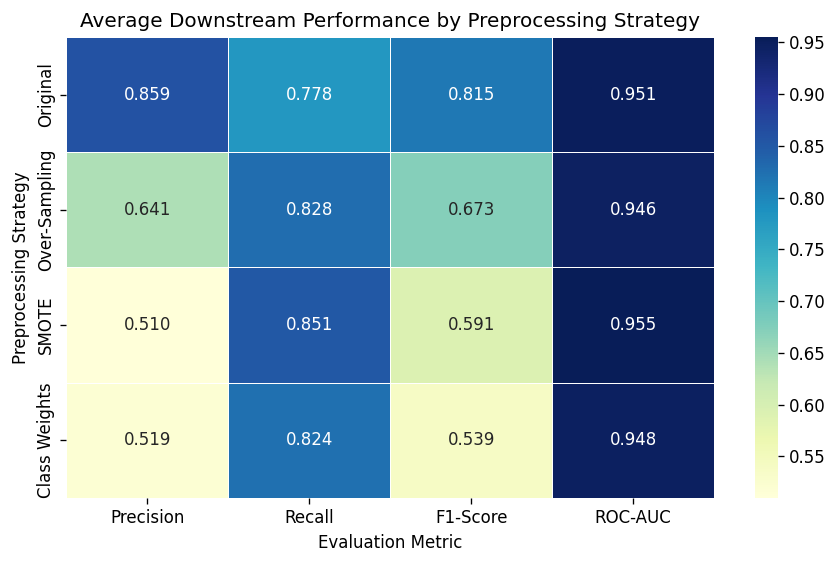

In [53]:
# Keep only rows with valid metric values
preprocessing_impact_df = all_models_df.dropna(
    subset=["Precision", "Recall", "F1-Score", "ROC-AUC"]
).copy()

# Average model performance by preprocessing strategy
strategy_summary = preprocessing_impact_df.groupby("Training Strategy")[
    ["Precision", "Recall", "F1-Score", "ROC-AUC"]
].mean()

# Optional: order the rows nicely
desired_order = ["Original", "Over-Sampling", "SMOTE", "Class Weights"]
strategy_summary = strategy_summary.reindex(
    [s for s in desired_order if s in strategy_summary.index]
)

plt.figure(figsize=(7.5, 4.8), dpi=120)
sns.heatmap(
    strategy_summary,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5
)
plt.title("Average Downstream Performance by Preprocessing Strategy")
plt.xlabel("Evaluation Metric")
plt.ylabel("Preprocessing Strategy")
plt.tight_layout()
plt.show()

## Interpretation of the model-ranking stage

The ranking confirms that the strongest configurations in the initial test-split comparison are mainly **Random Forest** and **XGBoost**, both trained on the **original scaled dataset**.

These two models achieved the strongest overall balance between:

- detecting fraudulent transactions,
- avoiding excessive false positives,
- maintaining high F1-score,
- and preserving a strong ROC-AUC.

Some additional configurations, such as **Random Forest + SMOTE** and **KNN + Original**, also performed well enough to remain interesting. However, they still appeared slightly weaker or less balanced than the strongest original Random Forest and XGBoost configurations.

A practical issue also emerged at this stage: **Random Forest** achieved extremely strong predictive results, but it was noticeably more computationally expensive than **XGBoost**. This trade-off is relevant in a cloud-based setting, where model quality must also be considered alongside runtime and scalability.

For this reason, the next validation stage focuses mainly on the strongest candidates, while also including a small number of additional configurations for confirmation and comparison.

# 6. Cross-Validation

Cross-validation is used to assess whether the strongest models remain stable across multiple data splits.

This is especially important in fraud detection because the minority class is small, and a single train-test split can sometimes produce results that are sensitive to the exact placement of fraudulent observations.

## 6.1 Random Forest + Original Data Under 5-Fold Cross-Validation

Although Random Forest is often considered a relatively stable model, cross-validation is still useful.

The purpose is to check whether performance is consistent across folds and whether the model generalises beyond the initial train-test split.

In [54]:
# RANDOM FOREST+ORIGINAL: #TAKES UP TO 14-15 MINS

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

rf_cv_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_cv_results = cross_validate(
    rf_cv_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    },
    return_train_score=False,
    n_jobs=-1
)

rf_cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Mean CV Score": [
        rf_cv_results["test_accuracy"].mean(),
        rf_cv_results["test_precision"].mean(),
        rf_cv_results["test_recall"].mean(),
        rf_cv_results["test_f1"].mean(),
        rf_cv_results["test_roc_auc"].mean()
    ],
    "Std Dev": [
        rf_cv_results["test_accuracy"].std(),
        rf_cv_results["test_precision"].std(),
        rf_cv_results["test_recall"].std(),
        rf_cv_results["test_f1"].std(),
        rf_cv_results["test_roc_auc"].std()
    ]
})

print("\n--- Random Forest 5-Fold Cross-Validation Results ---\n")
rf_cv_summary


--- Random Forest 5-Fold Cross-Validation Results ---



,Metric,Mean CV Score,Std Dev
0,Accuracy,0.999530,0.000030
1,Precision,0.946530,0.035098
2,Recall,0.774067,0.024954
3,F1-Score,0.850747,0.008723
4,ROC-AUC,0.948841,0.021312


## XGBoost + Original under 5-fold cross-validation

Since **XGBoost trained on the original scaled dataset** was one of the strongest models in the earlier comparison stage, **5-fold cross-validation** is now applied in order to obtain a more robust estimate of its performance.

As with Random Forest, the cross-validation results are not expected to be exactly identical to the earlier **test-split** results.
This is completely normal, because the previous test-set evaluation was based on one specific train-test partition, whereas cross-validation averages the model’s performance across several different folds of the training data.

In this project, **Stratified 5-Fold cross-validation** is used so that the fraud and non-fraud class proportions remain similar in each fold. This is especially important because the dataset is highly imbalanced.

Applying cross-validation to XGBoost is useful for two main reasons:

- it helps confirm whether the model’s strong performance is **stable across different folds**,
- and it keeps the evaluation **consistent with the other shortlisted models**, particularly Random Forest and KNN.

Given that XGBoost already showed a very strong balance between precision, recall, F1-score, and ROC-AUC in the earlier comparison stage, this step is mainly intended to verify its **robustness and reliability** before progressing to formal hyperparameter tuning.

In [55]:
# XGBOOST+ORIGINAL:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

xgb_cv_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb_cv_results = cross_validate(
    xgb_cv_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    },
    return_train_score=False,
    n_jobs=-1
)

xgb_cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Mean CV Score": [
        xgb_cv_results["test_accuracy"].mean(),
        xgb_cv_results["test_precision"].mean(),
        xgb_cv_results["test_recall"].mean(),
        xgb_cv_results["test_f1"].mean(),
        xgb_cv_results["test_roc_auc"].mean()
    ],
    "Std Dev": [
        xgb_cv_results["test_accuracy"].std(),
        xgb_cv_results["test_precision"].std(),
        xgb_cv_results["test_recall"].std(),
        xgb_cv_results["test_f1"].std(),
        xgb_cv_results["test_roc_auc"].std()
    ]
})

print("\n--- XGBoost 5-Fold Cross-Validation Results ---\n")
xgb_cv_summary


--- XGBoost 5-Fold Cross-Validation Results ---



,Metric,Mean CV Score,Std Dev
0,Accuracy,0.999548,0.000041
1,Precision,0.939975,0.040765
2,Recall,0.791918,0.033342
3,F1-Score,0.858261,0.012548
4,ROC-AUC,0.977005,0.013138


## KNN + Original under 5-fold cross-validation

Since **KNN trained on the original scaled dataset** performed well in the earlier comparison stage, **5-fold cross-validation** is now applied in order to check whether its performance remains stable across different folds of the training data.

This is especially relevant for KNN because it is a **distance-based model**, so its results may be sensitive to the particular distribution of the training data. Applying cross-validation helps verify whether the good earlier performance was robust or whether it depended too strongly on one specific train-test split.

As with the other shortlisted models, the results from cross-validation are not expected to be identical to the earlier **test-split** evaluation. This is completely normal, because the previous test-set performance was measured on one specific unseen subset, whereas cross-validation averages the model’s behaviour across several different folds of the training set.

In this project, **Stratified 5-Fold cross-validation** is used so that the fraud and non-fraud class proportions remain similar in each fold. This is important because the dataset is highly imbalanced.

Applying cross-validation to KNN is useful for two reasons:

- it provides a **more robust estimate** of the model’s average performance,
- and it helps determine whether KNN is strong enough to justify progression to the **tuning stage**.

Although KNN was not expected to outperform the strongest tree-based models, its earlier results were good enough to make it a credible additional candidate for this validation stage.

In [56]:
# KNN+ORIGINAL:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

knn_cv_model = KNeighborsClassifier(n_neighbors=5)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

knn_cv_results = cross_validate(
    knn_cv_model,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    },
    return_train_score=False,
    n_jobs=-1
)

knn_cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Mean CV Score": [
        knn_cv_results["test_accuracy"].mean(),
        knn_cv_results["test_precision"].mean(),
        knn_cv_results["test_recall"].mean(),
        knn_cv_results["test_f1"].mean(),
        knn_cv_results["test_roc_auc"].mean()
    ],
    "Std Dev": [
        knn_cv_results["test_accuracy"].std(),
        knn_cv_results["test_precision"].std(),
        knn_cv_results["test_recall"].std(),
        knn_cv_results["test_f1"].std(),
        knn_cv_results["test_roc_auc"].std()
    ]
})

print("\n--- KNN 5-Fold Cross-Validation Results ---\n")
knn_cv_summary


--- KNN 5-Fold Cross-Validation Results ---



,Metric,Mean CV Score,Std Dev
0,Accuracy,0.999478,0.000043
1,Precision,0.932338,0.030281
2,Recall,0.753781,0.023722
3,F1-Score,0.833007,0.014149
4,ROC-AUC,0.919893,0.016915


## Random Forest + SMOTE under cross-validation: avoiding data leakage

A special methodological issue arises when cross-validation is combined with **SMOTE**.

If SMOTE were applied **once to the full training set before cross-validation**, the synthetic samples would already contain information derived from the whole dataset. In that case, some information from what should later act as validation folds could indirectly influence the resampled training data. This would produce **data leakage** and could lead to unrealistically optimistic performance.

For this reason, **Random Forest + SMOTE** is not cross-validated using the previously created `X_train_smote` and `y_train_smote` directly.

Instead, a **pipeline** is used:

1. each fold is split into its own internal training and validation parts,
2. **SMOTE is applied only to the training portion of that fold**,
3. the model is then validated on the untouched validation portion.

This is the correct way to evaluate SMOTE-based models under cross-validation and ensures that the reported results remain methodologically valid.

In [57]:
from imblearn.pipeline import Pipeline  # Approximate runtime in Colab: 25–37 minutes
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

rf_smote_pipeline = Pipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_smote_cv_results = cross_validate(
    rf_smote_pipeline,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    },
    return_train_score=False,
    n_jobs=-1
)

rf_smote_cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Mean CV Score": [
        rf_smote_cv_results["test_accuracy"].mean(),
        rf_smote_cv_results["test_precision"].mean(),
        rf_smote_cv_results["test_recall"].mean(),
        rf_smote_cv_results["test_f1"].mean(),
        rf_smote_cv_results["test_roc_auc"].mean()
    ],
    "Std Dev": [
        rf_smote_cv_results["test_accuracy"].std(),
        rf_smote_cv_results["test_precision"].std(),
        rf_smote_cv_results["test_recall"].std(),
        rf_smote_cv_results["test_f1"].std(),
        rf_smote_cv_results["test_roc_auc"].std()
    ]
})

print("\n--- Random Forest + SMOTE 5-Fold Cross-Validation Results (Corrected) ---\n")
rf_smote_cv_summary


--- Random Forest + SMOTE 5-Fold Cross-Validation Results (Corrected) ---



,Metric,Mean CV Score,Std Dev
0,Accuracy,0.999451,0.000048
1,Precision,0.880987,0.030975
2,Recall,0.791886,0.041239
3,F1-Score,0.832732,0.017432
4,ROC-AUC,0.978415,0.013618


## Extra Experiment: Keras Neural Network + Original under 5-fold cross-validation (threshold = 0.6)

Although the **Keras neural network trained on the original scaled dataset** was not one of the two strongest final candidates, it still produced sufficiently credible earlier results to justify one additional validation step.

For this reason, **Stratified 5-Fold cross-validation** is applied as an **extra experiment**, using the **original scaled training set** and keeping the decision threshold fixed at **0.6**. This threshold was selected because the earlier threshold comparison showed that it provided the **most balanced and most stable overall result** for this neural-network configuration. Compared with the default threshold of **0.5**, it improved **precision** and **F1-score** while keeping **recall** at an acceptable level. Higher thresholds made the model more conservative and caused recall to drop too sharply.

This step is useful for two reasons:

- it checks whether the earlier Keras results remain reasonably consistent across different folds of the training data,
- and it helps confirm whether the neural network could still be a competitive alternative before being fully discarded from the final shortlist.

As with the other models, the cross-validation results are not expected to be identical to the earlier **test-split** results. This is normal, because the previous evaluation was based on one particular split, whereas cross-validation averages performance over several different folds.

In this case, the Keras model is included mainly as a **confirmation experiment** rather than as a principal finalist. The goal is to verify whether the neural network can deliver a stable and competitive balance between fraud detection and false-alarm control when tested more robustly.

In [58]:
# KERAS NEURAL NETWORK + ORIGINAL (5-Fold Cross-Validation)
# Uses the existing build_keras_model(...) function
# Threshold fixed at 0.6

import random
import tensorflow as tf

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tensorflow.keras.callbacks import EarlyStopping

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

keras_cv_results = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": []
}

fold_number = 1

for train_idx, val_idx in cv.split(X_train_scaled, y_train):
    print(f"Running fold {fold_number}/5...")

    X_tr_fold = X_train_scaled[train_idx]
    X_val_fold = X_train_scaled[val_idx]
    y_tr_fold = y_train.iloc[train_idx] if hasattr(y_train, "iloc") else y_train[train_idx]
    y_val_fold = y_train.iloc[val_idx] if hasattr(y_train, "iloc") else y_train[val_idx]

    # Reproducibility
    tf.keras.backend.clear_session()
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    model = build_keras_model(X_tr_fold.shape[1])

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    model.fit(
        X_tr_fold,
        y_tr_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=30,  #We can change the epochs as discussed in class
        batch_size=1024,
        callbacks=[early_stopping],
        verbose=1 # To show epochs
    )

    y_prob_fold = model.predict(X_val_fold, verbose=1).ravel()
    y_pred_fold = (y_prob_fold >= 0.6).astype(int)

    keras_cv_results["accuracy"].append(accuracy_score(y_val_fold, y_pred_fold))
    keras_cv_results["precision"].append(precision_score(y_val_fold, y_pred_fold, zero_division=0))
    keras_cv_results["recall"].append(recall_score(y_val_fold, y_pred_fold, zero_division=0))
    keras_cv_results["f1"].append(f1_score(y_val_fold, y_pred_fold, zero_division=0))
    keras_cv_results["roc_auc"].append(roc_auc_score(y_val_fold, y_prob_fold))

    fold_number += 1

keras_cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Mean CV Score": [
        np.mean(keras_cv_results["accuracy"]),
        np.mean(keras_cv_results["precision"]),
        np.mean(keras_cv_results["recall"]),
        np.mean(keras_cv_results["f1"]),
        np.mean(keras_cv_results["roc_auc"])
    ],
    "Std Dev": [
        np.std(keras_cv_results["accuracy"]),
        np.std(keras_cv_results["precision"]),
        np.std(keras_cv_results["recall"]),
        np.std(keras_cv_results["f1"]),
        np.std(keras_cv_results["roc_auc"])
    ]
})

print("\n--- Keras Neural Network (Original, threshold=0.6) 5-Fold Cross-Validation Results ---\n")
keras_cv_summary

Running fold 1/5...
Epoch 1/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - auc: 0.8235 - loss: 0.1568 - precision: 0.0168 - recall: 0.5759 - val_auc: 0.9441 - val_loss: 0.0133 - val_precision: 0.8507 - val_recall: 0.7308
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - auc: 0.9027 - loss: 0.0115 - precision: 0.6989 - recall: 0.6171 - val_auc: 0.9470 - val_loss: 0.0034 - val_precision: 0.8451 - val_recall: 0.7692
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - auc: 0.9145 - loss: 0.0069 - precision: 0.8008 - recall: 0.6361 - val_auc: 0.9291 - val_loss: 0.0030 - val_precision: 0.8472 - val_recall: 0.7821
Epoch 4/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - auc: 0.9116 - loss: 0.0055 - precision: 0.8560 - recall: 0.6772 - val_auc: 0.9356 - val_loss: 0.0029 - val_precision: 0.8493 - val_recall: 0.7949
Epoch 5/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - auc: 0.9247 - loss: 0.0049 - precision: 0.8699 - recall: 0.6772 - val_auc: 0.9292 - val_loss: 0.0028 - val_precision: 0.8

,Metric,Mean CV Score,Std Dev
0,Accuracy,0.999381,0.000116
1,Precision,0.877922,0.015856
2,Recall,0.746316,0.076032
3,F1-Score,0.804564,0.045632
4,ROC-AUC,0.970333,0.016088


## Interpretation of the Keras 5-fold cross-validation results

The Keras neural network achieved credible cross-validation results, which confirms that it was not a weak model. In particular, it maintained a good overall level of accuracy and a reasonably strong ROC-AUC.

However, compared with the strongest candidates, its **recall** and **F1-score** remained somewhat weaker, and its variability across folds was also slightly higher than that of the top tree-based models. This suggests that, although the model was capable, it was not as robust or as competitive overall as **Random Forest** and **XGBoost**.

For this reason, the Keras model was retained as a useful exploratory comparison model, but not as one of the main final candidates for formal hyperparameter tuning.

## Selecting the final models for hyperparameter tuning

After obtaining the cross-validation results, a filtering and ranking step is used to decide which models should proceed to formal hyperparameter tuning.

This step is useful because not every model that performed reasonably well on the initial test split remained equally strong under cross-validation. In addition, the final stage of tuning is computationally expensive, so it is more methodologically sensible to reserve it for the most credible candidates.

The filtering process combines:

- minimum thresholds for **precision**, **recall**, **F1-score**, and **ROC-AUC**,
- a weighted selection score that slightly prioritises **recall**,
- and a small penalty for instability across folds.

This allows the final selection to reflect not only raw performance, but also model consistency.

In [59]:
# =========================================================
# FILTER K-FOLD RESULTS TO CHOOSE WHICH MODELS TO TUNE
# =========================================================

def summary_to_row(summary_df, model_name):
    s = summary_df.set_index("Metric")
    return {
        "Model": model_name,
        "Accuracy":   s.loc["Accuracy",  "Mean CV Score"],
        "Precision":  s.loc["Precision", "Mean CV Score"],
        "Recall":     s.loc["Recall",    "Mean CV Score"],
        "F1-Score":   s.loc["F1-Score",  "Mean CV Score"],
        "ROC-AUC":    s.loc["ROC-AUC",   "Mean CV Score"],
        "Std_Acc":    s.loc["Accuracy",  "Std Dev"],
        "Std_Prec":   s.loc["Precision", "Std Dev"],
        "Std_Rec":    s.loc["Recall",    "Std Dev"],
        "Std_F1":     s.loc["F1-Score",  "Std Dev"],
        "Std_AUC":    s.loc["ROC-AUC",   "Std Dev"],
    }

# ---------------------------------------------------------
# Add here the CV summaries you already computed
# Comment out any line if that model is not available
# ---------------------------------------------------------
cv_rows = [
    summary_to_row(rf_cv_summary, "Random Forest + Original"),
    summary_to_row(rf_smote_cv_summary, "Random Forest + SMOTE"),
    summary_to_row(xgb_cv_summary, "XGBoost + Original"),
    summary_to_row(knn_cv_summary, "KNN + Original"),
    summary_to_row(keras_cv_summary, "Keras NN + Original (thr=0.6)")
]

cv_models_df = pd.DataFrame(cv_rows)

# ---------------------------------------------------------
# STRICT BUT STILL REASONABLE FILTERS
# These are chosen so that the shortlist stays serious
# while still keeping the strongest candidates
# ---------------------------------------------------------
MIN_PRECISION = 0.88
MIN_RECALL    = 0.77
MIN_F1        = 0.80
MIN_ROC_AUC   = 0.94

cv_models_df["Pass_Filter"] = (
    (cv_models_df["Precision"] >= MIN_PRECISION) &
    (cv_models_df["Recall"]    >= MIN_RECALL) &
    (cv_models_df["F1-Score"]  >= MIN_F1) &
    (cv_models_df["ROC-AUC"]   >= MIN_ROC_AUC)
)

# ---------------------------------------------------------
# Score to rank shortlisted models
# Slightly recall-aware, but still balanced
# ---------------------------------------------------------
cv_models_df["Selection_Score"] = (
    0.35 * cv_models_df["Recall"] +
    0.30 * cv_models_df["Precision"] +
    0.25 * cv_models_df["F1-Score"] +
    0.10 * cv_models_df["ROC-AUC"]
)

# Optional: penalise instability a little
cv_models_df["Stability_Penalty"] = (
    cv_models_df["Std_Prec"] +
    cv_models_df["Std_Rec"] +
    cv_models_df["Std_F1"]
)

cv_models_df["Final_Score"] = (
    cv_models_df["Selection_Score"] - 0.10 * cv_models_df["Stability_Penalty"]
)

# ---------------------------------------------------------
# Rankings
# ---------------------------------------------------------
ranked_cv_df = cv_models_df.sort_values(
    by=["Pass_Filter", "Final_Score", "Recall", "F1-Score"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

shortlisted_cv_df = ranked_cv_df[ranked_cv_df["Pass_Filter"] == True].reset_index(drop=True)

# Final recommendation: top 2 models to tune
if len(shortlisted_cv_df) >= 2:
    recommended_to_tune_df = shortlisted_cv_df.head(2).reset_index(drop=True)
else:
    recommended_to_tune_df = ranked_cv_df.head(2).reset_index(drop=True)

# ---------------------------------------------------------
# Display
# ---------------------------------------------------------
print("=== FILTERS USED ===")
print(f"Precision >= {MIN_PRECISION}")
print(f"Recall    >= {MIN_RECALL}")
print(f"F1-Score  >= {MIN_F1}")
print(f"ROC-AUC   >= {MIN_ROC_AUC}")

print("\n=== ALL K-FOLD MODELS RANKED ===\n")
display(ranked_cv_df[[
    "Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC",
    "Std_Prec", "Std_Rec", "Std_F1", "Pass_Filter", "Final_Score"
]])

print("\n=== SHORTLISTED MODELS (PASSED FILTER) ===\n")
display(shortlisted_cv_df[[
    "Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC",
    "Std_Prec", "Std_Rec", "Std_F1", "Final_Score"
]])

print("\n=== RECOMMENDED MODELS TO TUNE ===\n")
display(recommended_to_tune_df[[
    "Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC",
    "Std_Prec", "Std_Rec", "Std_F1", "Final_Score"
]])

=== FILTERS USED ===
Precision >= 0.88
Recall    >= 0.77
F1-Score  >= 0.8
ROC-AUC   >= 0.94

=== ALL K-FOLD MODELS RANKED ===



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Std_Prec,Std_Rec,Std_F1,Pass_Filter,Final_Score
0,XGBoost + Original,0.999548,0.939975,0.791918,0.858261,0.977005,0.040765,0.033342,0.012548,True,0.862764
1,Random Forest + Original,0.999530,0.946530,0.774067,0.850747,0.948841,0.035098,0.024954,0.008723,True,0.855576
2,Random Forest + SMOTE,0.999451,0.880987,0.791886,0.832732,0.978415,0.030975,0.041239,0.017432,True,0.838516
3,KNN + Original,0.999478,0.932338,0.753781,0.833007,0.919893,0.030281,0.023722,0.014149,False,0.836950
4,Keras NN + Original (thr=0.6),0.999381,0.877922,0.746316,0.804564,0.970333,0.015856,0.076032,0.045632,False,0.809010



=== SHORTLISTED MODELS (PASSED FILTER) ===



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Std_Prec,Std_Rec,Std_F1,Final_Score
0,XGBoost + Original,0.999548,0.939975,0.791918,0.858261,0.977005,0.040765,0.033342,0.012548,0.862764
1,Random Forest + Original,0.999530,0.946530,0.774067,0.850747,0.948841,0.035098,0.024954,0.008723,0.855576
2,Random Forest + SMOTE,0.999451,0.880987,0.791886,0.832732,0.978415,0.030975,0.041239,0.017432,0.838516



=== RECOMMENDED MODELS TO TUNE ===



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Std_Prec,Std_Rec,Std_F1,Final_Score
0,XGBoost + Original,0.999548,0.939975,0.791918,0.858261,0.977005,0.040765,0.033342,0.012548,0.862764
1,Random Forest + Original,0.999530,0.946530,0.774067,0.850747,0.948841,0.035098,0.024954,0.008723,0.855576



At this stage, the strongest models remain **Random Forest + Original** and **XGBoost + Original**. Some additional configurations such as **KNN + Original** and **Random Forest + SMOTE** remain informative, but they are weaker overall and are therefore treated as secondary candidates or extra experiments rather than as the two principal finalists.

# 7. Hyperparameter Tuning

After model ranking and cross-validation, hyperparameter tuning is applied to the strongest shortlisted models.

The aim is to improve final performance while keeping the selection process transparent and computationally reasonable.

# Hyperparameter tuning of XGBoost trained on the original dataset

In [60]:
from xgboost import XGBClassifier  # Approximate runtime in Colab: 8 minutes
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

xgb_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

xgb_base = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

xgb_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=15,
    scoring="f1",
    cv=xgb_cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_random_search.fit(X_train_scaled, y_train)

print("Best XGBoost Parameters:")
print(xgb_random_search.best_params_)
print("\nBest CV F1-score:")
print(xgb_random_search.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best XGBoost Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best CV F1-score:
0.8676030905232139


TEST SET:

In [61]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

best_xgb_random = xgb_random_search.best_estimator_

y_pred_best_xgb_random = best_xgb_random.predict(X_test_scaled)
y_prob_best_xgb_random = best_xgb_random.predict_proba(X_test_scaled)[:, 1]

best_xgb_random_results = pd.DataFrame({
    "Model": ["RandomSearch Tuned XGBoost"],
    "Accuracy": [accuracy_score(y_test, y_pred_best_xgb_random)],
    "Precision": [precision_score(y_test, y_pred_best_xgb_random)],
    "Recall": [recall_score(y_test, y_pred_best_xgb_random)],
    "F1-Score": [f1_score(y_test, y_pred_best_xgb_random)],
    "ROC-AUC": [roc_auc_score(y_test, y_prob_best_xgb_random)]
})

print(classification_report(y_test, y_pred_best_xgb_random))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best_xgb_random))
best_xgb_random_results

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.85      0.88        98

    accuracy                           1.00     56962
   macro avg       0.96      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
 [[56856     8]
 [   15    83]]


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,RandomSearch Tuned XGBoost,0.999596,0.912088,0.846939,0.878307,0.976753



Hyperparameter tuning was applied to **XGBoost trained on the original scaled training set** in two stages.

First, a **RandomizedSearchCV** approach was used. This tested 15 candidate parameter combinations with 5-fold cross-validation, resulting in a total of 75 fits. It identified the following best-performing configuration:

- `subsample = 0.8`
- `n_estimators = 300`
- `min_child_weight = 1`
- `max_depth = 9`
- `learning_rate = 0.1`
- `colsample_bytree = 0.8`

This produced a **best cross-validated F1-score of 0.8676**, while remaining computationally efficient in Colab.

To check whether a more exhaustive search would produce a meaningful improvement, a larger **GridSearchCV** was then applied to the **same original scaled training set**. This tested 144 parameter combinations with 3-fold cross-validation, resulting in a total of 432 fits. The best configuration found was:

- `subsample = 0.9`
- `n_estimators = 300`
- `min_child_weight = 1`
- `max_depth = 11`
- `learning_rate = 0.1`
- `colsample_bytree = 0.8`

However, the larger grid search produced only a **very small improvement** in the best cross-validated F1-score, increasing it from **0.867603** to **0.867671**. This difference is negligible in practical terms, especially when compared with the much higher computational cost of the larger search.

For this reason, the **RandomizedSearchCV-tuned XGBoost trained on the original dataset** was considered the most efficient and sufficiently optimised version. The additional GridSearchCV was still useful, because it confirmed that the earlier random search had already identified a near-optimal region of the hyperparameter space.

# Hyperparameter tuning of Random Forest trained on the original dataset

## Note on the Random Forest Search Space

The Random Forest tuning search space was initially reduced in order to keep the process computationally feasible in Colab. Because Random Forest was noticeably more expensive to train, the search first focused on a smaller set of meaningful parameters, using `max_features = "sqrt"`.

Later, `max_features = "log2"` was also tested to determine whether a broader search would improve performance. However, this increased the size of the search space. Since the tuning procedure used a limited number of random iterations, expanding the search space did not guarantee that the strongest `sqrt` configurations would be sampled again. In other words, the best result found after adding `log2` was only the best among the sampled combinations, not necessarily the best possible Random Forest configuration overall.

When evaluated on the test set, the `log2` version produced slightly higher precision and ROC-AUC, but it also reduced recall and slightly lowered the F1-score. This made the model more conservative, generating fewer false positives while missing more fraudulent transactions.

Because the fraud detection scenario requires a strong balance between identifying fraud and avoiding excessive false alarms, this trade-off was not considered preferable. For this reason, the final Random Forest configuration retained the more efficient and better-balanced `sqrt` setting.

In [62]:
from sklearn.ensemble import RandomForestClassifier # Approximate runtime in Colab: 27 minutes
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

rf_param_dist = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

rf_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=3,
    scoring="f1",
    cv=rf_cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_random_search.fit(X_train_scaled, y_train)

print("Best Random Forest Parameters:")
print(rf_random_search.best_params_)
print("\nBest CV F1-score:")
print(rf_random_search.best_score_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best Random Forest Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}

Best CV F1-score:
0.8460001499475184


TEST SET:

In [63]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
best_rf_random = rf_random_search.best_estimator_

y_pred_best_rf_random = best_rf_random.predict(X_test_scaled)
y_prob_best_rf_random = best_rf_random.predict_proba(X_test_scaled)[:, 1]

best_rf_random_results = pd.DataFrame({
    "Model": ["RandomSearch Tuned Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_best_rf_random)],
    "Precision": [precision_score(y_test, y_pred_best_rf_random)],
    "Recall": [recall_score(y_test, y_pred_best_rf_random)],
    "F1-Score": [f1_score(y_test, y_pred_best_rf_random)],
    "ROC-AUC": [roc_auc_score(y_test, y_prob_best_rf_random)]
})

print(classification_report(y_test, y_pred_best_rf_random))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best_rf_random))
best_rf_random_results

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.93      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
 [[56858     6]
 [   17    81]]


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,RandomSearch Tuned Random Forest,0.999596,0.931034,0.826531,0.875676,0.951746


Hyperparameter tuning was also applied to **Random Forest trained on the original scaled training set** in order to test whether the baseline model could be improved and whether a better balance between fraud detection and false positives could be achieved.

For Random Forest, a **RandomizedSearchCV** approach was selected instead of a large GridSearchCV. This decision was made because Random Forest was noticeably more computationally expensive on this dataset in Colab, especially when compared with XGBoost. A reduced search space was therefore used in order to keep the tuning process computationally feasible while still exploring meaningful parameter combinations.

The tuning procedure was applied to the **same original scaled training set**, without resampling, and tested a smaller number of candidate configurations through cross-validation. It identified the following best-performing parameter combination:

- `n_estimators = 100`
- `max_depth = 10`
- `min_samples_split = 2`
- `min_samples_leaf = 1`
- `max_features = "sqrt"`

When evaluated on the test set, the tuned **Random Forest trained on the original dataset** produced only a **very small practical change** compared with the baseline version. Recall and F1-score improved slightly, meaning that the tuned model detected marginally more fraud cases. However, precision and ROC-AUC decreased slightly, and the confusion matrix changed only minimally.

This suggests that hyperparameter tuning made the Random Forest model slightly more sensitive to fraud, but did not produce a major overall improvement. In practical terms, the baseline Random Forest trained on the original scaled dataset was already performing at a very high level.

For this reason, the tuning of **Random Forest on the original dataset** was still considered useful and valid, but it also showed that further large-scale tuning would probably not be proportionate to the additional computational cost. The tuned Random Forest was therefore retained as a strong final candidate, although XGBoost ultimately remained the stronger overall model after tuning.

# 7.4 Additional Tuning Experiments

After the two principal finalists had been identified as **Random Forest trained on the original scaled dataset** and **XGBoost trained on the original scaled dataset**, two additional tuning experiments were carried out.

These extra experiments were not expected to outperform the main finalists from the start. Instead, they were used as a final methodological check to test whether secondary candidates could still improve enough under tuning to challenge the strongest models.

The additional configurations were:

- **Random Forest + SMOTE**
- **KNN trained on the original scaled dataset**

These experiments were useful because Random Forest + SMOTE had shown promising recall-related behaviour earlier, while KNN had performed better than expected in earlier comparison stages.

## 7.5 Hyperparameter Tuning of Random Forest with SMOTE

Random Forest was also tuned using **SMOTE** to test whether a resampled training strategy could improve fraud detection compared with the original Random Forest configuration.

SMOTE was included inside a pipeline so that resampling was applied separately within each cross-validation fold. This avoids data leakage. The tuning process used **RandomizedSearchCV** and was computationally expensive.

When evaluated on the test set, the tuned **Random Forest + SMOTE** model produced the following results:

- **Accuracy:** 0.999438
- **Precision:** 0.866667
- **Recall:** 0.795918
- **F1-score:** 0.829787
- **ROC-AUC:** 0.955123

The confusion matrix was:

- **TN = 56852**
- **FP = 12**
- **FN = 20**
- **TP = 78**

These results show that the tuned SMOTE version did **not** outperform the strongest final candidates. Compared with the tuned Random Forest trained on the original dataset, it produced lower precision, lower recall, lower F1-score, more false positives and more false negatives.

## Hyperparameter tuning of KNN trained on the original dataset

KNN trained on the **original scaled training set** was also tuned in order to test whether its baseline configuration could be improved and whether a better balance between fraud detection and false positives could be achieved.

The tuning process was carried out with **RandomizedSearchCV** using cross-validation. Although the search space was not extremely large, the tuning remained computationally expensive for this dataset and took approximately **1 hour and 30 minutes** in Colab.

The best parameter combination found was:

- `weights = "uniform"`
- `p = 1`
- `n_neighbors = 3`
- `leaf_size = 20`

This produced a **best cross-validated F1-score of 0.8371**.

When evaluated on the test set, the tuned **KNN trained on the original dataset** produced the following results:

- **Accuracy:** 0.999561
- **Precision:** 0.929412
- **Recall:** 0.806122
- **F1-score:** 0.863388
- **ROC-AUC:** 0.933585

The confusion matrix was:

- **TN = 56858**
- **FP = 6**
- **FN = 19**
- **TP = 79**

Compared with the **original KNN baseline**, the tuned version produced only a **small practical improvement**. Precision and F1-score increased slightly, while recall remained unchanged. In practical terms, the tuned model generated one fewer false positive, but it did not detect any additional fraud cases.

These results show that tuning KNN was methodologically useful, but it did **not** produce a major enough improvement to challenge the strongest final candidates. In particular, the tuned KNN still remained below the tuned **Random Forest** and tuned **XGBoost** models in terms of overall balance, especially in recall, F1-score, and ROC-AUC.

For this reason, although the tuned KNN performed well and remained a credible comparison model, it was not retained as one of the two final selected models. The high computational cost was also not fully justified by the relatively small improvement obtained.

## Final interpretation of the tuning stage

The tuning stage confirmed that the two strongest final models were **XGBoost trained on the original scaled dataset** and **Random Forest trained on the original scaled dataset**.

For **XGBoost**, tuning produced a clearly strong final model and remained computationally efficient. A later, larger GridSearchCV was also tested, but it produced only a negligible improvement compared with the earlier RandomizedSearchCV while requiring substantially more computation. This supported the conclusion that the random search had already identified a near-optimal region of the parameter space.

For **Random Forest**, tuning was still useful and valid, but the improvement over the baseline version was only very small in practical terms. The tuned model became slightly more sensitive to fraud, but the change in overall performance remained limited. In addition, Random Forest remained more computationally expensive than XGBoost.

Extra tuning experiments on **Random Forest + SMOTE** and **KNN + Original** were methodologically informative, but neither configuration improved enough to challenge the two strongest finalists.

Overall, the tuning stage reinforced the same conclusion already suggested by the previous comparison and cross-validation stages: the best final candidates in this project are **XGBoost + Original** and **Random Forest + Original**.

## 7.7 Threshold-Tuning Experiment

A supplementary threshold-tuning experiment was carried out for Random Forest and XGBoost using a validation split from the training data.

This is relevant because fraud detection often requires a trade-off between precision and recall. However, the final threshold must be selected carefully to avoid overfitting the validation set.


--- Random Forest threshold tuning on validation set ---



,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,TN,FP,FN,TP
0,Random Forest,0.10,0.999342,0.802469,0.822785,0.812500,0.93386,45474,16,14,65
1,Random Forest,0.15,0.999342,0.810127,0.810127,0.810127,0.93386,45475,15,15,64
2,Random Forest,0.20,0.999386,0.831169,0.810127,0.820513,0.93386,45477,13,15,64
3,Random Forest,0.25,0.999364,0.837838,0.784810,0.810458,0.93386,45478,12,17,62
4,Random Forest,0.30,0.999386,0.849315,0.784810,0.815789,0.93386,45479,11,17,62
5,Random Forest,0.35,0.999451,0.897059,0.772152,0.829932,0.93386,45483,7,18,61
6,Random Forest,0.40,0.999451,0.921875,0.746835,0.825175,0.93386,45485,5,20,59
7,Random Forest,0.45,0.999451,0.921875,0.746835,0.825175,0.93386,45485,5,20,59
8,Random Forest,0.50,0.999429,0.934426,0.721519,0.814286,0.93386,45486,4,22,57
9,Random Forest,0.55,0.999407,0.933333,0.708861,0.805755,0.93386,45486,4,23,56



--- XGBoost threshold tuning on validation set ---



,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,TN,FP,FN,TP
0,XGBoost,0.10,0.999407,0.851351,0.797468,0.823529,0.970542,45479,11,16,63
1,XGBoost,0.15,0.999451,0.875000,0.797468,0.834437,0.970542,45481,9,16,63
2,XGBoost,0.20,0.999495,0.900000,0.797468,0.845638,0.970542,45483,7,16,63
3,XGBoost,0.25,0.999495,0.911765,0.784810,0.843537,0.970542,45484,6,17,62
4,XGBoost,0.30,0.999539,0.939394,0.784810,0.855172,0.970542,45486,4,17,62
5,XGBoost,0.35,0.999539,0.939394,0.784810,0.855172,0.970542,45486,4,17,62
6,XGBoost,0.40,0.999517,0.938462,0.772152,0.847222,0.970542,45486,4,18,61
7,XGBoost,0.45,0.999517,0.938462,0.772152,0.847222,0.970542,45486,4,18,61
8,XGBoost,0.50,0.999517,0.938462,0.772152,0.847222,0.970542,45486,4,18,61
9,XGBoost,0.55,0.999495,0.951613,0.746835,0.836879,0.970542,45487,3,20,59


Best RF threshold on validation (by F1):  0.35
Best XGB threshold on validation (by F1): 0.3

--- Test-set comparison: validation-best threshold vs retained 0.5 ---



,Model,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,TN,FP,FN,TP
0,Random Forest,Validation-best,0.35,0.999544,0.875000,0.857143,0.865979,0.951746,56852,12,14,84
1,Random Forest,Retained final (0.5),0.50,0.999596,0.931034,0.826531,0.875676,0.951746,56858,6,17,81
2,XGBoost,Validation-best,0.30,0.999526,0.873684,0.846939,0.860104,0.976753,56852,12,15,83
3,XGBoost,Retained final (0.5),0.50,0.999596,0.912088,0.846939,0.878307,0.976753,56856,8,15,83



--- Final threshold decision ---



,Model,Best threshold on validation,Final retained threshold,Reason
0,Random Forest,0.35,0.5,0.5 retained because the lower threshold did n...
1,XGBoost,0.30,0.5,0.5 retained because the lower threshold did n...


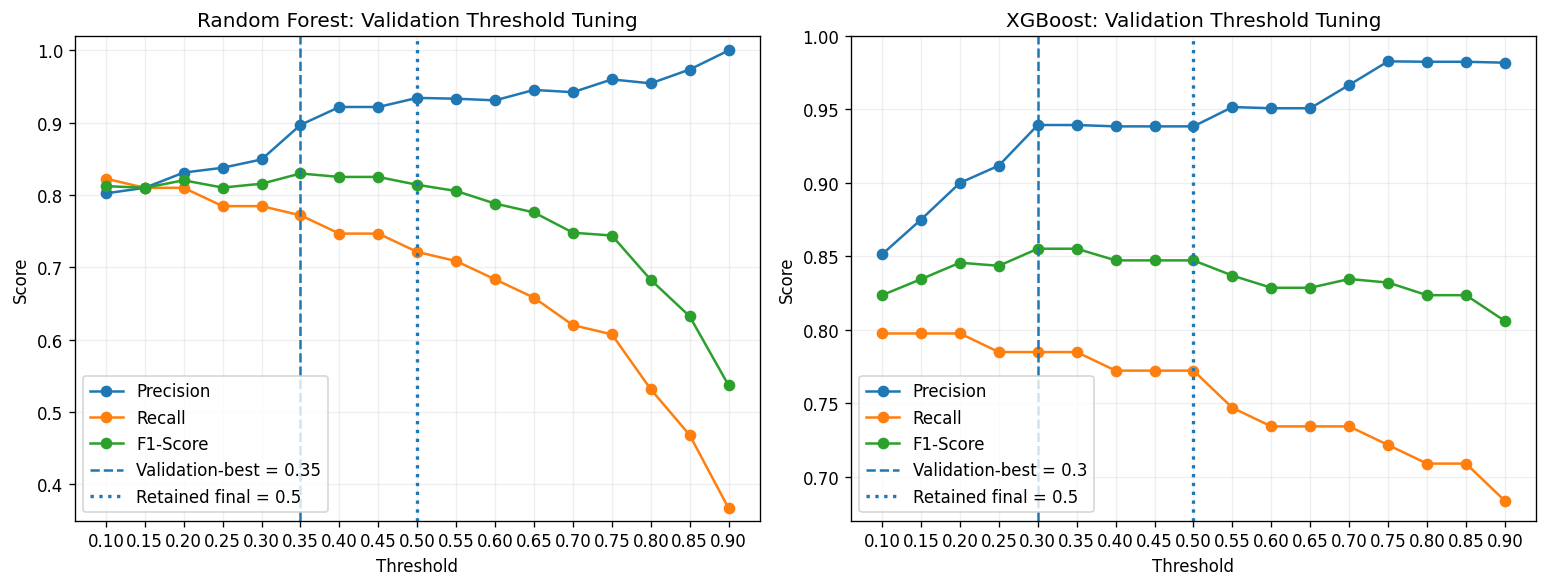

In [64]:
# =========================================================
# THRESHOLD TUNING FOR RANDOM FOREST AND XGBOOST
# Clear version:
# 1) choose best threshold on validation
# 2) compare against default 0.5 on test
# 3) retain 0.5 if it generalises better / more defensibly
# =========================================================

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# ---------------------------------------------------------
# 1. Validation split from the original scaled training set
# ---------------------------------------------------------
X_tr_inner, X_val, y_tr_inner, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE
)

# ---------------------------------------------------------
# 2. Use tuned models if available; otherwise use strong defaults
# ---------------------------------------------------------
if "best_rf_random" in globals():
    rf_base = clone(best_rf_random)
else:
    from sklearn.ensemble import RandomForestClassifier
    rf_base = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

if "best_xgb_random" in globals():
    xgb_base = clone(best_xgb_random)
else:
    from xgboost import XGBClassifier
    xgb_base = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )

# ---------------------------------------------------------
# 3. Fit on inner train
# ---------------------------------------------------------
rf_base.fit(X_tr_inner, y_tr_inner)
xgb_base.fit(X_tr_inner, y_tr_inner)

# Validation probabilities
y_val_prob_rf = rf_base.predict_proba(X_val)[:, 1]
y_val_prob_xgb = xgb_base.predict_proba(X_val)[:, 1]

# ---------------------------------------------------------
# 4. Threshold grid
# ---------------------------------------------------------
thresholds = np.arange(0.10, 0.91, 0.05)

def evaluate_thresholds(y_true, y_prob, thresholds, model_name):
    rows = []
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()

        rows.append({
            "Model": model_name,
            "Threshold": round(float(t), 2),
            "Accuracy": accuracy_score(y_true, y_pred_t),
            "Precision": precision_score(y_true, y_pred_t, zero_division=0),
            "Recall": recall_score(y_true, y_pred_t, zero_division=0),
            "F1-Score": f1_score(y_true, y_pred_t, zero_division=0),
            "ROC-AUC": roc_auc_score(y_true, y_prob),   # threshold-independent
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        })
    return pd.DataFrame(rows)

rf_threshold_df = evaluate_thresholds(y_val, y_val_prob_rf, thresholds, "Random Forest")
xgb_threshold_df = evaluate_thresholds(y_val, y_val_prob_xgb, thresholds, "XGBoost")

print("\n--- Random Forest threshold tuning on validation set ---\n")
display(rf_threshold_df)

print("\n--- XGBoost threshold tuning on validation set ---\n")
display(xgb_threshold_df)

# ---------------------------------------------------------
# 5. Pick best threshold on validation by F1-score
# ---------------------------------------------------------
best_rf_threshold = rf_threshold_df.sort_values(
    by=["F1-Score", "Recall", "Precision"],
    ascending=[False, False, False]
).iloc[0]["Threshold"]

best_xgb_threshold = xgb_threshold_df.sort_values(
    by=["F1-Score", "Recall", "Precision"],
    ascending=[False, False, False]
).iloc[0]["Threshold"]

print(f"Best RF threshold on validation (by F1):  {best_rf_threshold}")
print(f"Best XGB threshold on validation (by F1): {best_xgb_threshold}")

# ---------------------------------------------------------
# 6. Final retained thresholds for the project
#    We keep 0.5 unless the lower threshold clearly generalises better
# ---------------------------------------------------------
final_rf_threshold = 0.50
final_xgb_threshold = 0.50

# ---------------------------------------------------------
# 7. Refit on full original scaled training set
# ---------------------------------------------------------
rf_final_model = clone(rf_base)
xgb_final_model = clone(xgb_base)

rf_final_model.fit(X_train_scaled, y_train)
xgb_final_model.fit(X_train_scaled, y_train)

# Test probabilities
y_test_prob_rf = rf_final_model.predict_proba(X_test_scaled)[:, 1]
y_test_prob_xgb = xgb_final_model.predict_proba(X_test_scaled)[:, 1]

# ---------------------------------------------------------
# 8. Compare validation-best threshold vs retained 0.5 on test set
# ---------------------------------------------------------
def evaluate_on_test(y_true, y_prob, threshold, model_name, threshold_type):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "Model": model_name,
        "Threshold_Type": threshold_type,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

threshold_test_comparison_df = pd.DataFrame([
    evaluate_on_test(y_test, y_test_prob_rf, best_rf_threshold, "Random Forest", "Validation-best"),
    evaluate_on_test(y_test, y_test_prob_rf, final_rf_threshold, "Random Forest", "Retained final (0.5)"),
    evaluate_on_test(y_test, y_test_prob_xgb, best_xgb_threshold, "XGBoost", "Validation-best"),
    evaluate_on_test(y_test, y_test_prob_xgb, final_xgb_threshold, "XGBoost", "Retained final (0.5)")
])

print("\n--- Test-set comparison: validation-best threshold vs retained 0.5 ---\n")
display(threshold_test_comparison_df)

# ---------------------------------------------------------
# 9. Compact final decision table
# ---------------------------------------------------------
final_threshold_decision_df = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Best threshold on validation": best_rf_threshold,
        "Final retained threshold": final_rf_threshold,
        "Reason": "0.5 retained because the lower threshold did not generalise more convincingly to the test set"
    },
    {
        "Model": "XGBoost",
        "Best threshold on validation": best_xgb_threshold,
        "Final retained threshold": final_xgb_threshold,
        "Reason": "0.5 retained because the lower threshold did not generalise more convincingly to the test set"
    }
])

print("\n--- Final threshold decision ---\n")
display(final_threshold_decision_df)

# ---------------------------------------------------------
# 10. Plots
#     Dashed line = best threshold on validation
#     Dotted line = final retained threshold (0.5)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=120)

# Random Forest
axes[0].plot(rf_threshold_df["Threshold"], rf_threshold_df["Precision"], marker="o", label="Precision")
axes[0].plot(rf_threshold_df["Threshold"], rf_threshold_df["Recall"], marker="o", label="Recall")
axes[0].plot(rf_threshold_df["Threshold"], rf_threshold_df["F1-Score"], marker="o", label="F1-Score")
axes[0].axvline(best_rf_threshold, linestyle="--", label=f"Validation-best = {best_rf_threshold}")
axes[0].axvline(final_rf_threshold, linestyle=":", linewidth=2, label=f"Retained final = {final_rf_threshold}")
axes[0].set_title("Random Forest: Validation Threshold Tuning")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_xticks(rf_threshold_df["Threshold"])
axes[0].set_ylim(0.35, 1.02)
axes[0].grid(alpha=0.2)
axes[0].legend()

# XGBoost
axes[1].plot(xgb_threshold_df["Threshold"], xgb_threshold_df["Precision"], marker="o", label="Precision")
axes[1].plot(xgb_threshold_df["Threshold"], xgb_threshold_df["Recall"], marker="o", label="Recall")
axes[1].plot(xgb_threshold_df["Threshold"], xgb_threshold_df["F1-Score"], marker="o", label="F1-Score")
axes[1].axvline(best_xgb_threshold, linestyle="--", label=f"Validation-best = {best_xgb_threshold}")
axes[1].axvline(final_xgb_threshold, linestyle=":", linewidth=2, label=f"Retained final = {final_xgb_threshold}")
axes[1].set_title("XGBoost: Validation Threshold Tuning")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].set_xticks(xgb_threshold_df["Threshold"])
axes[1].set_ylim(0.67, 1.00)
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()

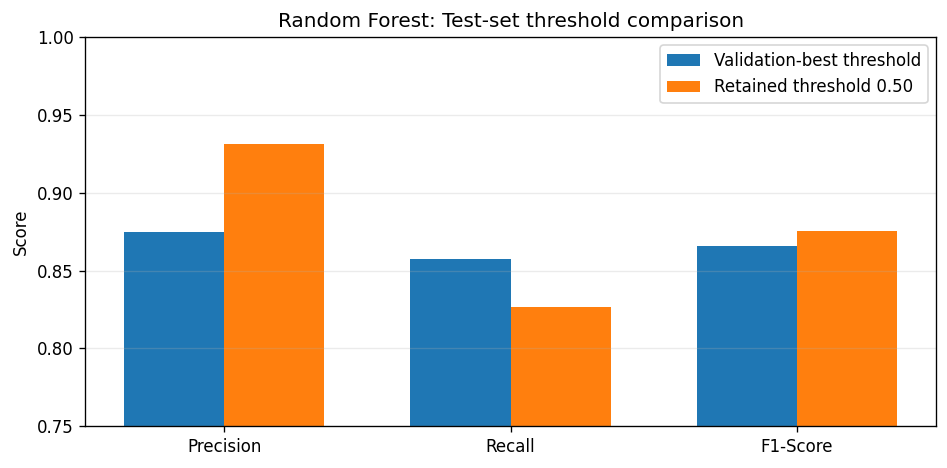

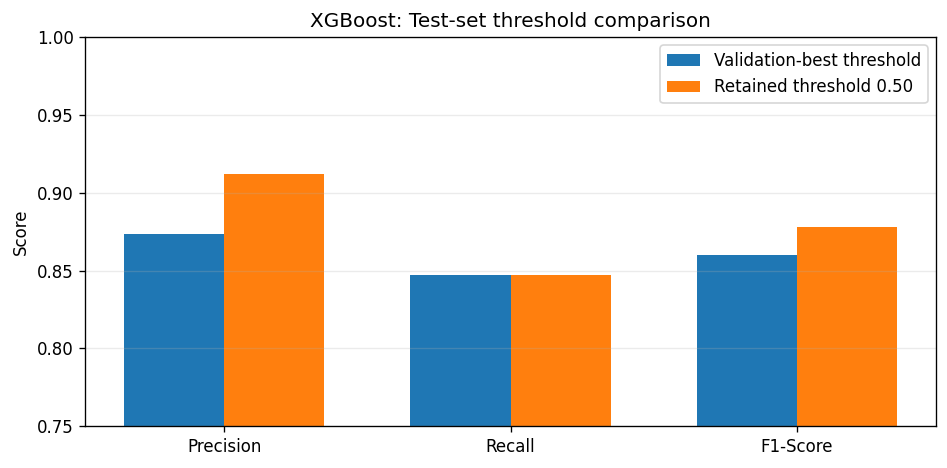

In [65]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = threshold_test_comparison_df.copy()
metrics = ["Precision", "Recall", "F1-Score"]

for model in plot_df["Model"].unique():
    model_df = plot_df[plot_df["Model"] == model]

    x = np.arange(len(metrics))
    width = 0.35

    validation_best_values = model_df[
        model_df["Threshold_Type"] == "Validation-best"
    ][metrics].iloc[0].values

    retained_values = model_df[
        model_df["Threshold_Type"] == "Retained final (0.5)"
    ][metrics].iloc[0].values

    fig, ax = plt.subplots(figsize=(8, 4), dpi=120)

    ax.bar(
        x - width / 2,
        validation_best_values,
        width,
        label="Validation-best threshold"
    )

    ax.bar(
        x + width / 2,
        retained_values,
        width,
        label="Retained threshold 0.50"
    )

    ax.set_title(f"{model}: Test-set threshold comparison")
    ax.set_ylabel("Score")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0.75, 1.0)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

    plt.tight_layout()
    plt.show()

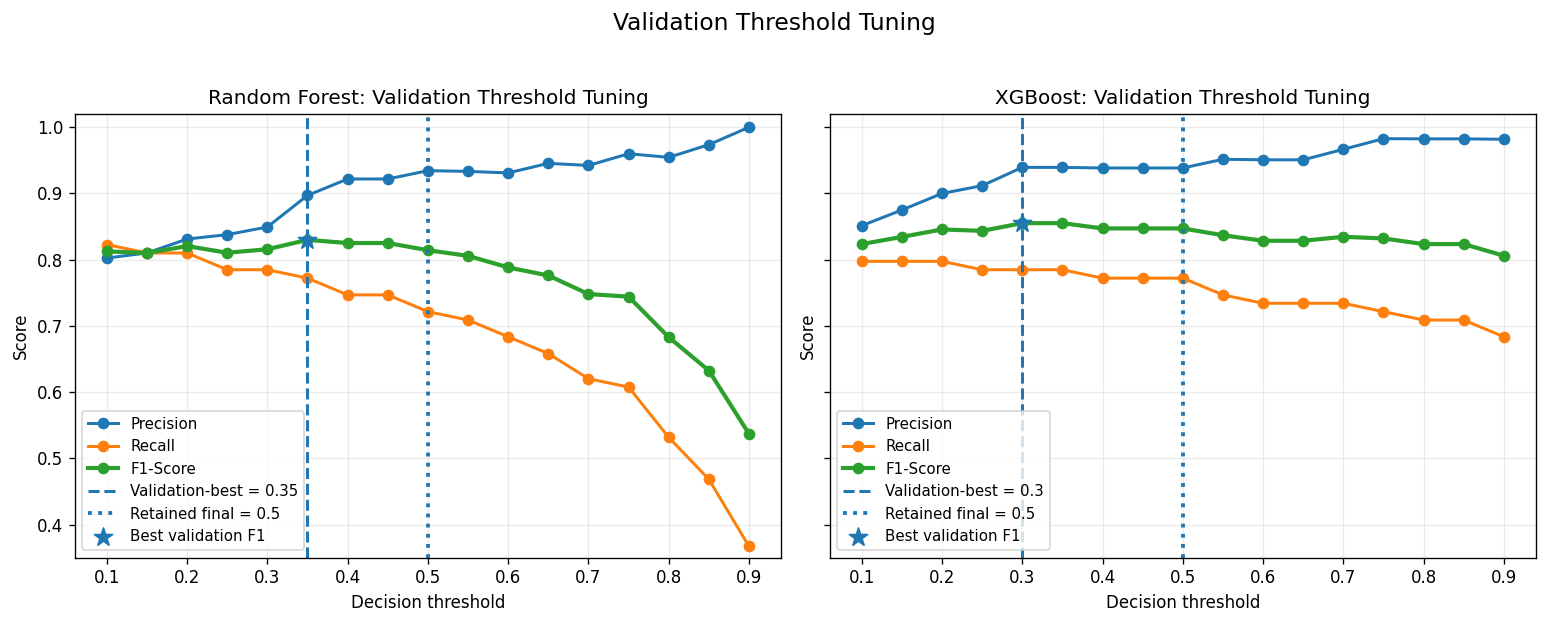

In [66]:
# =========================================================
# VALIDATION THRESHOLD TUNING PLOT
# Shows how Precision, Recall and F1 change across thresholds
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=120, sharey=True)

def plot_validation_thresholds(ax, df, best_threshold, final_threshold, title):
    ax.plot(
        df["Threshold"],
        df["Precision"],
        marker="o",
        linewidth=1.8,
        label="Precision"
    )

    ax.plot(
        df["Threshold"],
        df["Recall"],
        marker="o",
        linewidth=1.8,
        label="Recall"
    )

    ax.plot(
        df["Threshold"],
        df["F1-Score"],
        marker="o",
        linewidth=2.5,
        label="F1-Score"
    )

    # Validation-best threshold
    ax.axvline(
        best_threshold,
        linestyle="--",
        linewidth=1.8,
        label=f"Validation-best = {best_threshold}"
    )

    # Final retained threshold
    ax.axvline(
        final_threshold,
        linestyle=":",
        linewidth=2.3,
        label=f"Retained final = {final_threshold}"
    )

    # Highlight best validation F1 point
    best_row = df[df["Threshold"] == best_threshold].iloc[0]

    ax.scatter(
        best_row["Threshold"],
        best_row["F1-Score"],
        s=130,
        marker="*",
        zorder=5,
        label="Best validation F1"
    )

    ax.set_title(title)
    ax.set_xlabel("Decision threshold")
    ax.set_ylabel("Score")
    ax.set_xticks(np.arange(0.10, 0.91, 0.10))
    ax.set_ylim(0.35, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9, loc="lower left")


plot_validation_thresholds(
    axes[0],
    rf_threshold_df,
    best_rf_threshold,
    final_rf_threshold,
    "Random Forest: Validation Threshold Tuning"
)

plot_validation_thresholds(
    axes[1],
    xgb_threshold_df,
    best_xgb_threshold,
    final_xgb_threshold,
    "XGBoost: Validation Threshold Tuning"
)

fig.suptitle("Validation Threshold Tuning", fontsize=14, y=1.03)

plt.tight_layout()

# Optional: save for report
plt.savefig("validation_threshold_tuning.png", dpi=300, bbox_inches="tight")

plt.show()


Random Forest test values at selected thresholds:


,Threshold,Precision,Recall,F1-Score,TN,FP,FN,TP
5,0.35,0.875000,0.857143,0.865979,56852,12,14,84
8,0.50,0.931034,0.826531,0.875676,56858,6,17,81



XGBoost test values at selected thresholds:


,Threshold,Precision,Recall,F1-Score,TN,FP,FN,TP
4,0.3,0.873684,0.846939,0.860104,56852,12,15,83
8,0.5,0.912088,0.846939,0.878307,56856,8,15,83


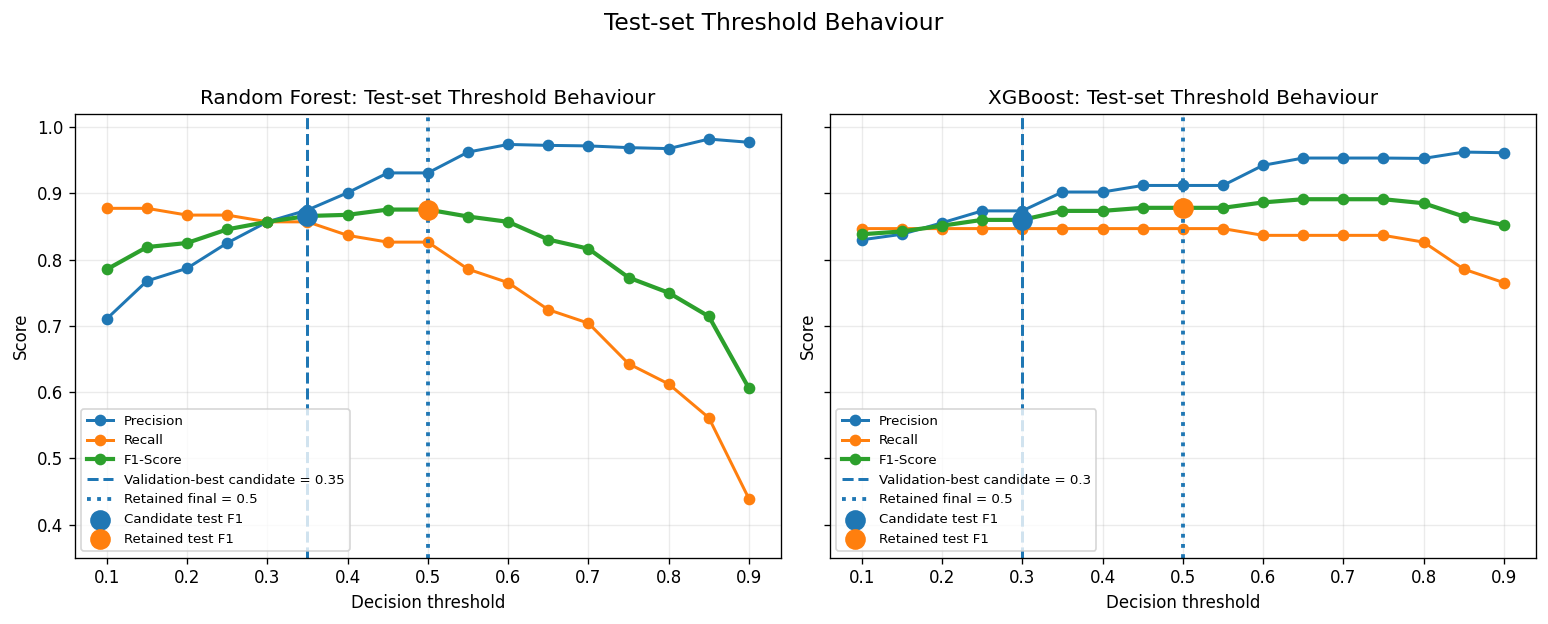

In [67]:
# =========================================================
# TEST-SET THRESHOLD CURVES
# Same style as the validation plot, but using TEST data.
# This will match the test comparison table.
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Important: round thresholds to avoid float comparison issues
thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)

def evaluate_thresholds_on_test(y_true, y_prob, thresholds, model_name):
    rows = []

    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()

        rows.append({
            "Model": model_name,
            "Threshold": round(float(t), 2),
            "Accuracy": accuracy_score(y_true, y_pred_t),
            "Precision": precision_score(y_true, y_pred_t, zero_division=0),
            "Recall": recall_score(y_true, y_pred_t, zero_division=0),
            "F1-Score": f1_score(y_true, y_pred_t, zero_division=0),
            "ROC-AUC": roc_auc_score(y_true, y_prob),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        })

    return pd.DataFrame(rows)


# These use the SAME test probabilities used in your test comparison table
rf_test_threshold_df = evaluate_thresholds_on_test(
    y_test,
    y_test_prob_rf,
    thresholds,
    "Random Forest"
)

xgb_test_threshold_df = evaluate_thresholds_on_test(
    y_test,
    y_test_prob_xgb,
    thresholds,
    "XGBoost"
)


# Check values that should match your test table
print("\nRandom Forest test values at selected thresholds:")
display(
    rf_test_threshold_df[
        rf_test_threshold_df["Threshold"].isin([best_rf_threshold, final_rf_threshold])
    ][["Threshold", "Precision", "Recall", "F1-Score", "TN", "FP", "FN", "TP"]]
)

print("\nXGBoost test values at selected thresholds:")
display(
    xgb_test_threshold_df[
        xgb_test_threshold_df["Threshold"].isin([best_xgb_threshold, final_xgb_threshold])
    ][["Threshold", "Precision", "Recall", "F1-Score", "TN", "FP", "FN", "TP"]]
)


# =========================================================
# Plot: same style as before, but TEST-SET performance
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=120, sharey=True)

def plot_test_threshold_curve(ax, df, candidate_threshold, final_threshold, title):
    ax.plot(
        df["Threshold"],
        df["Precision"],
        marker="o",
        linewidth=1.8,
        label="Precision"
    )

    ax.plot(
        df["Threshold"],
        df["Recall"],
        marker="o",
        linewidth=1.8,
        label="Recall"
    )

    ax.plot(
        df["Threshold"],
        df["F1-Score"],
        marker="o",
        linewidth=2.5,
        label="F1-Score"
    )

    # Candidate threshold selected from validation
    ax.axvline(
        candidate_threshold,
        linestyle="--",
        linewidth=1.8,
        label=f"Validation-best candidate = {candidate_threshold}"
    )

    # Final retained threshold
    ax.axvline(
        final_threshold,
        linestyle=":",
        linewidth=2.3,
        label=f"Retained final = {final_threshold}"
    )

    # Highlight F1 at validation-best candidate
    candidate_row = df[df["Threshold"] == candidate_threshold].iloc[0]
    ax.scatter(
        candidate_row["Threshold"],
        candidate_row["F1-Score"],
        s=130,
        marker="o",
        zorder=5,
        label="Candidate test F1"
    )

    # Highlight F1 at retained 0.50
    final_row = df[df["Threshold"] == final_threshold].iloc[0]
    ax.scatter(
        final_row["Threshold"],
        final_row["F1-Score"],
        s=130,
        marker="o",
        zorder=5,
        label="Retained test F1"
    )

    ax.set_title(title)
    ax.set_xlabel("Decision threshold")
    ax.set_ylabel("Score")
    ax.set_xticks(np.arange(0.10, 0.91, 0.10))
    ax.set_ylim(0.35, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="lower left")


plot_test_threshold_curve(
    axes[0],
    rf_test_threshold_df,
    best_rf_threshold,
    final_rf_threshold,
    "Random Forest: Test-set Threshold Behaviour"
)

plot_test_threshold_curve(
    axes[1],
    xgb_test_threshold_df,
    best_xgb_threshold,
    final_xgb_threshold,
    "XGBoost: Test-set Threshold Behaviour"
)

fig.suptitle("Test-set Threshold Behaviour", fontsize=14, y=1.03)

plt.tight_layout()

plt.savefig("test_threshold_behaviour.png", dpi=300, bbox_inches="tight")

plt.show()

,Model,Threshold,Precision,Recall,F1-Score
0,Random Forest,Retained 0.50,0.9310,0.8265,0.8757
1,Random Forest,Validation-best 0.35,0.8750,0.8571,0.8660
2,XGBoost,Retained 0.50,0.9121,0.8469,0.8783
3,XGBoost,Validation-best 0.3,0.8737,0.8469,0.8601


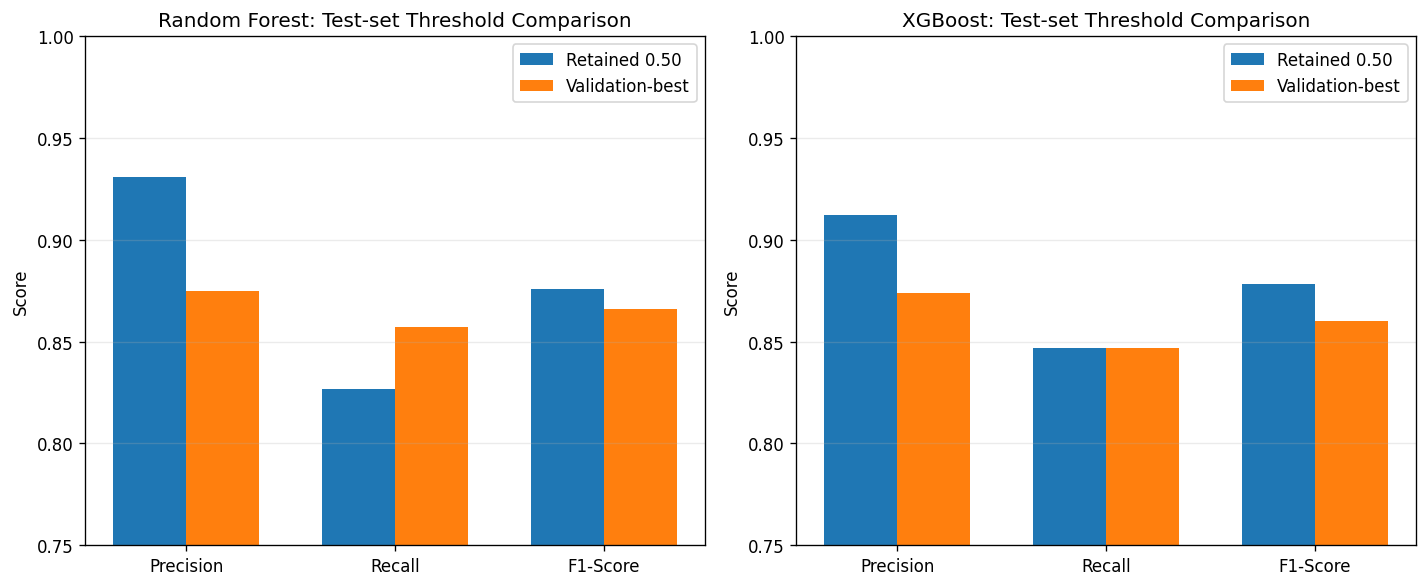

In [68]:
# =========================================================
# TEST-SET THRESHOLD COMPARISON PLOT
# Compare retained 0.5 vs validation-best threshold
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# --- Build comparison table on TEST set ---
rows = []

# Random Forest
for thr, thr_name in [(0.50, "Retained 0.50"), (best_rf_threshold, f"Validation-best {best_rf_threshold}")]:
    y_pred = (y_test_prob_rf >= thr).astype(int)
    rows.append({
        "Model": "Random Forest",
        "Threshold": thr_name,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0)
    })

# XGBoost
for thr, thr_name in [(0.50, "Retained 0.50"), (best_xgb_threshold, f"Validation-best {best_xgb_threshold}")]:
    y_pred = (y_test_prob_xgb >= thr).astype(int)
    rows.append({
        "Model": "XGBoost",
        "Threshold": thr_name,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0)
    })

threshold_compare_test_df = pd.DataFrame(rows)
display(threshold_compare_test_df.round(4))

# ---------------------------------------------------------
# Plot: one chart per model
# ---------------------------------------------------------
metrics = ["Precision", "Recall", "F1-Score"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

for ax, model_name in zip(axes, ["Random Forest", "XGBoost"]):
    df_model = threshold_compare_test_df[threshold_compare_test_df["Model"] == model_name].copy()

    x = range(len(metrics))
    width = 0.35

    vals_05 = df_model[df_model["Threshold"].str.contains("0.50")][metrics].values[0]
    vals_best = df_model[~df_model["Threshold"].str.contains("0.50")][metrics].values[0]

    ax.bar([i - width/2 for i in x], vals_05, width, label="Retained 0.50")
    ax.bar([i + width/2 for i in x], vals_best, width, label="Validation-best")

    ax.set_xticks(list(x))
    ax.set_xticklabels(metrics)
    ax.set_ylim(0.75, 1.00)   # zoom a bit so differences are visible
    ax.set_title(f"{model_name}: Test-set Threshold Comparison")
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()

In [69]:
# =========================================================
# VALIDATION THRESHOLD TUNING
# Plot and table use the SAME validation data,
# so the values match exactly.
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# ---------------------------------------------------------
# 1. Threshold grid
# ---------------------------------------------------------
thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)


# ---------------------------------------------------------
# 2. Function to evaluate thresholds
# ---------------------------------------------------------
def evaluate_thresholds(y_true, y_prob, thresholds, model_name):
    rows = []

    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()

        rows.append({
            "Model": model_name,
            "Threshold": round(float(t), 2),
            "Accuracy": accuracy_score(y_true, y_pred_t),
            "Precision": precision_score(y_true, y_pred_t, zero_division=0),
            "Recall": recall_score(y_true, y_pred_t, zero_division=0),
            "F1-Score": f1_score(y_true, y_pred_t, zero_division=0),
            "ROC-AUC": roc_auc_score(y_true, y_prob),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        })

    return pd.DataFrame(rows)


# ---------------------------------------------------------
# 3. Evaluate validation thresholds
# These are the data that will be plotted
# ---------------------------------------------------------
rf_validation_threshold_df = evaluate_thresholds(
    y_val,
    y_val_prob_rf,
    thresholds,
    "Random Forest"
)

xgb_validation_threshold_df = evaluate_thresholds(
    y_val,
    y_val_prob_xgb,
    thresholds,
    "XGBoost"
)


# ---------------------------------------------------------
# 4. Select validation-best thresholds by F1-score
# ---------------------------------------------------------
best_rf_threshold = rf_validation_threshold_df.sort_values(
    by=["F1-Score", "Recall", "Precision"],
    ascending=[False, False, False]
).iloc[0]["Threshold"]

best_xgb_threshold = xgb_validation_threshold_df.sort_values(
    by=["F1-Score", "Recall", "Precision"],
    ascending=[False, False, False]
).iloc[0]["Threshold"]


# ---------------------------------------------------------
# 5. Default thresholds shown for comparison
# ---------------------------------------------------------
default_rf_threshold = 0.50
default_xgb_threshold = 0.50


# ---------------------------------------------------------
# 6. Validation table that matches the plot
# ---------------------------------------------------------
validation_threshold_comparison_df = pd.concat([
    rf_validation_threshold_df[
        rf_validation_threshold_df["Threshold"].isin(
            [best_rf_threshold, default_rf_threshold]
        )
    ],
    xgb_validation_threshold_df[
        xgb_validation_threshold_df["Threshold"].isin(
            [best_xgb_threshold, default_xgb_threshold]
        )
    ]
], axis=0).copy()


def label_threshold_type(row):
    if row["Model"] == "Random Forest" and row["Threshold"] == best_rf_threshold:
        return "Validation-best"
    elif row["Model"] == "XGBoost" and row["Threshold"] == best_xgb_threshold:
        return "Validation-best"
    elif row["Threshold"] == 0.50:
        return "Default threshold (0.5)"
    else:
        return "Other"


validation_threshold_comparison_df["Threshold_Type"] = validation_threshold_comparison_df.apply(
    label_threshold_type,
    axis=1
)

validation_threshold_comparison_df = validation_threshold_comparison_df[
    [
        "Model",
        "Threshold_Type",
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
].sort_values(["Model", "Threshold"])


print("\n--- Validation-set comparison: validation-best threshold vs default 0.5 ---\n")
display(validation_threshold_comparison_df)


--- Validation-set comparison: validation-best threshold vs default 0.5 ---



,Model,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,TN,FP,FN,TP
5,Random Forest,Validation-best,0.35,0.999451,0.897059,0.772152,0.829932,0.933860,45483,7,18,61
8,Random Forest,Default threshold (0.5),0.50,0.999429,0.934426,0.721519,0.814286,0.933860,45486,4,22,57
4,XGBoost,Validation-best,0.30,0.999539,0.939394,0.784810,0.855172,0.970542,45486,4,17,62
8,XGBoost,Default threshold (0.5),0.50,0.999517,0.938462,0.772152,0.847222,0.970542,45486,4,18,61


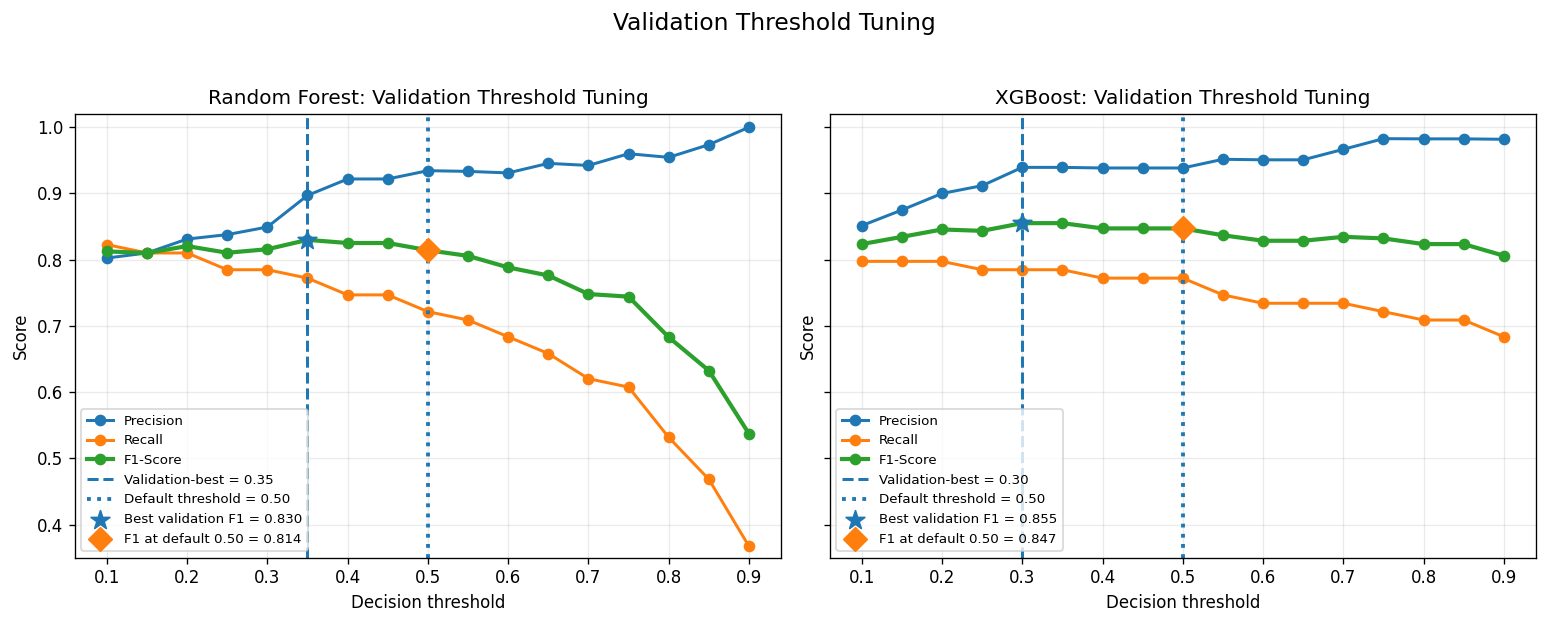

In [70]:
# =========================================================
# VALIDATION THRESHOLD TUNING PLOT
# This plot matches validation_threshold_comparison_df
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=120, sharey=True)

def plot_validation_threshold_tuning(
    ax,
    df,
    best_threshold,
    default_threshold,
    title
):
    # Main metric curves
    ax.plot(
        df["Threshold"],
        df["Precision"],
        marker="o",
        linewidth=1.8,
        label="Precision"
    )

    ax.plot(
        df["Threshold"],
        df["Recall"],
        marker="o",
        linewidth=1.8,
        label="Recall"
    )

    ax.plot(
        df["Threshold"],
        df["F1-Score"],
        marker="o",
        linewidth=2.5,
        label="F1-Score"
    )

    # Validation-best threshold
    ax.axvline(
        best_threshold,
        linestyle="--",
        linewidth=1.8,
        label=f"Validation-best = {best_threshold:.2f}"
    )

    # Default threshold
    ax.axvline(
        default_threshold,
        linestyle=":",
        linewidth=2.3,
        label=f"Default threshold = {default_threshold:.2f}"
    )

    # Highlight validation-best F1 point
    best_row = df[df["Threshold"] == best_threshold].iloc[0]

    ax.scatter(
        best_row["Threshold"],
        best_row["F1-Score"],
        s=140,
        marker="*",
        zorder=5,
        label=f"Best validation F1 = {best_row['F1-Score']:.3f}"
    )

    # Highlight F1 at default threshold
    default_row = df[df["Threshold"] == default_threshold].iloc[0]

    ax.scatter(
        default_row["Threshold"],
        default_row["F1-Score"],
        s=100,
        marker="D",
        zorder=5,
        label=f"F1 at default 0.50 = {default_row['F1-Score']:.3f}"
    )

    ax.set_title(title)
    ax.set_xlabel("Decision threshold")
    ax.set_ylabel("Score")
    ax.set_xticks(np.arange(0.10, 0.91, 0.10))
    ax.set_ylim(0.35, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="lower left")


plot_validation_threshold_tuning(
    axes[0],
    rf_validation_threshold_df,
    best_rf_threshold,
    final_rf_threshold,
    "Random Forest: Validation Threshold Tuning"
)

plot_validation_threshold_tuning(
    axes[1],
    xgb_validation_threshold_df,
    best_xgb_threshold,
    final_xgb_threshold,
    "XGBoost: Validation Threshold Tuning"
)

fig.suptitle("Validation Threshold Tuning", fontsize=14, y=1.03)

plt.tight_layout()

plt.savefig("validation_threshold_tuning.png", dpi=300, bbox_inches="tight")

plt.show()

## 7.8 Threshold Tuning for the Finalist Tree-Based Models

This section compares the default threshold of 0.50 against thresholds selected on validation data.

The goal is to check whether threshold adjustment improves the practical fraud-detection trade-off without harming generalisation on the test set.

# 8. Final Model Selection and Justification

The final model should detect fraudulent transactions effectively while avoiding an excessive number of false alarms.

In a financial-services context, false negatives are costly because fraud is missed. However, false positives are also important because legitimate customers may be incorrectly flagged.

The final decision therefore considers recall, precision, F1-score, ROC-AUC, Average Precision, confusion matrices and practical interpretability.

## Why other options were not selected as final models

- **Logistic Regression (Original):** useful as a baseline and relatively interpretable, but weaker than the best ensemble models in recall and F1-score.
- **Logistic Regression + Over-Sampling / SMOTE / Class Weights:** these versions became too aggressive. Although recall improved substantially, precision and F1-score dropped sharply, meaning too many legitimate transactions were incorrectly flagged as fraud.
- **Decision Tree (Original):** a solid and balanced model, but still outperformed overall by Random Forest and XGBoost.
- **Decision Tree + Over-Sampling / SMOTE / Class Weights:** none of these variants consistently improved the overall balance beyond the original tree. In particular, SMOTE increased recall but reduced precision and F1-score too strongly.
- **Neural Network:** promising, but the basic implementation did not outperform Random Forest or XGBoost overall.
- **SVM:** considered initially, but not retained because it was computationally too expensive for this large fraud dataset in Colab.
- **Random Under-Sampling:** not prioritised for the main modelling stage because it would discard a very large amount of majority-class information from legitimate transactions.

# 9. Final Evaluation and Visualisation

After the main model-comparison, cross-validation and tuning stages, the final models are inspected visually.

This final evaluation combines several complementary views:

- supervised feature-space visualisation using the true class labels,
- model-level probability separation for Random Forest and XGBoost,
- confusion matrices,
- metric comparison plots,
- feature importance,
- precision-recall curves,
- ROC curves,
- and an illustrative Random Forest tree.

This is useful because two models may achieve similar headline metrics while making different types of errors or assigning different probability scores to the same cases.


# 9.1 Final Selected Models and Visual Diagnostics

## Final models: Random Forest and XGBoost

In [71]:
# =========================================================
# FINAL MODELS: RANDOM FOREST + XGBOOST (ORIGINAL SCALED)
# Uses tuned versions if they already exist in memory
# =========================================================

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. Random Forest
if "best_rf_random" in globals():
    rf_final = best_rf_random
else:
    rf_final = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf_final.fit(X_train_scaled, y_train)

# 2. XGBoost
if "best_xgb_random" in globals():
    xgb_final = best_xgb_random
else:
    xgb_final = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )
    xgb_final.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf_final.predict(X_test_scaled)
y_prob_rf = rf_final.predict_proba(X_test_scaled)[:, 1]

y_pred_xgb = xgb_final.predict(X_test_scaled)
y_prob_xgb = xgb_final.predict_proba(X_test_scaled)[:, 1]

print("Final models ready.")

Final models ready.


## Feature-Space Structure and Final Model Performance

This section compares two complementary perspectives:

1. **Supervised feature-space visualisation:** the true class labels are used only for colouring the transactions in a reduced two-dimensional space.
2. **Model-level performance:** Random Forest and XGBoost are evaluated using their predictions and predicted fraud probabilities.

The first plot does **not** represent model predictions. It shows how fraudulent and legitimate transactions are distributed in the feature space after dimensionality reduction. The following plot then shows how the final trained models separate the classes through predicted fraud probabilities.


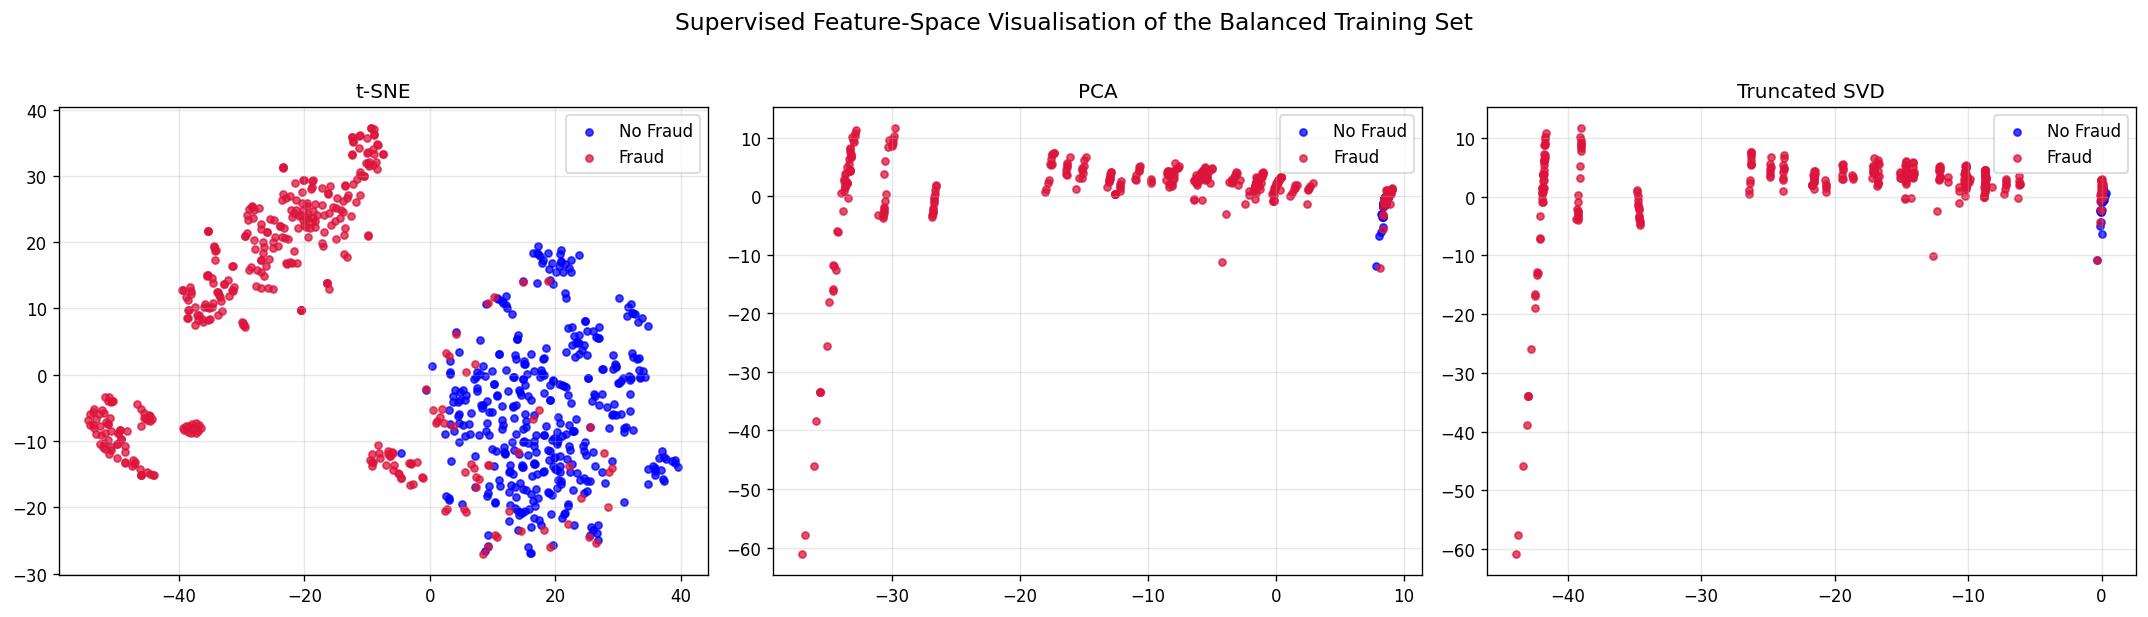

In [72]:
# =========================================================
# SUPERVISED FEATURE-SPACE VISUALISATION
# True labels are used only for colouring the points.
# This is not a model-prediction plot.
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

# Use a balanced sample derived from the original training data.
# This is only for visualisation, so that the minority fraud class is visible.
X_vis = X_train_under
y_vis = y_train_under

X_vis_array = np.asarray(X_vis)
y_vis_array = np.asarray(y_vis)

# Dimensionality reduction methods
X_reduced_tsne = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    perplexity=30,
    learning_rate="auto",
    init="pca"
).fit_transform(X_vis_array)

X_reduced_pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
).fit_transform(X_vis_array)

X_reduced_svd = TruncatedSVD(
    n_components=2,
    random_state=RANDOM_STATE
).fit_transform(X_vis_array)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

plots = [
    (X_reduced_tsne, "t-SNE"),
    (X_reduced_pca, "PCA"),
    (X_reduced_svd, "Truncated SVD")
]

for ax, (X_reduced, title) in zip(axes, plots):
    ax.scatter(
        X_reduced[y_vis_array == 0, 0],
        X_reduced[y_vis_array == 0, 1],
        s=18,
        alpha=0.75,
        color="blue",
        label="No Fraud"
    )

    ax.scatter(
        X_reduced[y_vis_array == 1, 0],
        X_reduced[y_vis_array == 1, 1],
        s=18,
        alpha=0.75,
        color="crimson",
        label="Fraud"
    )

    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(loc="best")

plt.suptitle(
    "Supervised Feature-Space Visualisation of the Balanced Training Set",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()


The dimensionality-reduction plots show that fraudulent and legitimate transactions occupy partially different regions of the feature space, although some overlap remains. This is expected in fraud detection, where fraudulent behaviour can resemble legitimate transactions.

A balanced under-sampled training set was used only for visualisation purposes. This makes the minority fraud class visible and prevents the plot from being dominated by the much larger non-fraud class.

This visualisation is exploratory. It does not measure model performance and it does not show Random Forest or XGBoost predictions. Model-level performance is evaluated separately using predicted probabilities, confusion matrices, precision-recall curves and ROC curves.


Using variable: y_prob_rf
Using variable: y_prob_xgb


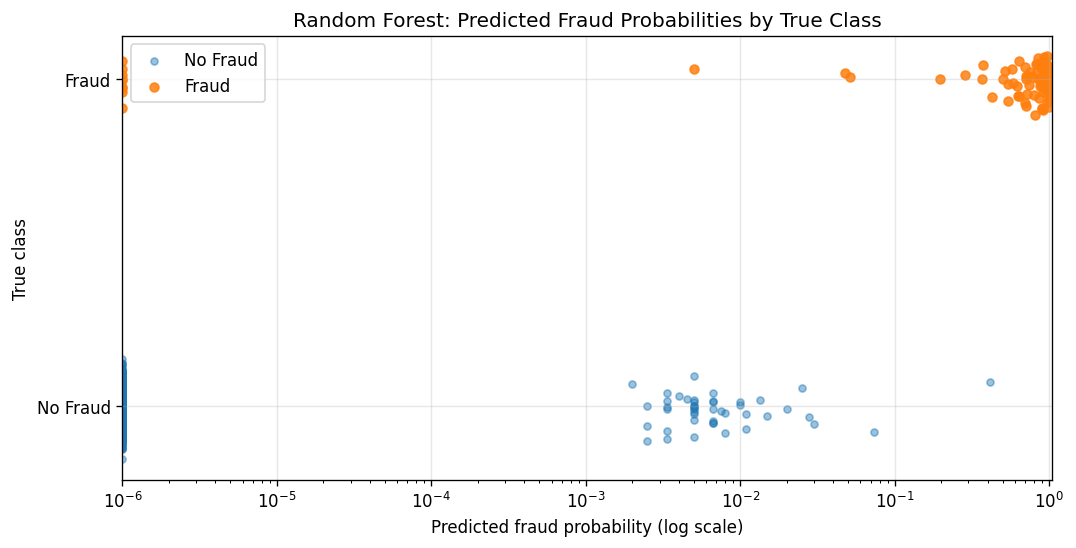

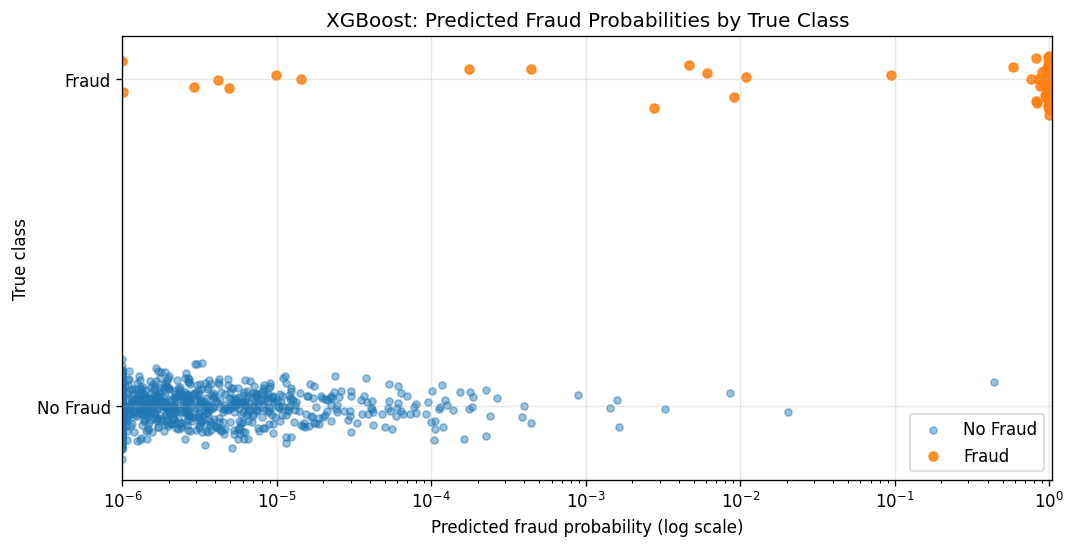

In [73]:
# =========================================================
# MODEL-LEVEL SEPARATION USING PREDICTED FRAUD PROBABILITIES
# Each point represents one transaction.
# All fraud cases are shown, together with a sample of legitimate transactions.
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

plot_random_state = RANDOM_STATE if "RANDOM_STATE" in globals() else 42


def get_existing_variable(possible_names):
    """
    Return the first existing variable from a list of possible names.
    This makes the plot robust to different variable names used earlier
    in the notebook.
    """
    for name in possible_names:
        if name in globals():
            print(f"Using variable: {name}")
            return globals()[name]
    return None


# ---------------------------------------------------------
# Retrieve or create predicted fraud probabilities
# ---------------------------------------------------------

rf_probabilities = get_existing_variable([
    "y_prob_rf",
    "y_test_prob_rf",
    "rf_final_proba"
])

xgb_probabilities = get_existing_variable([
    "y_prob_xgb",
    "y_test_prob_xgb",
    "xgb_final_proba"
])

# If probability variables do not exist yet, try to create them from final models.
if rf_probabilities is None:
    rf_model_for_plot = get_existing_variable([
        "rf_final",
        "rf_final_model",
        "best_rf_random",
        "best_rf_model",
        "rf_model"
    ])

    if rf_model_for_plot is None:
        raise NameError(
            "No Random Forest probability variable or fitted Random Forest final model was found. "
            "Please run the final Random Forest/XGBoost model evaluation cell before this plot."
        )

    rf_probabilities = rf_model_for_plot.predict_proba(X_test_scaled)[:, 1]


if xgb_probabilities is None:
    xgb_model_for_plot = get_existing_variable([
        "xgb_final",
        "xgb_final_model",
        "best_xgb_random",
        "best_xgb_model",
        "xgb_model"
    ])

    if xgb_model_for_plot is None:
        raise NameError(
            "No XGBoost probability variable or fitted XGBoost final model was found. "
            "Please run the final Random Forest/XGBoost model evaluation cell before this plot."
        )

    xgb_probabilities = xgb_model_for_plot.predict_proba(X_test_scaled)[:, 1]


# ---------------------------------------------------------
# Plotting function
# ---------------------------------------------------------

def plot_probability_strip(y_true, y_proba, model_name, max_no_fraud_points=1200):
    """
    Plot predicted fraud probabilities for individual transactions.

    All fraud cases are shown, together with a random sample of legitimate
    transactions. This avoids the majority class dominating the plot.
    """

    y_true_array = np.asarray(y_true)
    y_proba_array = np.asarray(y_proba)

    rng = np.random.default_rng(plot_random_state)

    fraud_idx = np.where(y_true_array == 1)[0]
    no_fraud_idx = np.where(y_true_array == 0)[0]

    sampled_no_fraud_idx = rng.choice(
        no_fraud_idx,
        size=min(max_no_fraud_points, len(no_fraud_idx)),
        replace=False
    )

    selected_idx = np.concatenate([sampled_no_fraud_idx, fraud_idx])

    selected_y = y_true_array[selected_idx]
    selected_proba = y_proba_array[selected_idx]

    # Clip probabilities so that exact zeros can be displayed on a log scale.
    selected_proba = np.clip(selected_proba, 1e-6, 1)

    y_positions = np.where(selected_y == 1, 1, 0)
    jitter = rng.normal(0, 0.045, size=len(selected_idx))

    plt.figure(figsize=(10, 4.8), dpi=120)

    plt.scatter(
        selected_proba[selected_y == 0],
        y_positions[selected_y == 0] + jitter[selected_y == 0],
        alpha=0.45,
        s=18,
        label="No Fraud"
    )

    plt.scatter(
        selected_proba[selected_y == 1],
        y_positions[selected_y == 1] + jitter[selected_y == 1],
        alpha=0.85,
        s=28,
        label="Fraud"
    )

    plt.xscale("log")
    plt.yticks([0, 1], ["No Fraud", "Fraud"])
    plt.xlabel("Predicted fraud probability (log scale)")
    plt.ylabel("True class")
    plt.title(f"{model_name}: Predicted Fraud Probabilities by True Class")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xlim(1e-6, 1.05)
    plt.show()


plot_probability_strip(
    y_test,
    rf_probabilities,
    "Random Forest"
)

plot_probability_strip(
    y_test,
    xgb_probabilities,
    "XGBoost"
)

The probability strip plots show how the final models assign fraud probabilities to individual test transactions. All fraud cases are shown, together with a random sample of legitimate transactions, to prevent the majority class from dominating the visualisation.

Each point represents one transaction. The x-axis shows the predicted fraud probability on a logarithmic scale, while the y-axis shows the true class. Most legitimate transactions receive probabilities close to 0, while most fraudulent transactions receive substantially higher probabilities.

This visualisation supports the final model comparison by showing that both Random Forest and XGBoost achieve strong class separation, although some overlap remains, which is expected in a realistic fraud-detection problem.

## Confusion Matrices of the Finalist Models

The confusion matrices provide a direct view of how the two finalist models behave on the test set in terms of true negatives, false positives, false negatives and true positives.


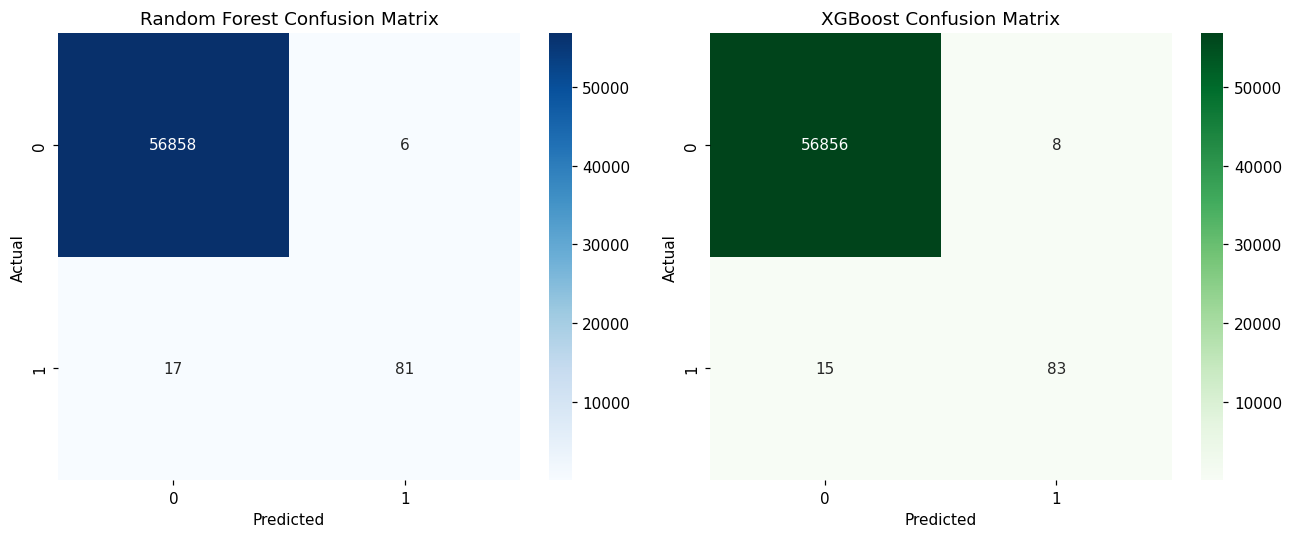

In [74]:
# =========================================================
# CONFUSION MATRICES: RANDOM FOREST vs XGBOOST
# =========================================================

from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=110)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Random Forest Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("XGBoost Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

The confusion matrices provide a direct view of how the two finalist models behave on the test set in terms of true negatives, false positives, false negatives and true positives.

Both Random Forest and XGBoost perform extremely well on the majority legitimate class in this run, producing only a very small number of false positives. This is important in a fraud-detection setting because excessive false positives can create unnecessary investigation costs and inconvenience legitimate customers.

At the same time, both models detect a high proportion of fraudulent transactions. Random Forest correctly identifies 81 fraud cases and misses 17, while XGBoost correctly identifies 83 fraud cases and misses 15. This means that XGBoost achieves slightly stronger fraud capture, whereas Random Forest produces slightly fewer false positives.

Taken together, these confusion matrices reinforce the overall comparison between the two finalists: both models are highly effective, but XGBoost shows a small advantage in recall, while Random Forest remains slightly stronger in precision. This reflects the practical trade-off already observed in the metric table and the precision-recall curves.


In [75]:
# =========================================================
# FINAL METRICS TABLE
# =========================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

final_results_df = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

final_results_df = final_results_df.round(4)
display(final_results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9996,0.9310,0.8265,0.8757,0.9517
1,XGBoost,0.9996,0.9121,0.8469,0.8783,0.9768


## Final comparison of the shortlisted models

The final comparison confirms that both Random Forest and XGBoost are very strong classifiers for this fraud-detection problem. Both models achieved the same overall accuracy (0.9996), which is expected in such a highly imbalanced dataset, but the more informative metrics show some meaningful differences.

Random Forest achieved slightly higher precision (0.9310), which means it was somewhat better at limiting false positives when predicting fraud. XGBoost, on the other hand, achieved slightly higher recall (0.8469), F1-score (0.8783), and ROC-AUC (0.9768), indicating a stronger overall balance between fraud detection and classification quality.

Taken together, these results suggest that both models are highly competitive, but XGBoost holds a small overall advantage in this final comparison, while Random Forest remains particularly attractive when stronger precision is preferred.

## Final Model Comparison Chart

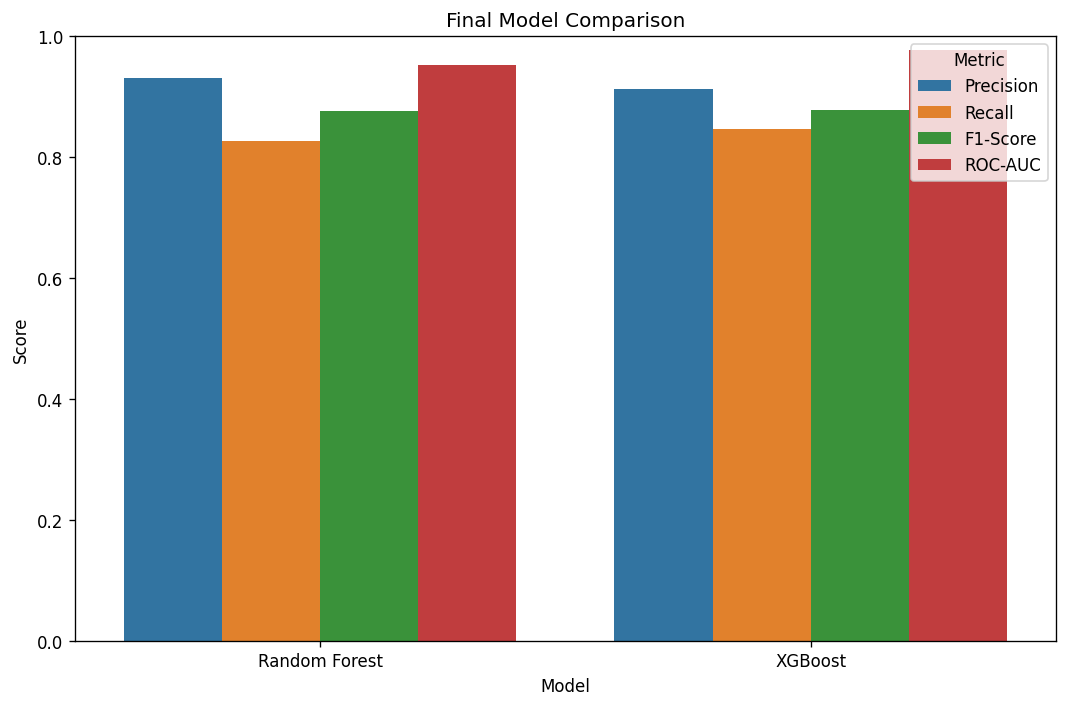

In [76]:
# =========================================================
# FINAL MODEL COMPARISON BAR CHART
# =========================================================

plot_df = final_results_df.melt(
    id_vars="Model",
    value_vars=["Precision", "Recall", "F1-Score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9, 6), dpi=120)
sns.barplot(x="Model", y="Score", hue="Metric", data=plot_df)
plt.title("Final Model Comparison")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## Feature Importance

Feature importance is used to inspect which variables contribute most strongly to the predictions of the final tree-based models.

For Random Forest and XGBoost, this helps provide an additional layer of interpretability. Feature importance should not be treated as a causal explanation, but it is useful for understanding which transformed variables the models rely on most when separating fraudulent from legitimate transactions.

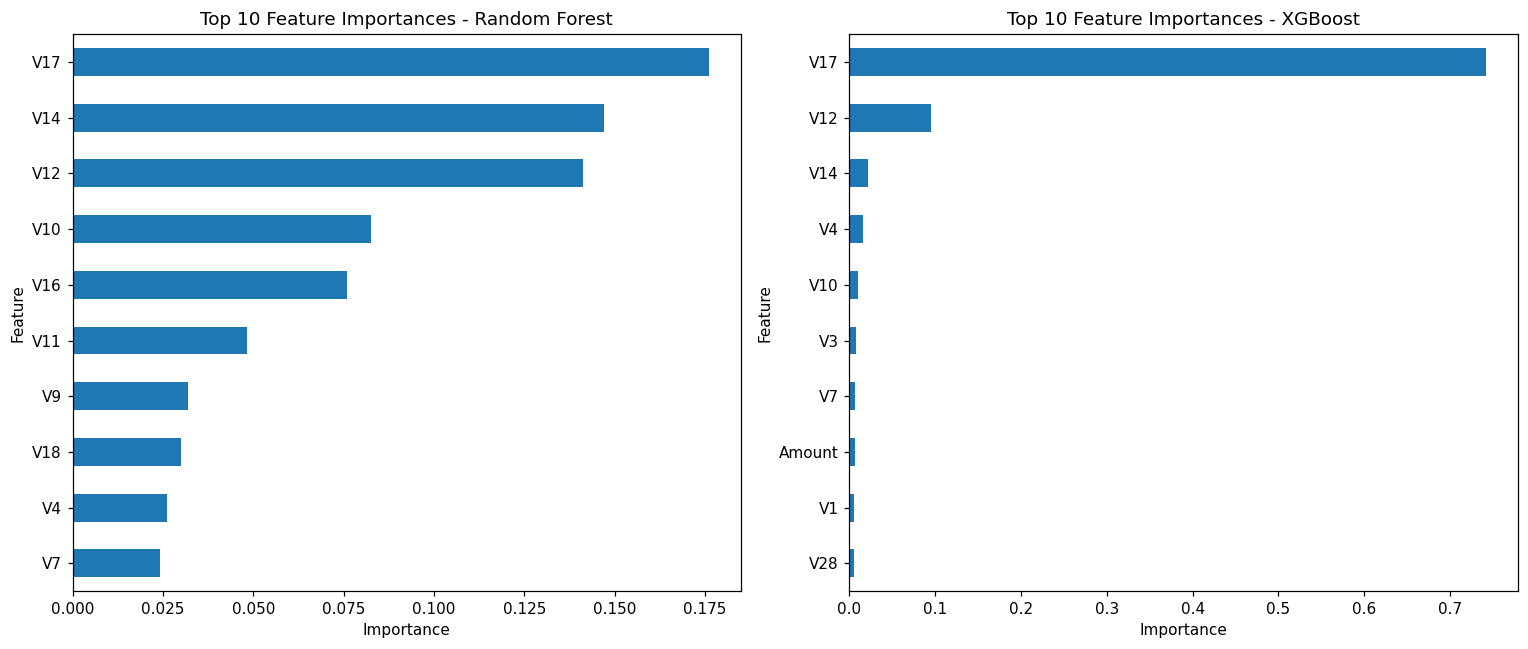

In [77]:
# =========================================================
# FEATURE IMPORTANCE: RANDOM FOREST vs XGBOOST
# =========================================================

# Random Forest importances
rf_importance = pd.Series(rf_final.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

# XGBoost importances
xgb_importance = pd.Series(xgb_final.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=110)

rf_importance.sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 10 Feature Importances - Random Forest")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("Feature")

xgb_importance.sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Top 10 Feature Importances - XGBoost")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()

## Top 10 Feature Importances: Random Forest vs XGBoost

The feature-importance plots help show which variables contributed most to the predictions of the two finalist tree-based models.

A clear point of agreement between the models is that `V17` appears as the most important feature in both cases. This is consistent with the earlier correlation analysis, where `V17` was already identified as one of the variables most strongly associated with the target class. This strengthens confidence that both models are capturing meaningful signal rather than relying on random noise.

At the same time, the two models use the feature space somewhat differently. Random Forest distributes importance more broadly across several variables, including `V14`, `V12`, `V10`, `V16`, and `V11`, which suggests that it combines information from multiple predictors in a more balanced way. By contrast, XGBoost concentrates much more heavily on `V17`, with smaller secondary contributions from variables such as `V12`, `V14`, `V4`, and `V10`. This suggests that XGBoost relies more strongly on a smaller number of highly informative features.

This difference does not necessarily mean that one model is wrong and the other is right. Instead, it shows that the two models detect useful structure in different ways. Random Forest appears to exploit a wider range of predictors, whereas XGBoost seems to focus more aggressively on the strongest discriminative variables.

Feature importance should also be interpreted with caution. In tree-based models, importance values show how much the model used a variable during prediction, but they do not prove a direct causal relationship with fraud. Even so, these plots are useful because they confirm that the finalist models are learning non-random and interpretable patterns from the dataset.

## Precision-Recall Curves

Precision-recall curves are especially useful in highly imbalanced classification problems.

In this project, the fraud class is the minority class, so ROC-AUC alone can sometimes make performance look stronger than it is in practical terms. Precision-recall analysis focuses more directly on the trade-off between detecting fraud and avoiding excessive false positives.

Average Precision is therefore used alongside precision, recall, F1-score and ROC-AUC to support the final model comparison.

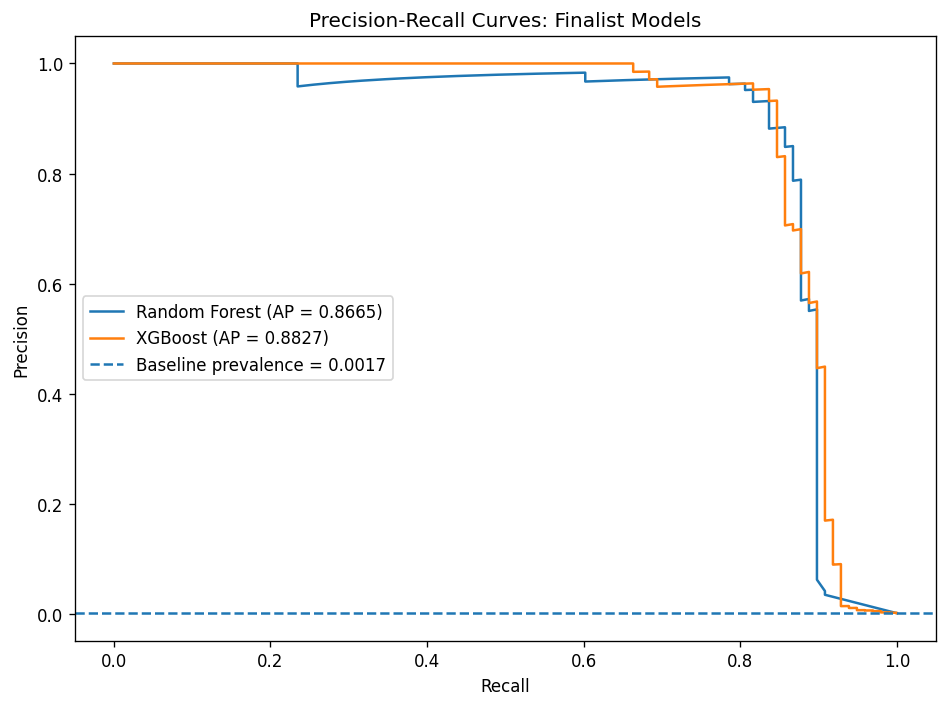

Average Precision - Random Forest: 0.866475
Average Precision - XGBoost:      0.882720


In [78]:
# =========================================================
# PRECISION-RECALL CURVES
# =========================================================

from sklearn.metrics import precision_recall_curve, average_precision_score

# Random Forest
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_prob_rf)
ap_rf = average_precision_score(y_test, y_prob_rf)

# XGBoost
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, y_prob_xgb)
ap_xgb = average_precision_score(y_test, y_prob_xgb)

# Baseline prevalence of positive class
fraud_prevalence = y_test.mean()

plt.figure(figsize=(8, 6), dpi=120)

plt.plot(recall_rf, precision_rf, label=f"Random Forest (AP = {ap_rf:.4f})")
plt.plot(recall_xgb, precision_xgb, label=f"XGBoost (AP = {ap_xgb:.4f})")

# Baseline
plt.axhline(y=fraud_prevalence, linestyle="--", label=f"Baseline prevalence = {fraud_prevalence:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves: Finalist Models")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

print(f"Average Precision - Random Forest: {ap_rf:.6f}")
print(f"Average Precision - XGBoost:      {ap_xgb:.6f}")

## Precision-Recall Curves for the Finalist Models

The precision-recall curves provide a particularly informative comparison for this fraud-detection problem because the dataset is highly imbalanced and the positive fraud class is extremely rare.

Both finalist models perform far above the baseline fraud prevalence, which indicates that they are learning useful structure rather than behaving like near-random classifiers. The curves show that both Random Forest and XGBoost maintain very high precision across a large part of the recall range, which is a strong result in such an imbalanced setting.

In this run, XGBoost achieved the highest Average Precision, while Random Forest remained very close. This suggests that XGBoost offers a slight overall advantage in minority-class precision-recall performance, although Random Forest is still highly competitive.

As expected, precision drops sharply when recall approaches its maximum, reflecting the practical trade-off of fraud detection: capturing almost all fraud cases usually comes at the cost of increasing false positives.

## ROC Curves for the Finalist Models

The ROC curves provide an additional comparison of the two finalist models by showing the trade-off between the true positive rate and the false positive rate across different classification thresholds.

In this project, ROC-AUC is useful as a general measure of class separability, while the precision-recall curve remains especially important because the dataset is highly imbalanced and the fraud class is rare.


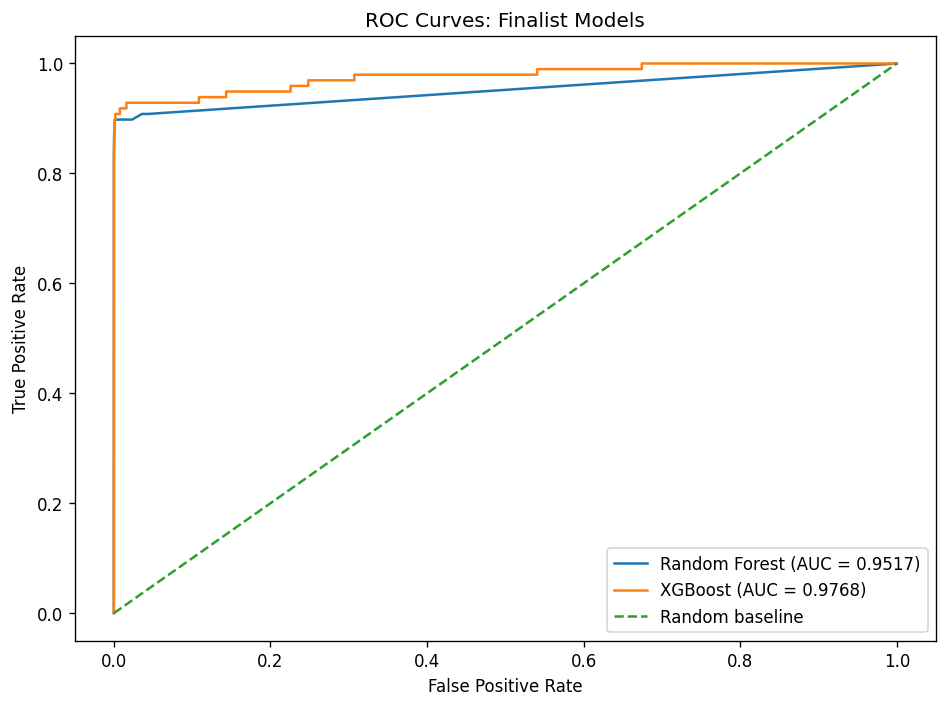

ROC-AUC - Random Forest: 0.951746
ROC-AUC - XGBoost:      0.976753


In [79]:
# =========================================================
# ROC CURVES: RANDOM FOREST vs XGBOOST
# =========================================================

from sklearn.metrics import roc_curve, roc_auc_score

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6), dpi=120)

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.4f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_xgb:.4f})")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Finalist Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC - Random Forest: {roc_auc_rf:.6f}")
print(f"ROC-AUC - XGBoost:      {roc_auc_xgb:.6f}")

### ROC curve interpretation

Both Random Forest and XGBoost achieve ROC curves that are far above the random baseline, confirming that both models are effective at separating fraudulent from legitimate transactions across thresholds.

In this run, XGBoost achieved the highest ROC-AUC, while Random Forest also performed very strongly. This suggests that XGBoost offers a stronger overall ability to distinguish between the two classes, although Random Forest remains highly competitive.


## One illustrative tree from the Random Forest

Although Random Forest is an ensemble model composed of many decision trees, it can still be helpful to visualise one representative tree in order to better understand the kind of decision rules the model is learning.

The figure above does not represent the full Random Forest model, but only one illustrative tree extracted from the ensemble and displayed with limited depth for readability. Even so, it is useful because it shows that the model relies on a sequence of splits involving variables such as `V17`, `V11`, `V14`, `V12`, and `V16`, which is broadly consistent with the feature-importance results and with the earlier correlation analysis.

This visualisation therefore has mainly an explanatory purpose. It helps make the model structure more interpretable, but it should not be confused with the full Random Forest, whose final predictions are based on the combined output of many trees rather than on one tree alone.

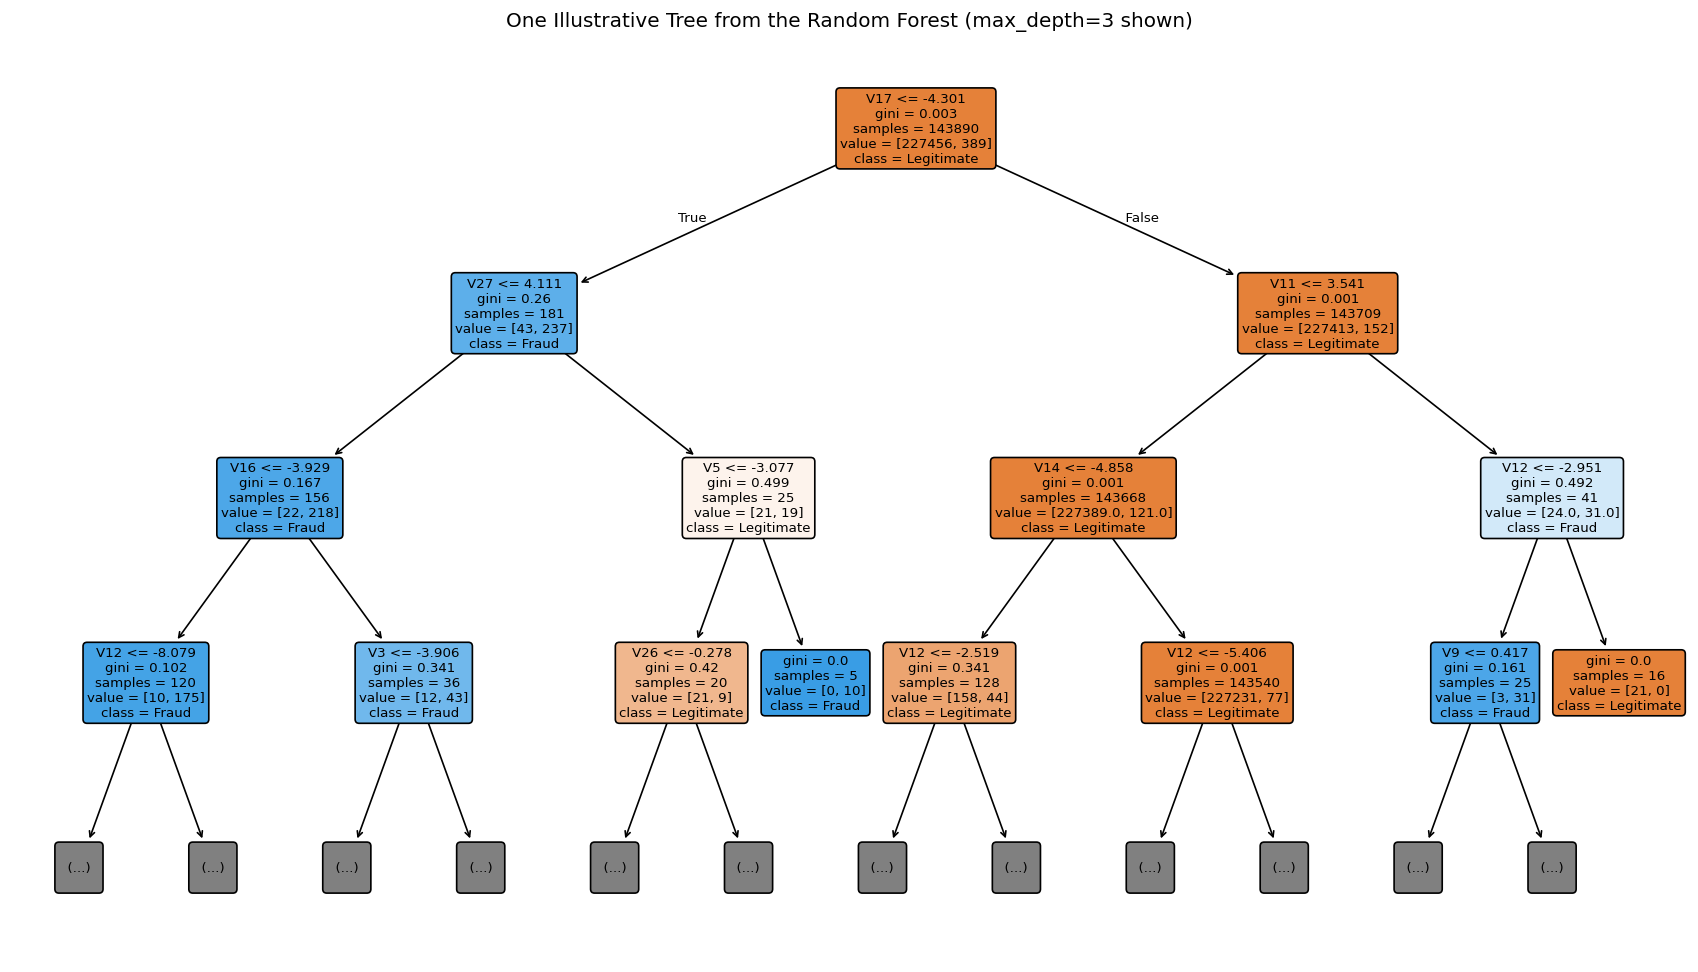

In [80]:
# =========================================================
# OPTIONAL: ONE ILLUSTRATIVE TREE FROM THE RANDOM FOREST
# =========================================================

from sklearn.tree import plot_tree

# Take one tree from the forest
rf_tree_example = rf_final.estimators_[0]

plt.figure(figsize=(18, 10), dpi=120)
plot_tree(
    rf_tree_example,
    feature_names=X.columns,
    class_names=["Legitimate", "Fraud"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("One Illustrative Tree from the Random Forest (max_depth=3 shown)")
plt.show()

# 10. GitHub Portfolio Summary

This notebook demonstrates a complete end-to-end machine-learning workflow for a highly imbalanced fraud-detection problem.

The final model selection favours **XGBoost** because it provides a strong balance across recall, F1-score, ROC-AUC and Average Precision, while Random Forest remains a competitive alternative when precision is prioritised.

From a portfolio perspective, this project demonstrates:

- practical supervised machine learning,
- responsible handling of imbalanced data,
- evaluation beyond accuracy,
- model comparison and shortlisting,
- cross-validation,
- hyperparameter tuning,
- threshold analysis,
- and professional technical documentation.